## SYNTHETIC DATA FOR MACHINE LEARNING: QUALITY AND EVALUATION

Dataset: Default of Credit Card Clients (UCI ML Repository / Kaggle)
Source:  Yeh, I-C., & Lien, C.-H. (2009). The comparisons of data mining
         techniques for the predictive accuracy of probability of default of
         credit card clients. Expert Systems with Applications, 36(2),
         2473-2480. https://doi.org/10.1016/j.eswa.2008.01.066
         UCI ID: 350 | https://archive.ics.uci.edu/dataset/350/default+of+credit+card+clients

### How this notebook is organised

Section numbers below are this notebook's own structure; the last column gives
where each part is reported in the dissertation.

| Notebook section | Content | Dissertation |
|---|---|---|
| 3.0–3.13 | Loading, integrity checks, EDA, cleaning, canonical 70/30 split and scaler | Ch. 4 (4.1–4.2), Appendix A |
| 3.G | Reference metrics on the real data (TVD, KS, correlations, domain rules, fidelity function) | Ch. 4 (4.4) |
| 4 | Baseline classifiers on the imbalanced data (LR, RF) | Ch. 5 (utility) |
| 5 | SMOTE, CTGAN and CTAB-GAN+ generation, domain correction, TSTR comparison | Ch. 4 (4.3), Ch. 5 (utility) |
| 6 | Per-variable fidelity, seven-property audit (He et al., 2025), sensitivity analysis | Ch. 5 (fidelity, audit), Appendix A |
| 7 | Memorisation risk (DCR, NNDR) for CTGAN and CTAB-GAN+ | Ch. 5 (memorisation), Appendix A |

The CSV files written in Section 6 (`real_minority_train.csv`,
`synthetic_ctgan_final.csv`, `synthetic_ctab_final.csv`, `real_train_full.csv`)
are the inputs of the five external-framework notebooks (Ch. 6).


### Chapter 3: Exploratory Data Analysis (EDA) and Data Preprocessing
This notebook encompasses the initial data loading, semantic cleaning, and exploratory data analysis of the `Default of Credit Card Clients` dataset. The objective is to evaluate the feature space, assess class imbalance, and identify multi-collinearity to establish a rigorous baseline for subsequent generative modeling (GANs) and predictive classification. Prepare the single canonical train/test split and StandardScaler that will be reused in all subsequent chapters. 

CRITICAL METHODOLOGICAL NOTE — Single Scaler, Single Split: The train/test split and the StandardScaler are defined ONCE here and reused across all chapters. This is the standard practice to prevent data leakage and ensure that evaluation is always performed on an untouched, realistically imbalanced test set. Reference: Kaufman et al. (2012) demonstrate that fitting preprocessing objects on the full dataset before splitting constitutes a form of data leakage that inflates performance estimates.

In [ ]:
# Folders used by this notebook, relative to it: CSV inputs/outputs in data/,
# figures in figures/, trained CTAB-GAN+ models in models/.
from pathlib import Path
for folder in ("data", "figures", "models"):
    Path(folder).mkdir(exist_ok=True)

In [1]:
# ------------------------------------------------------------------------------
# 3.0 — Imports
# ------------------------------------------------------------------------------
 
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings
import time
import sys
import os
from scipy import stats
from scipy.spatial.distance import mahalanobis
 
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    ConfusionMatrixDisplay,
    roc_curve,
    precision_recall_curve,
    average_precision_score,
)
from sklearn.decomposition import PCA
from imblearn.over_sampling import SMOTE
 
warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 8)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

# Color palette
PAL = ["#FFD1DC", "#FF4D4D"]
PAL_3 = ["#888888", "#FF4D4D", "#4D79FF"]  # Real, CTGAN, CTAB-GAN+
 
# Global random seed for all non-GAN operations
RANDOM_STATE = 123
np.random.seed(RANDOM_STATE)
 
print("Libraries imported successfully.")


Libraries imported successfully.


In [2]:
# ------------------------------------------------------------------------------
# 3.1 — Data Loading, Initial Inspection and Formatting
# ------------------------------------------------------------------------------
# The UCI 'Default of Credit Card Clients' dataset (Yeh & Lien, 2009) is one
# of the most widely used benchmarks for credit risk classification research.
# It contains 30,000 client records from a Taiwanese bank, with 23 features
# covering demographics, credit limit, payment history, and billing amounts.
#
# Preprocessing decisions consistent with the literature:
#   - ID column is dropped: has no predictive power and its retention
#     introduces memorisation risk during GAN training (Xu et al., 2019).
#   - PAY_0 renamed to PAY_1 for temporal naming consistency.
#   - default.payment.next.month renamed to def_pay 
# ------------------------------------------------------------------------------

file_path = "data/UCI_Credit_Card.csv"  
df = pd.read_csv(file_path)
 
print(f"Raw dataset shape: {df.shape}")
print(df.head())
 
# Drop ID column
if "ID" in df.columns:
    df = df.drop("ID", axis=1)
 
# Rename for semantic clarity
df = df.rename(columns={"default.payment.next.month": "def_pay", "PAY_0": "PAY_1"})
 
print(f"\nDataset shape after dropping ID: {df.shape}")
df.describe()


Raw dataset shape: (30000, 25)
   ID  LIMIT_BAL  SEX  EDUCATION  MARRIAGE  AGE  PAY_0  PAY_2  PAY_3  PAY_4  \
0   1    20000.0    2          2         1   24      2      2     -1     -1   
1   2   120000.0    2          2         2   26     -1      2      0      0   
2   3    90000.0    2          2         2   34      0      0      0      0   
3   4    50000.0    2          2         1   37      0      0      0      0   
4   5    50000.0    1          2         1   57     -1      0     -1      0   

   ...  BILL_AMT4  BILL_AMT5  BILL_AMT6  PAY_AMT1  PAY_AMT2  PAY_AMT3  \
0  ...        0.0        0.0        0.0       0.0     689.0       0.0   
1  ...     3272.0     3455.0     3261.0       0.0    1000.0    1000.0   
2  ...    14331.0    14948.0    15549.0    1518.0    1500.0    1000.0   
3  ...    28314.0    28959.0    29547.0    2000.0    2019.0    1200.0   
4  ...    20940.0    19146.0    19131.0    2000.0   36681.0   10000.0   

   PAY_AMT4  PAY_AMT5  PAY_AMT6  default.payment.next.m

,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_1,PAY_2,PAY_3,PAY_4,PAY_5,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,def_pay
count,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,...,30000.000000,30000.000000,30000.000000,30000.000000,3.000000e+04,30000.00000,30000.000000,30000.000000,30000.000000,30000.000000
mean,167484.322667,1.603733,1.853133,1.551867,35.485500,-0.016700,-0.133767,-0.166200,-0.220667,-0.266200,...,43262.948967,40311.400967,38871.760400,5663.580500,5.921163e+03,5225.68150,4826.076867,4799.387633,5215.502567,0.221200
std,129747.661567,0.489129,0.790349,0.521970,9.217904,1.123802,1.197186,1.196868,1.169139,1.133187,...,64332.856134,60797.155770,59554.107537,16563.280354,2.304087e+04,17606.96147,15666.159744,15278.305679,17777.465775,0.415062
min,10000.000000,1.000000,0.000000,0.000000,21.000000,-2.000000,-2.000000,-2.000000,-2.000000,-2.000000,...,-170000.000000,-81334.000000,-339603.000000,0.000000,0.000000e+00,0.00000,0.000000,0.000000,0.000000,0.000000
25%,50000.000000,1.000000,1.000000,1.000000,28.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,...,2326.750000,1763.000000,1256.000000,1000.000000,8.330000e+02,390.00000,296.000000,252.500000,117.750000,0.000000
50%,140000.000000,2.000000,2.000000,2.000000,34.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,19052.000000,18104.500000,17071.000000,2100.000000,2.009000e+03,1800.00000,1500.000000,1500.000000,1500.000000,0.000000
75%,240000.000000,2.000000,2.000000,2.000000,41.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,54506.000000,50190.500000,49198.250000,5006.000000,5.000000e+03,4505.00000,4013.250000,4031.500000,4000.000000,0.000000
max,1000000.000000,2.000000,6.000000,3.000000,79.000000,8.000000,8.000000,8.000000,8.000000,8.000000,...,891586.000000,927171.000000,961664.000000,873552.000000,1.684259e+06,896040.00000,621000.000000,426529.000000,528666.000000,1.000000


In [3]:
# ------------------------------------------------------------------------------
# 3.2 — Data Integrity Checks
# ------------------------------------------------------------------------------
 
print("=" * 50)
print(f"Missing values total: {df.isna().sum().sum()}")
print(f"Duplicate rows:       {df.duplicated().sum()}")
print("=" * 50)

print("\nData Type:")
df.info()

Missing values total: 0
Duplicate rows:       35

Data Type:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 24 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   LIMIT_BAL  30000 non-null  float64
 1   SEX        30000 non-null  int64  
 2   EDUCATION  30000 non-null  int64  
 3   MARRIAGE   30000 non-null  int64  
 4   AGE        30000 non-null  int64  
 5   PAY_1      30000 non-null  int64  
 6   PAY_2      30000 non-null  int64  
 7   PAY_3      30000 non-null  int64  
 8   PAY_4      30000 non-null  int64  
 9   PAY_5      30000 non-null  int64  
 10  PAY_6      30000 non-null  int64  
 11  BILL_AMT1  30000 non-null  float64
 12  BILL_AMT2  30000 non-null  float64
 13  BILL_AMT3  30000 non-null  float64
 14  BILL_AMT4  30000 non-null  float64
 15  BILL_AMT5  30000 non-null  float64
 16  BILL_AMT6  30000 non-null  float64
 17  PAY_AMT1   30000 non-null  float64
 18  PAY_AMT2   30000 non-null

In [4]:
# ------------------------------------------------------------------------------
# 3.3 — Categorical Variable Analysis
# ------------------------------------------------------------------------------
# EDUCATION and MARRIAGE contain undocumented categories (0, 5, 6 and 0
# respectively). This is a known characteristic of this dataset, documented
# by multiple studies (e.g., Kvamme et al., 2018; Alfaiz & Fati, 2022).
#
# Methodological decision: undocumented categories are merged into the 'Others'
# class (EDUCATION=4, MARRIAGE=3). This prevents the generative models from
# synthesising non-existent categorical states — a form of 'logical
# hallucination' as described by Kapar et al. (2026).
# ------------------------------------------------------------------------------
 
print("SEX distribution:\n", df["SEX"].value_counts())
print("\nMARRIAGE distribution:\n", df["MARRIAGE"].value_counts())
print("\nEDUCATION distribution:\n", df["EDUCATION"].value_counts())
 


SEX distribution:
 SEX
2    18112
1    11888
Name: count, dtype: int64

MARRIAGE distribution:
 MARRIAGE
2    15964
1    13659
3      323
0       54
Name: count, dtype: int64

EDUCATION distribution:
 EDUCATION
2    14030
1    10585
3     4917
5      280
4      123
6       51
0       14
Name: count, dtype: int64



Payment delay distribution:
    PAY_1  PAY_2  PAY_3  PAY_4    PAY_5    PAY_6
-2   2759   3782   4085   4348   4546.0   4895.0
-1   5686   6050   5938   5687   5539.0   5740.0
 0  14737  15730  15764  16455  16947.0  16286.0
 1   3688     28      4      2      NaN      NaN
 2   2667   3927   3819   3159   2626.0   2766.0
 3    322    326    240    180    178.0    184.0
 4     76     99     76     69     84.0     49.0
 5     26     25     21     35     17.0     13.0
 6     11     12     23      5      4.0     19.0
 7      9     20     27     58     58.0     46.0
 8     19      1      3      2      1.0      2.0


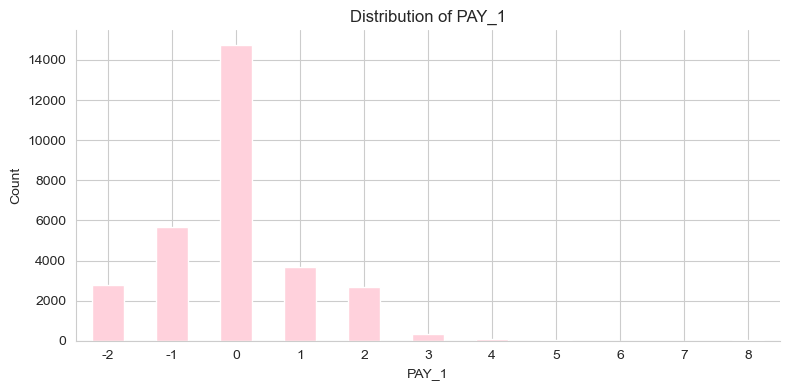

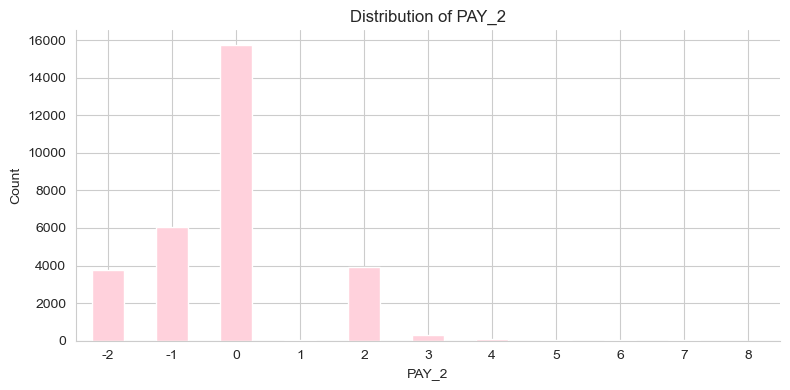

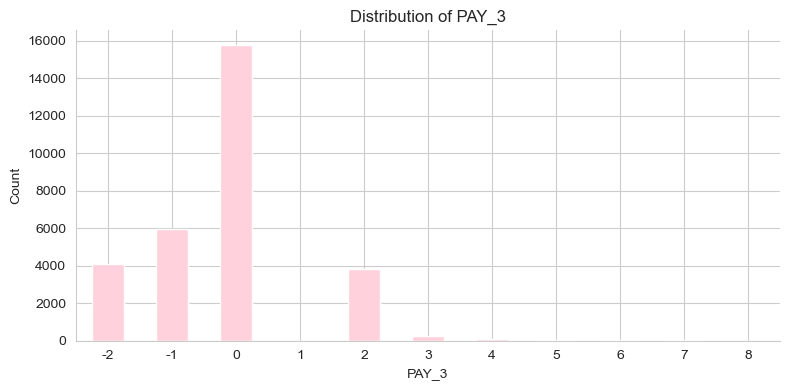

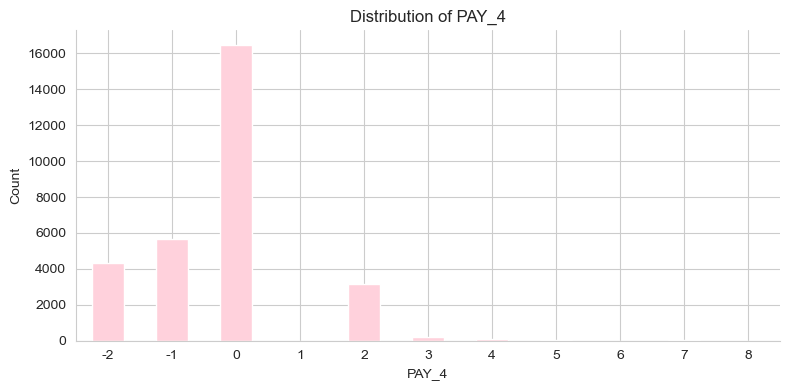

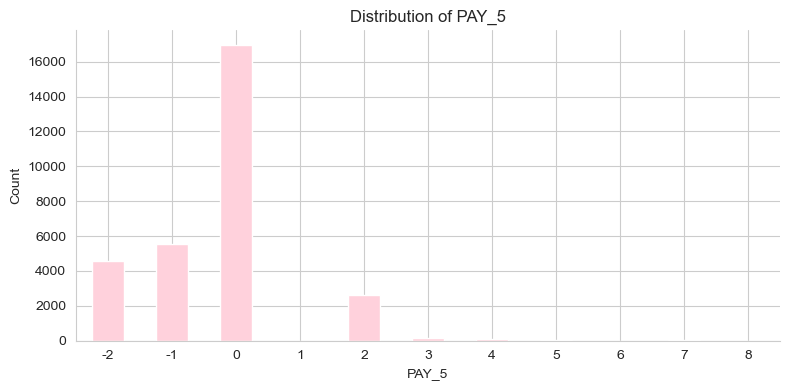

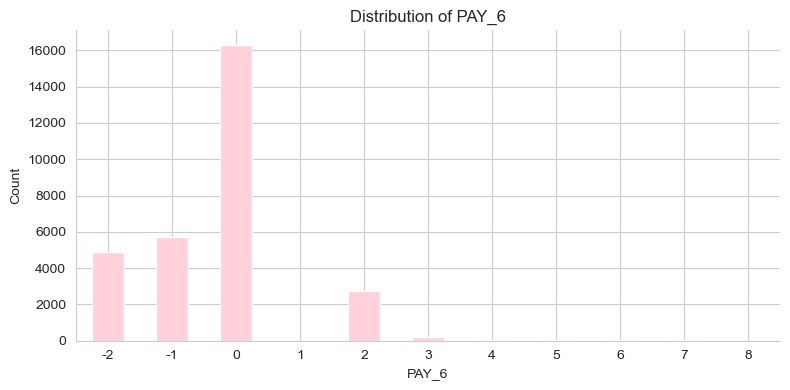

In [5]:
# Payment delay columns: values of -2 are undocumented.
# Decision: preserve ordinal granularity of PAY_X variables (do NOT binarise).
# This tests the GAN's capacity to model the long tail of extreme delays
# (Zhao et al., 2023; Xu et al., 2019).
pay_cols = ["PAY_1", "PAY_2", "PAY_3", "PAY_4", "PAY_5", "PAY_6"]
print("\nPayment delay distribution:")
print(df[pay_cols].apply(lambda x: x.value_counts().sort_index()))
 
# Visualise payment delay distributions
for col in pay_cols:
    plt.figure(figsize=(8, 4))
    df[col].value_counts().reindex(range(-2, 9)).plot(kind="bar", color="#FFD1DC")
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()

In [6]:
# ------------------------------------------------------------------------------
# 3.4 — Data Cleaning
# ------------------------------------------------------------------------------
 
# Merge undocumented EDUCATION categories (0, 5, 6) into 'Others' (4)
fil_edu = df["EDUCATION"].isin([0, 5, 6])
df.loc[fil_edu, "EDUCATION"] = 4
 
# Merge undocumented MARRIAGE category (0) into 'Others' (3)
df.loc[df["MARRIAGE"] == 0, "MARRIAGE"] = 3
 
print("Cleaned EDUCATION values:", sorted(df["EDUCATION"].unique()))
print("Cleaned MARRIAGE values:", sorted(df["MARRIAGE"].unique()))


print("\nCleaned EDUCATION Distribution:")
print(df["EDUCATION"].value_counts().sort_index())
print("\nCleaned MARRIAGE Distribution:")
print(df["MARRIAGE"].value_counts().sort_index())

Cleaned EDUCATION values: [1, 2, 3, 4]
Cleaned MARRIAGE values: [1, 2, 3]

Cleaned EDUCATION Distribution:
EDUCATION
1    10585
2    14030
3     4917
4      468
Name: count, dtype: int64

Cleaned MARRIAGE Distribution:
MARRIAGE
1    13659
2    15964
3      377
Name: count, dtype: int64



Class Count:
 def_pay
0    23364
1     6636
Name: count, dtype: int64

Class Percentage:
 def_pay
0    77.88
1    22.12
Name: proportion, dtype: float64


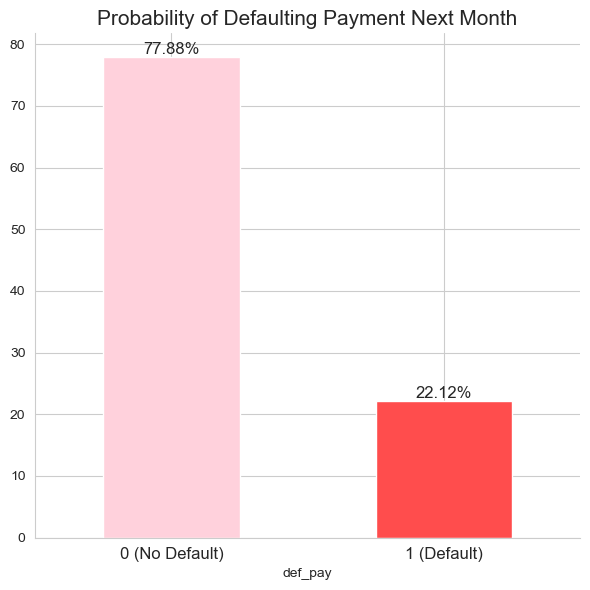

In [7]:
# ------------------------------------------------------------------------------
# 3.5 — Target Variable Analysis (Class Imbalance)
# ------------------------------------------------------------------------------
 
def_cnt = df["def_pay"].value_counts().sort_index()
print("\nClass Count:\n", def_cnt)
def_pct = df["def_pay"].value_counts(normalize=True).sort_index() * 100
print("\nClass Percentage:\n", def_pct)
 
ax = def_pct.plot.bar(figsize=(6, 6), color=["#FFD1DC", "#FF4D4D"])
plt.xticks([0, 1], ["0 (No Default)", "1 (Default)"], fontsize=12, rotation=0)
plt.title("Probability of Defaulting Payment Next Month", fontsize=15)
for i, v in enumerate(def_pct):
    plt.text(i, v + 0.5, f"{v:.2f}%", ha="center", fontsize=12)
plt.tight_layout()
plt.show()
 
# Note: ~22% minority class — consistent with reported values in the literature
# (Alfaiz & Fati, 2022; Arora et al., 2022).

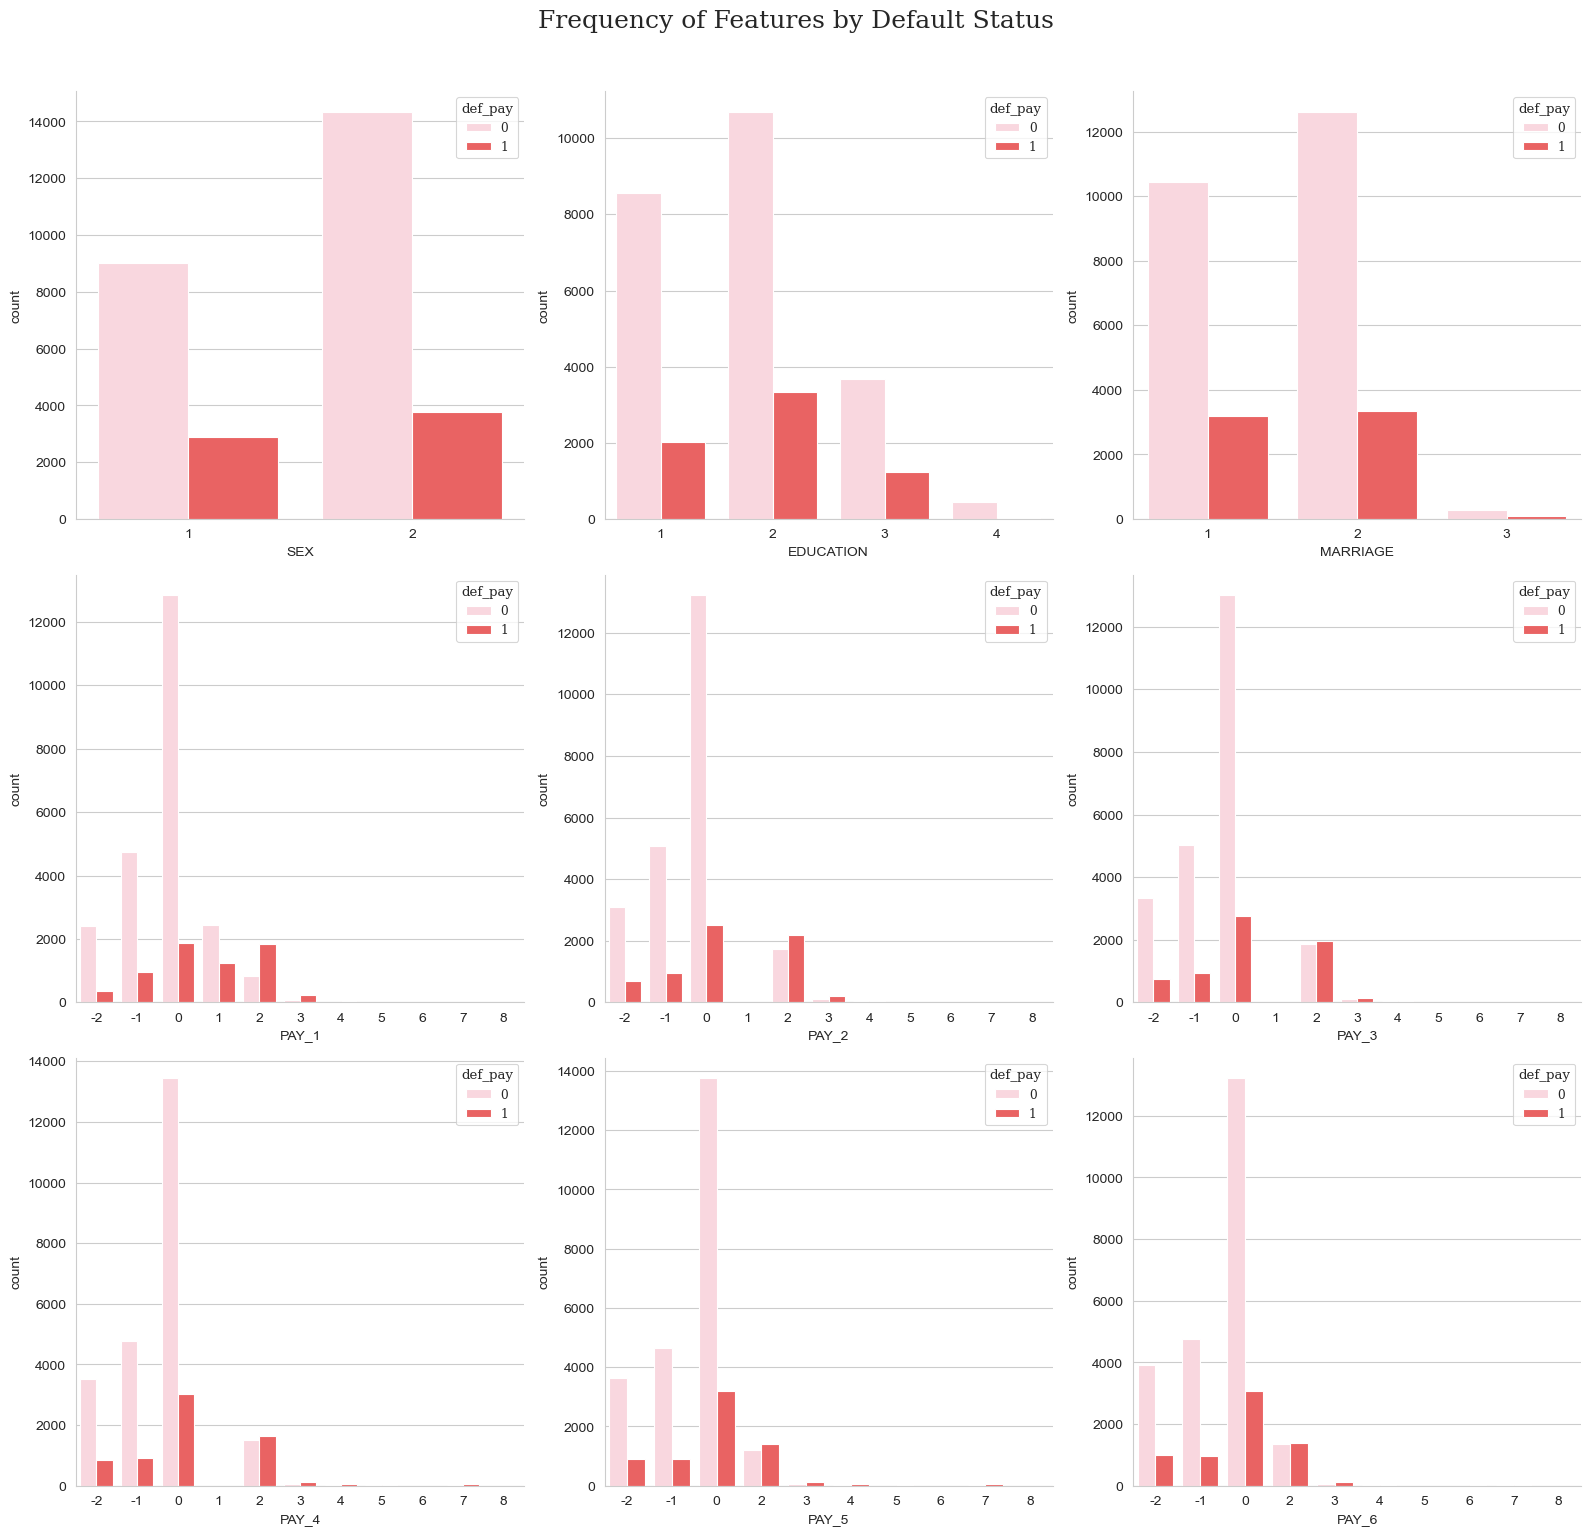

In [8]:
# ------------------------------------------------------------------------------
# 3.6 — Categorical Feature Frequency by Default Status
# ------------------------------------------------------------------------------
 
f, axes = plt.subplots(3, 3, figsize=(16, 15), facecolor="white")
sns.set_theme(style="whitegrid", font="serif", context="paper")
f.suptitle("Frequency of Features by Default Status", size=18, y=1.02)
palette_colors = ["#FFD1DC", "#FF4D4D"]
 
sns.countplot(x="SEX", hue="def_pay", data=df, ax=axes[0, 0], palette=palette_colors)
sns.countplot(x="EDUCATION", hue="def_pay", data=df, ax=axes[0, 1], palette=palette_colors)
sns.countplot(x="MARRIAGE", hue="def_pay", data=df, ax=axes[0, 2], palette=palette_colors)
for i, col in enumerate(pay_cols):
    r, c = divmod(i + 3, 3)
    sns.countplot(x=col, hue="def_pay", data=df, ax=axes[r, c], palette=palette_colors)
plt.tight_layout()
plt.show()


--- Default Rate by SEX ---
     n_default  n_total  default_rate_%
SEX                                    
1         2873    11888           24.17
2         3763    18112           20.78

--- Default Rate by EDUCATION ---
           n_default  n_total  default_rate_%
EDUCATION                                    
1               2036    10585           19.23
2               3330    14030           23.73
3               1237     4917           25.16
4                 33      468            7.05

--- Default Rate by MARRIAGE ---
          n_default  n_total  default_rate_%
MARRIAGE                                    
1              3206    13659           23.47
2              3341    15964           20.93
3                89      377           23.61


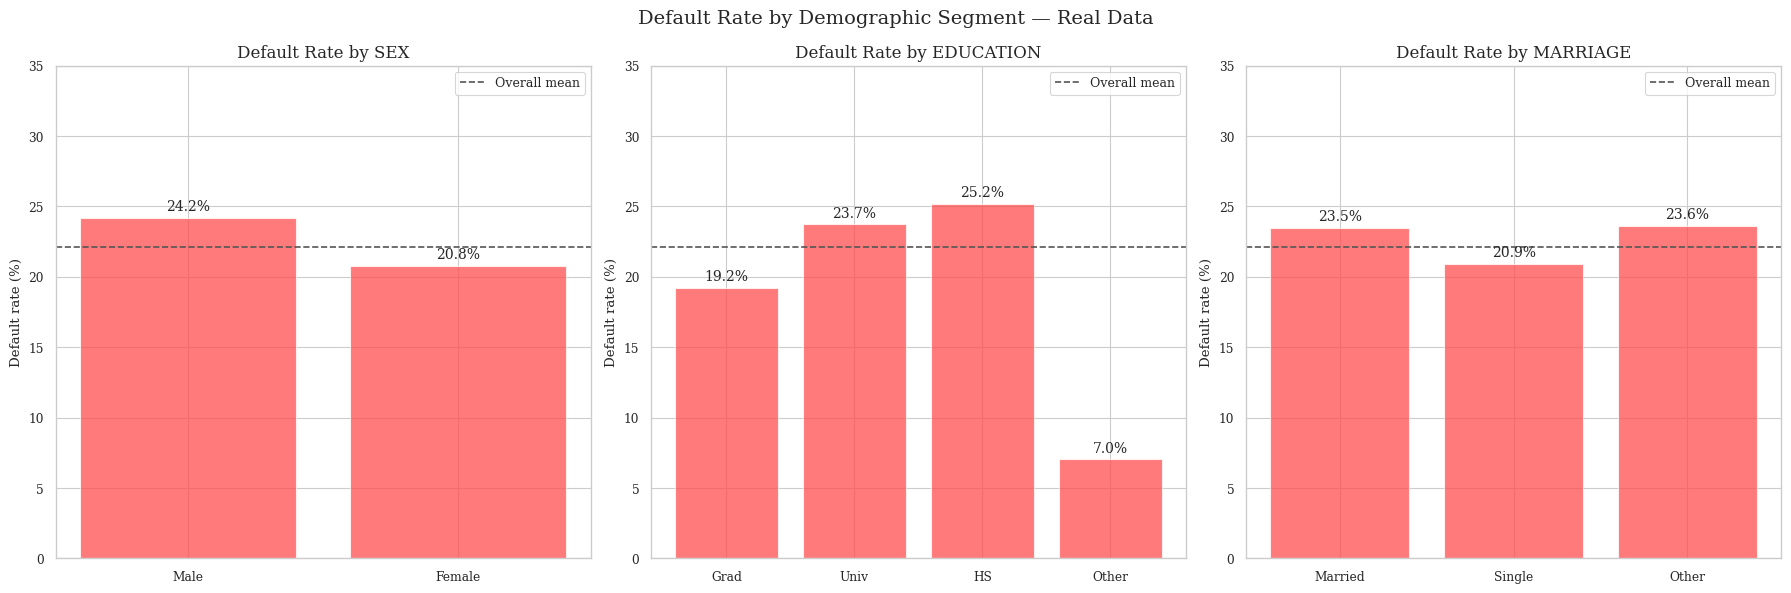

In [9]:
# ------------------------------------------------------------------------------
# 3.7 — Default Rate Analysis by Feature (Beyond Absolute Frequencies)
# ------------------------------------------------------------------------------
# This analysis goes beyond absolute frequencies by computing the default rate
# within each category. This is the relevant metric for comparison with the
# synthetic data in Chapter 6, as it captures conditional risk rather than
# marginal distributions.
#
# Chapter 6 relevance:
#   - If CTGAN generates, for example, SEX = 1 with a default rate of 40%
#     when the real data exhibits 24%, this constitutes a clear and
#     detectable synthesis bias identified at this stage.
#
# This step ensures that synthetic data is evaluated not only on distributional
# similarity, but also on its ability to preserve meaningful risk relationships
# present in the real data.
# ------------------------------------------------------------------------------
def default_rate_by_feature(dataframe, feature, target="def_pay"):
    """Computes count, total, and default rate (%) per category of a variable."""
    grp = dataframe.groupby(feature)[target].agg(["sum", "count"])
    grp.columns = ["n_default", "n_total"]
    grp["default_rate_%"] = (grp["n_default"] / grp["n_total"] * 100).round(2)
    return grp

# Store for future comparison with synthetic data
REAL_DEFAULT_RATES = {}

segment_features = ["SEX", "EDUCATION", "MARRIAGE"]

for feat in segment_features:
    dr = default_rate_by_feature(df, feat)
    REAL_DEFAULT_RATES[feat] = dr
    print(f"\n--- Default Rate by {feat} ---")
    print(dr)

# Visualization: default rate by SEX, EDUCATION, MARRIAGE
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
label_maps = {
    "SEX":       {1: "Male", 2: "Female"},
    "EDUCATION": {1: "Grad", 2: "Univ", 3: "HS", 4: "Other"},
    "MARRIAGE":  {1: "Married", 2: "Single", 3: "Other"},
}

for ax, feat in zip(axes, segment_features):
    dr = REAL_DEFAULT_RATES[feat].reset_index()
    dr["label"] = dr[feat].map(label_maps.get(feat, {}))
    bars = ax.bar(dr["label"], dr["default_rate_%"], color=PAL[1], alpha=0.75, edgecolor="white")
    ax.axhline(df["def_pay"].mean() * 100, color="#555", linestyle="--", linewidth=1.2, label="Overall mean")
    for bar, val in zip(bars, dr["default_rate_%"]):
        ax.text(bar.get_x() + bar.get_width() / 2, val + 0.3, f"{val:.1f}%",
                ha="center", va="bottom", fontsize=10)
    ax.set_title(f"Default Rate by {feat}", fontsize=12)
    ax.set_ylabel("Default rate (%)")
    ax.set_ylim(0, 35)
    ax.legend(fontsize=9)

fig.suptitle("Default Rate by Demographic Segment — Real Data", fontsize=14)
plt.tight_layout()
plt.show()

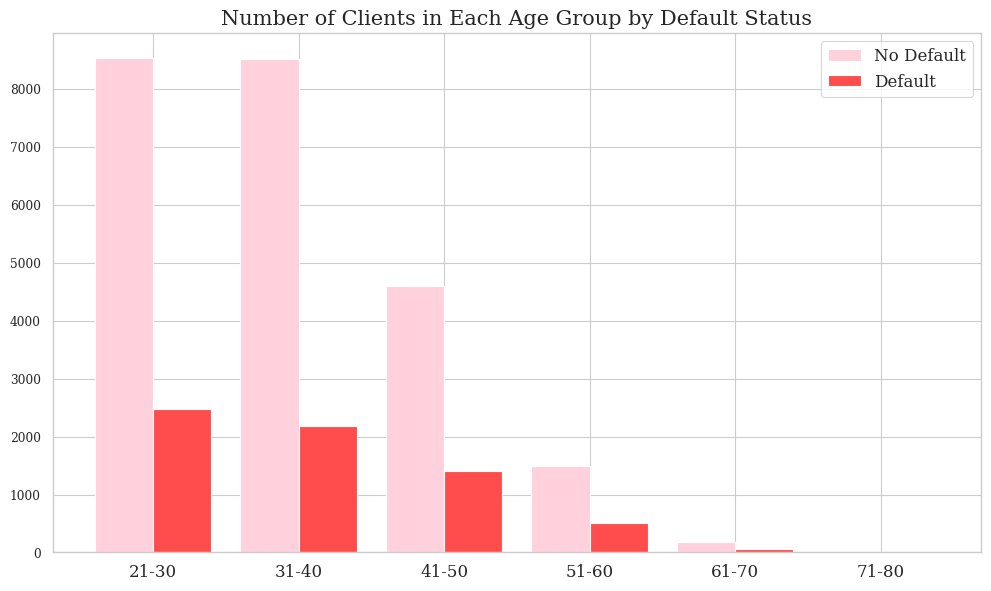

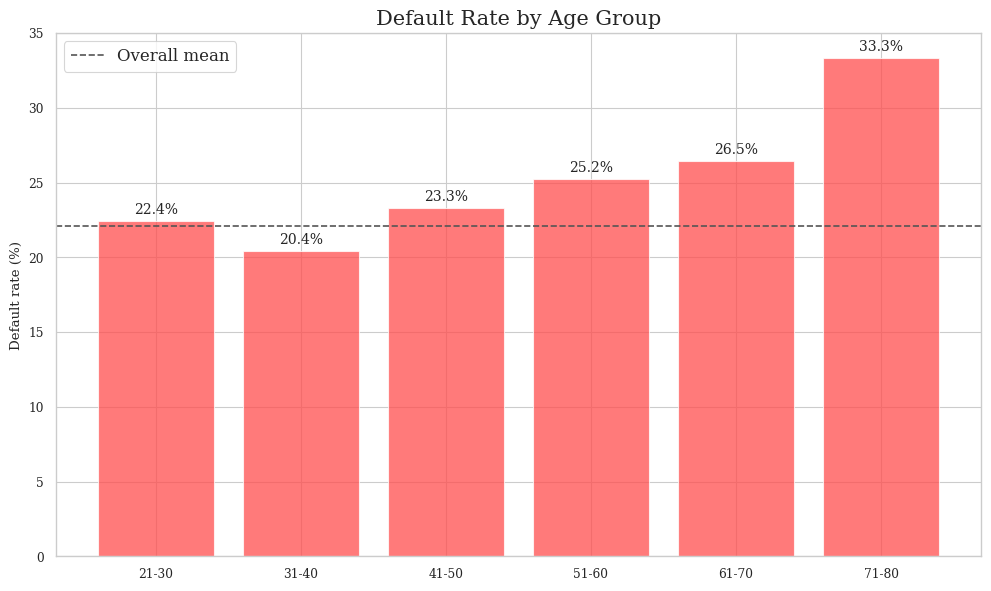

In [10]:
# ------------------------------------------------------------------------------
# 3.8 — Demographic Exploration: AGE
# ------------------------------------------------------------------------------

# Number of Clients in Each Age Group by Default Status
bins = [20, 30, 40, 50, 60, 70, 80]
names = ["21-30", "31-40", "41-50", "51-60", "61-70", "71-80"]
df["AGE_BIN"] = pd.cut(x=df["AGE"], bins=bins, labels=names, right=True)

age_0 = df[df["def_pay"] == 0]["AGE_BIN"].value_counts().sort_index()
age_1 = df[df["def_pay"] == 1]["AGE_BIN"].value_counts().sort_index()

x = np.arange(len(names))
width = 0.4
plt.figure(figsize=(10, 6))
plt.bar(x - width / 2, age_0.values, width, label="No Default", color=PAL[0], edgecolor="white")
plt.bar(x + width / 2, age_1.values, width, label="Default", color=PAL[1], edgecolor="white")
plt.xticks(x, names, fontsize=12)
plt.title("Number of Clients in Each Age Group by Default Status", fontsize=15)
plt.legend(fontsize=12)
plt.tight_layout()
plt.show()

# Observation: younger clients (21–30) show the highest absolute default counts,
# consistent with findings in Alfaiz & Fati (2022) and Arora et al. (2022).


# Default Rate by Age Group (key metric for Chapter 6 comparison)
age_dr = default_rate_by_feature(df, "AGE_BIN")
REAL_DEFAULT_RATES["AGE_BIN"] = age_dr

dr_vals = age_dr["default_rate_%"].values

plt.figure(figsize=(10, 6))
bars = plt.bar(names, dr_vals, color=PAL[1], alpha=0.75, edgecolor="white")
plt.axhline(df["def_pay"].mean() * 100, color="#555", linestyle="--", linewidth=1.2, label="Overall mean")

for bar, v in zip(bars, dr_vals):
    plt.text(bar.get_x() + bar.get_width() / 2, v + 0.3, f"{v:.1f}%",
             ha="center", va="bottom", fontsize=10)

plt.title("Default Rate by Age Group", fontsize=15)
plt.ylabel("Default rate (%)")
plt.ylim(0, 35)
plt.legend(fontsize=12)
plt.tight_layout()
plt.show()

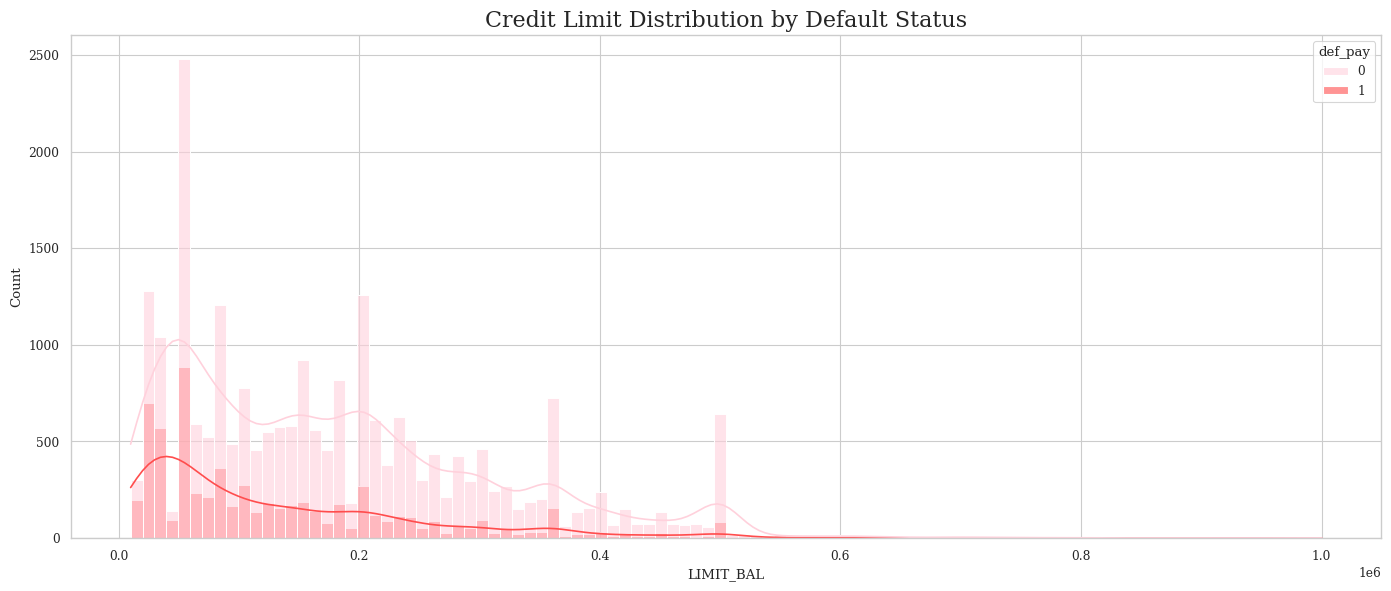

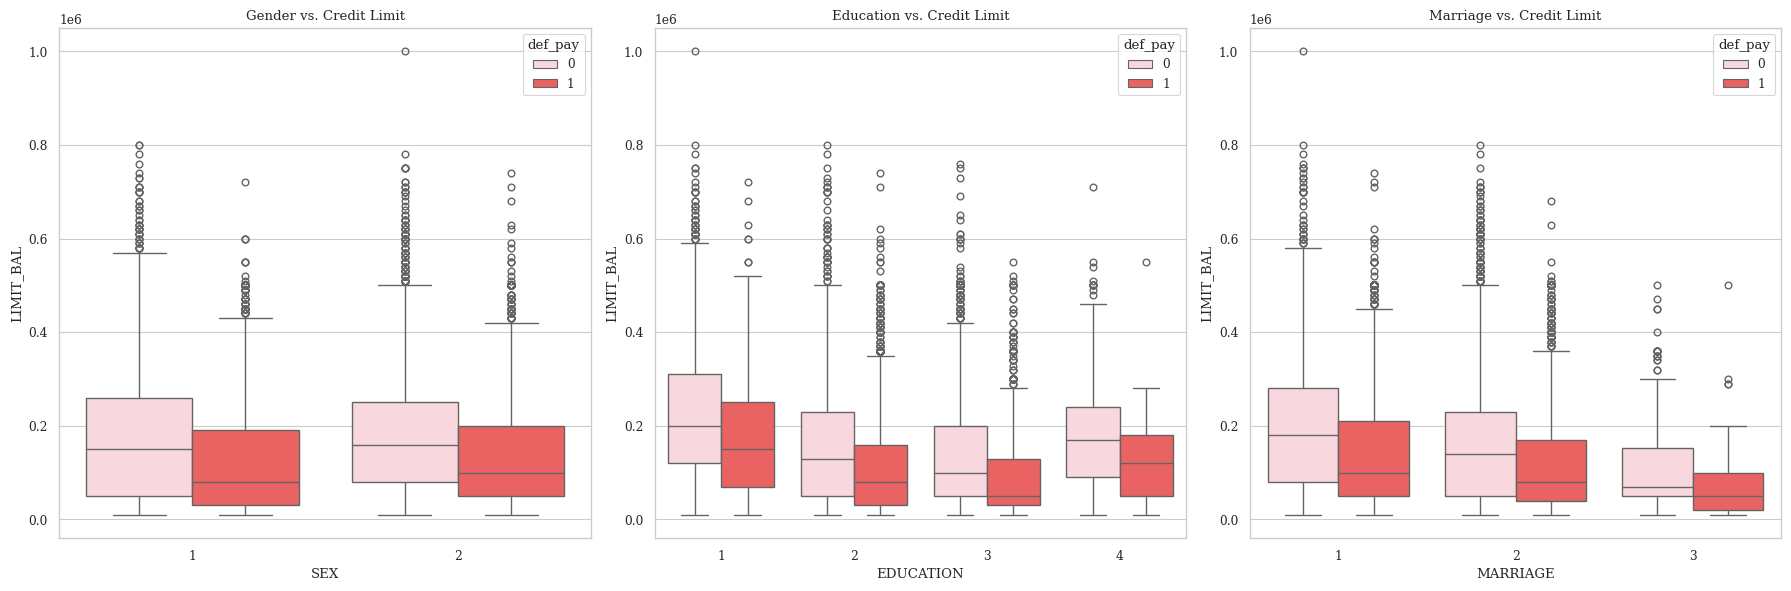

In [11]:
# ------------------------------------------------------------------------------
# 3.9 — Credit Limit Analysis vs Demographics
# ------------------------------------------------------------------------------
 
plt.figure(figsize=(14, 6))
plt.title("Credit Limit Distribution by Default Status", size=16)
sns.histplot(
    data=df, x="LIMIT_BAL", hue="def_pay", kde=True, bins=100,
    palette=["#FFD1DC", "#FF4D4D"], alpha=0.6,
)
plt.tight_layout()
plt.show()
 
f, axes = plt.subplots(1, 3, figsize=(18, 6))
sns.boxplot(x="SEX", y="LIMIT_BAL", hue="def_pay", data=df, palette=["#FFD1DC", "#FF4D4D"], ax=axes[0])
axes[0].set_title("Gender vs. Credit Limit")
sns.boxplot(x="EDUCATION", y="LIMIT_BAL", hue="def_pay", data=df, palette=["#FFD1DC", "#FF4D4D"], ax=axes[1])
axes[1].set_title("Education vs. Credit Limit")
sns.boxplot(x="MARRIAGE", y="LIMIT_BAL", hue="def_pay", data=df, palette=["#FFD1DC", "#FF4D4D"], ax=axes[2])
axes[2].set_title("Marriage vs. Credit Limit")
plt.tight_layout()
plt.show()

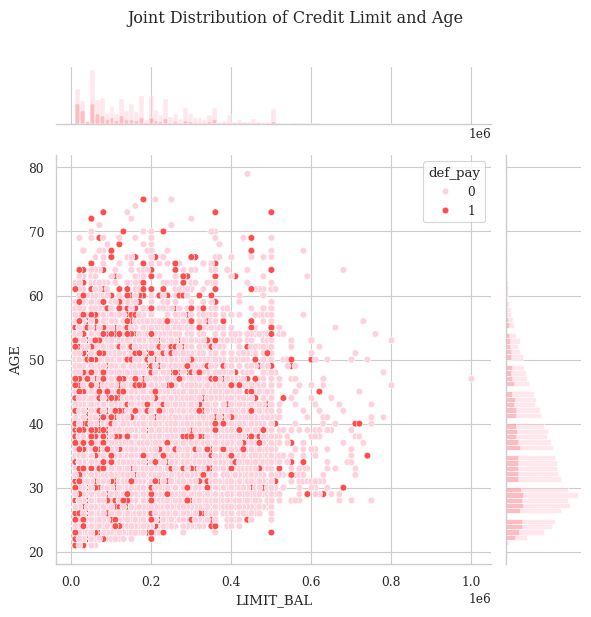

In [12]:
# ------------------------------------------------------------------------------
# 3.9.1 — ADDED FROM EXTENDED EDA: JointGrid (LIMIT_BAL vs AGE)
# ------------------------------------------------------------------------------
# This visualization reveals the bivariate relationship between credit limit
# and age, stratified by default status. It provides insight into whether
# younger defaulters exhibit systematically different credit limit patterns.
# ------------------------------------------------------------------------------

g = sns.JointGrid(data=df, x="LIMIT_BAL", y="AGE", hue='def_pay', 
                  palette=['#FFD1DC', '#FF4D4D'])
g.plot(sns.scatterplot, sns.histplot)
g.fig.suptitle('Joint Distribution of Credit Limit and Age', y=1.02)
plt.tight_layout()
plt.show()

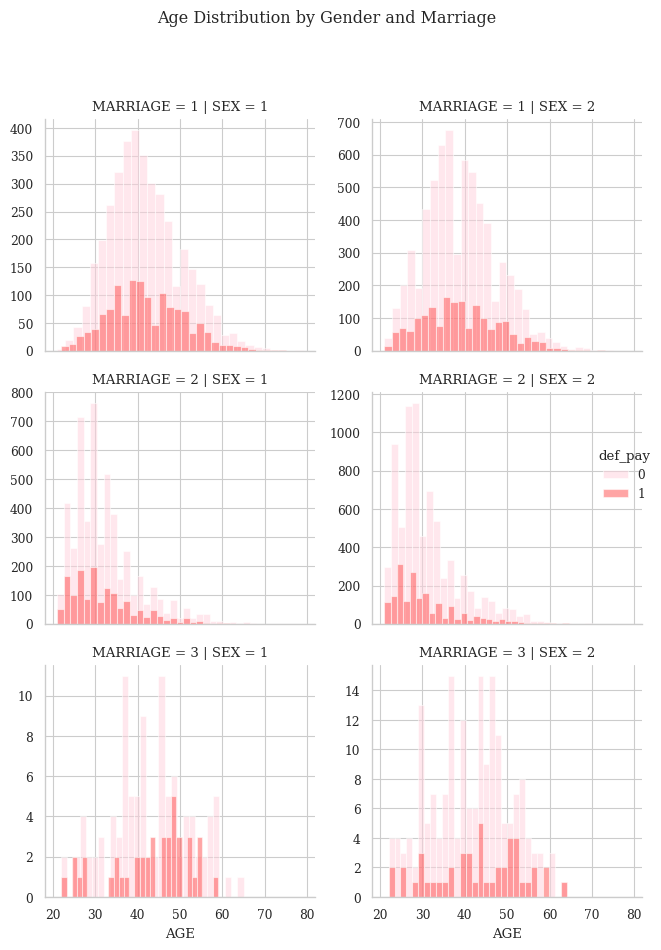

In [13]:
# ------------------------------------------------------------------------------
# 3.9.2 — ADDED FROM EXTENDED EDA: FacetGrid (AGE x SEX x MARRIAGE)
# ------------------------------------------------------------------------------
# This three-dimensional faceted visualization examines the interaction
# between gender, marital status, and age on default probability.
# Such complex interactions test the GAN's capacity to model multivariate
# dependencies (Zhao et al., 2023).
# ------------------------------------------------------------------------------

g = sns.FacetGrid(df, col='SEX', row="MARRIAGE", hue='def_pay', 
                  sharey=False, palette=['#FFD1DC', '#FF4D4D'])
g.map(plt.hist, 'AGE', alpha=0.5, bins=30)
g.add_legend()
g.fig.suptitle('Age Distribution by Gender and Marriage', y=1.05)
plt.tight_layout()
plt.show()

<Figure size 1000x600 with 0 Axes>

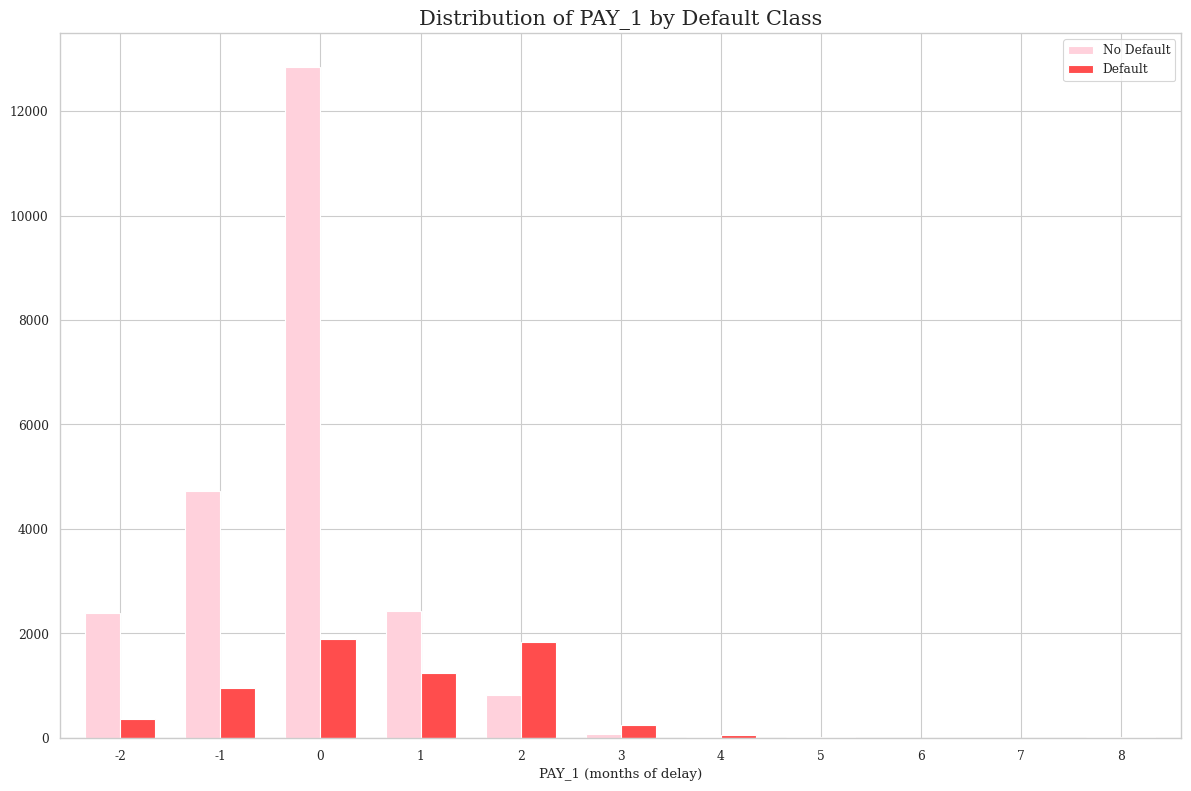

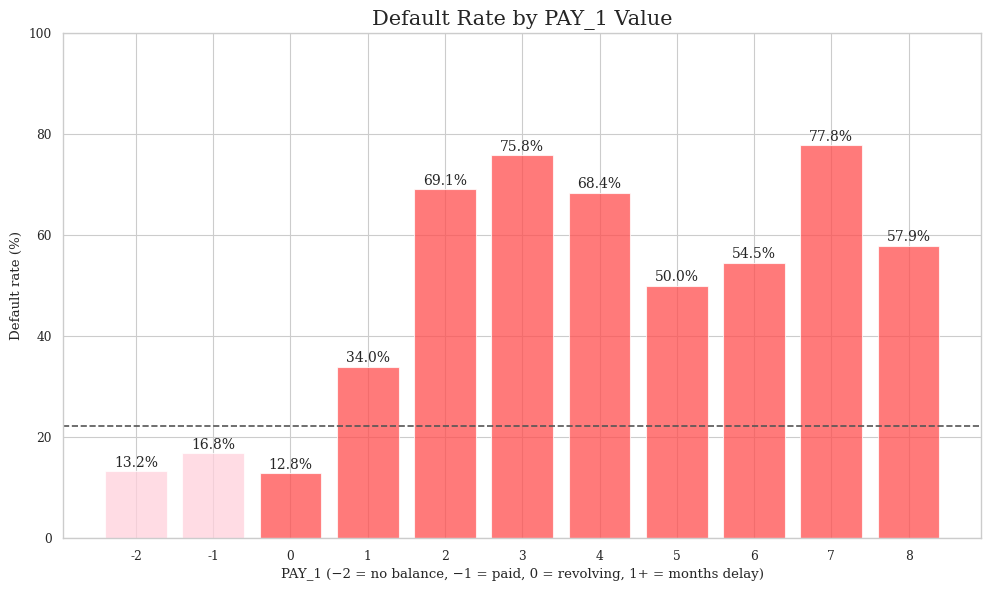


Key insight: Default rate increases sharply for PAY_1 > 0.
GANs MUST replicate this ordinal relationship — validated in Chapter 6.

Default rates by PAY_1:
       n_default  n_total  default_rate_%
PAY_1                                    
-2           365     2759           13.23
-1           954     5686           16.78
 0          1888    14737           12.81
 1          1252     3688           33.95
 2          1844     2667           69.14
 3           244      322           75.78
 4            52       76           68.42
 5            13       26           50.00
 6             6       11           54.55
 7             7        9           77.78
 8            11       19           57.89


In [14]:
# ------------------------------------------------------------------------------
# 3.10 — PAY_X: Detailed Ordinal Analysis and Default Rate
# ------------------------------------------------------------------------------

# This section establishes critical groundwork: the default rate by PAY_1 value
# is the most important metric to validate whether GANs correctly capture the
# ordinal relationship between payment delay and default risk.

# Default rate by PAY_1 value (strongest predictor)
pay1_dr = default_rate_by_feature(df, "PAY_1")
REAL_DEFAULT_RATES["PAY_1"] = pay1_dr

# Distribution of PAY_1 by Default Class (absolute counts)
pay1_counts = df.groupby(["PAY_1", "def_pay"]).size().unstack(fill_value=0)

plt.figure(figsize=(10, 6))
pay1_counts.plot(kind="bar", color=PAL, edgecolor="white", width=0.7)
plt.title("Distribution of PAY_1 by Default Class", fontsize=15)
plt.xlabel("PAY_1 (months of delay)")
plt.xticks(rotation=0)
plt.legend(["No Default", "Default"])
plt.tight_layout()
plt.show()

# Default Rate by PAY_1 Value (key metric for Chapter 6 validation)
pay1_dr_plot = pay1_dr.reset_index()
colors_bar = [PAL[1] if v >= 0 else PAL[0] for v in pay1_dr_plot["PAY_1"]]

plt.figure(figsize=(10, 6))
bars = plt.bar(pay1_dr_plot["PAY_1"].astype(str),
               pay1_dr_plot["default_rate_%"],
               color=colors_bar, alpha=0.75, edgecolor="white")

plt.axhline(df["def_pay"].mean() * 100, color="#555", linestyle="--", linewidth=1.2)

for bar, v in zip(bars, pay1_dr_plot["default_rate_%"]):
    plt.text(bar.get_x() + bar.get_width() / 2, v + 0.3, f"{v:.1f}%",
             ha="center", va="bottom", fontsize=10)

plt.title("Default Rate by PAY_1 Value", fontsize=15)
plt.xlabel("PAY_1 (−2 = no balance, −1 = paid, 0 = revolving, 1+ = months delay)")
plt.ylabel("Default rate (%)")
plt.ylim(0, 100)
plt.tight_layout()
plt.show()

print("\nKey insight: Default rate increases sharply for PAY_1 > 0.")
print("GANs MUST replicate this ordinal relationship — validated in Chapter 6.")
print("\nDefault rates by PAY_1:")
print(pay1_dr)

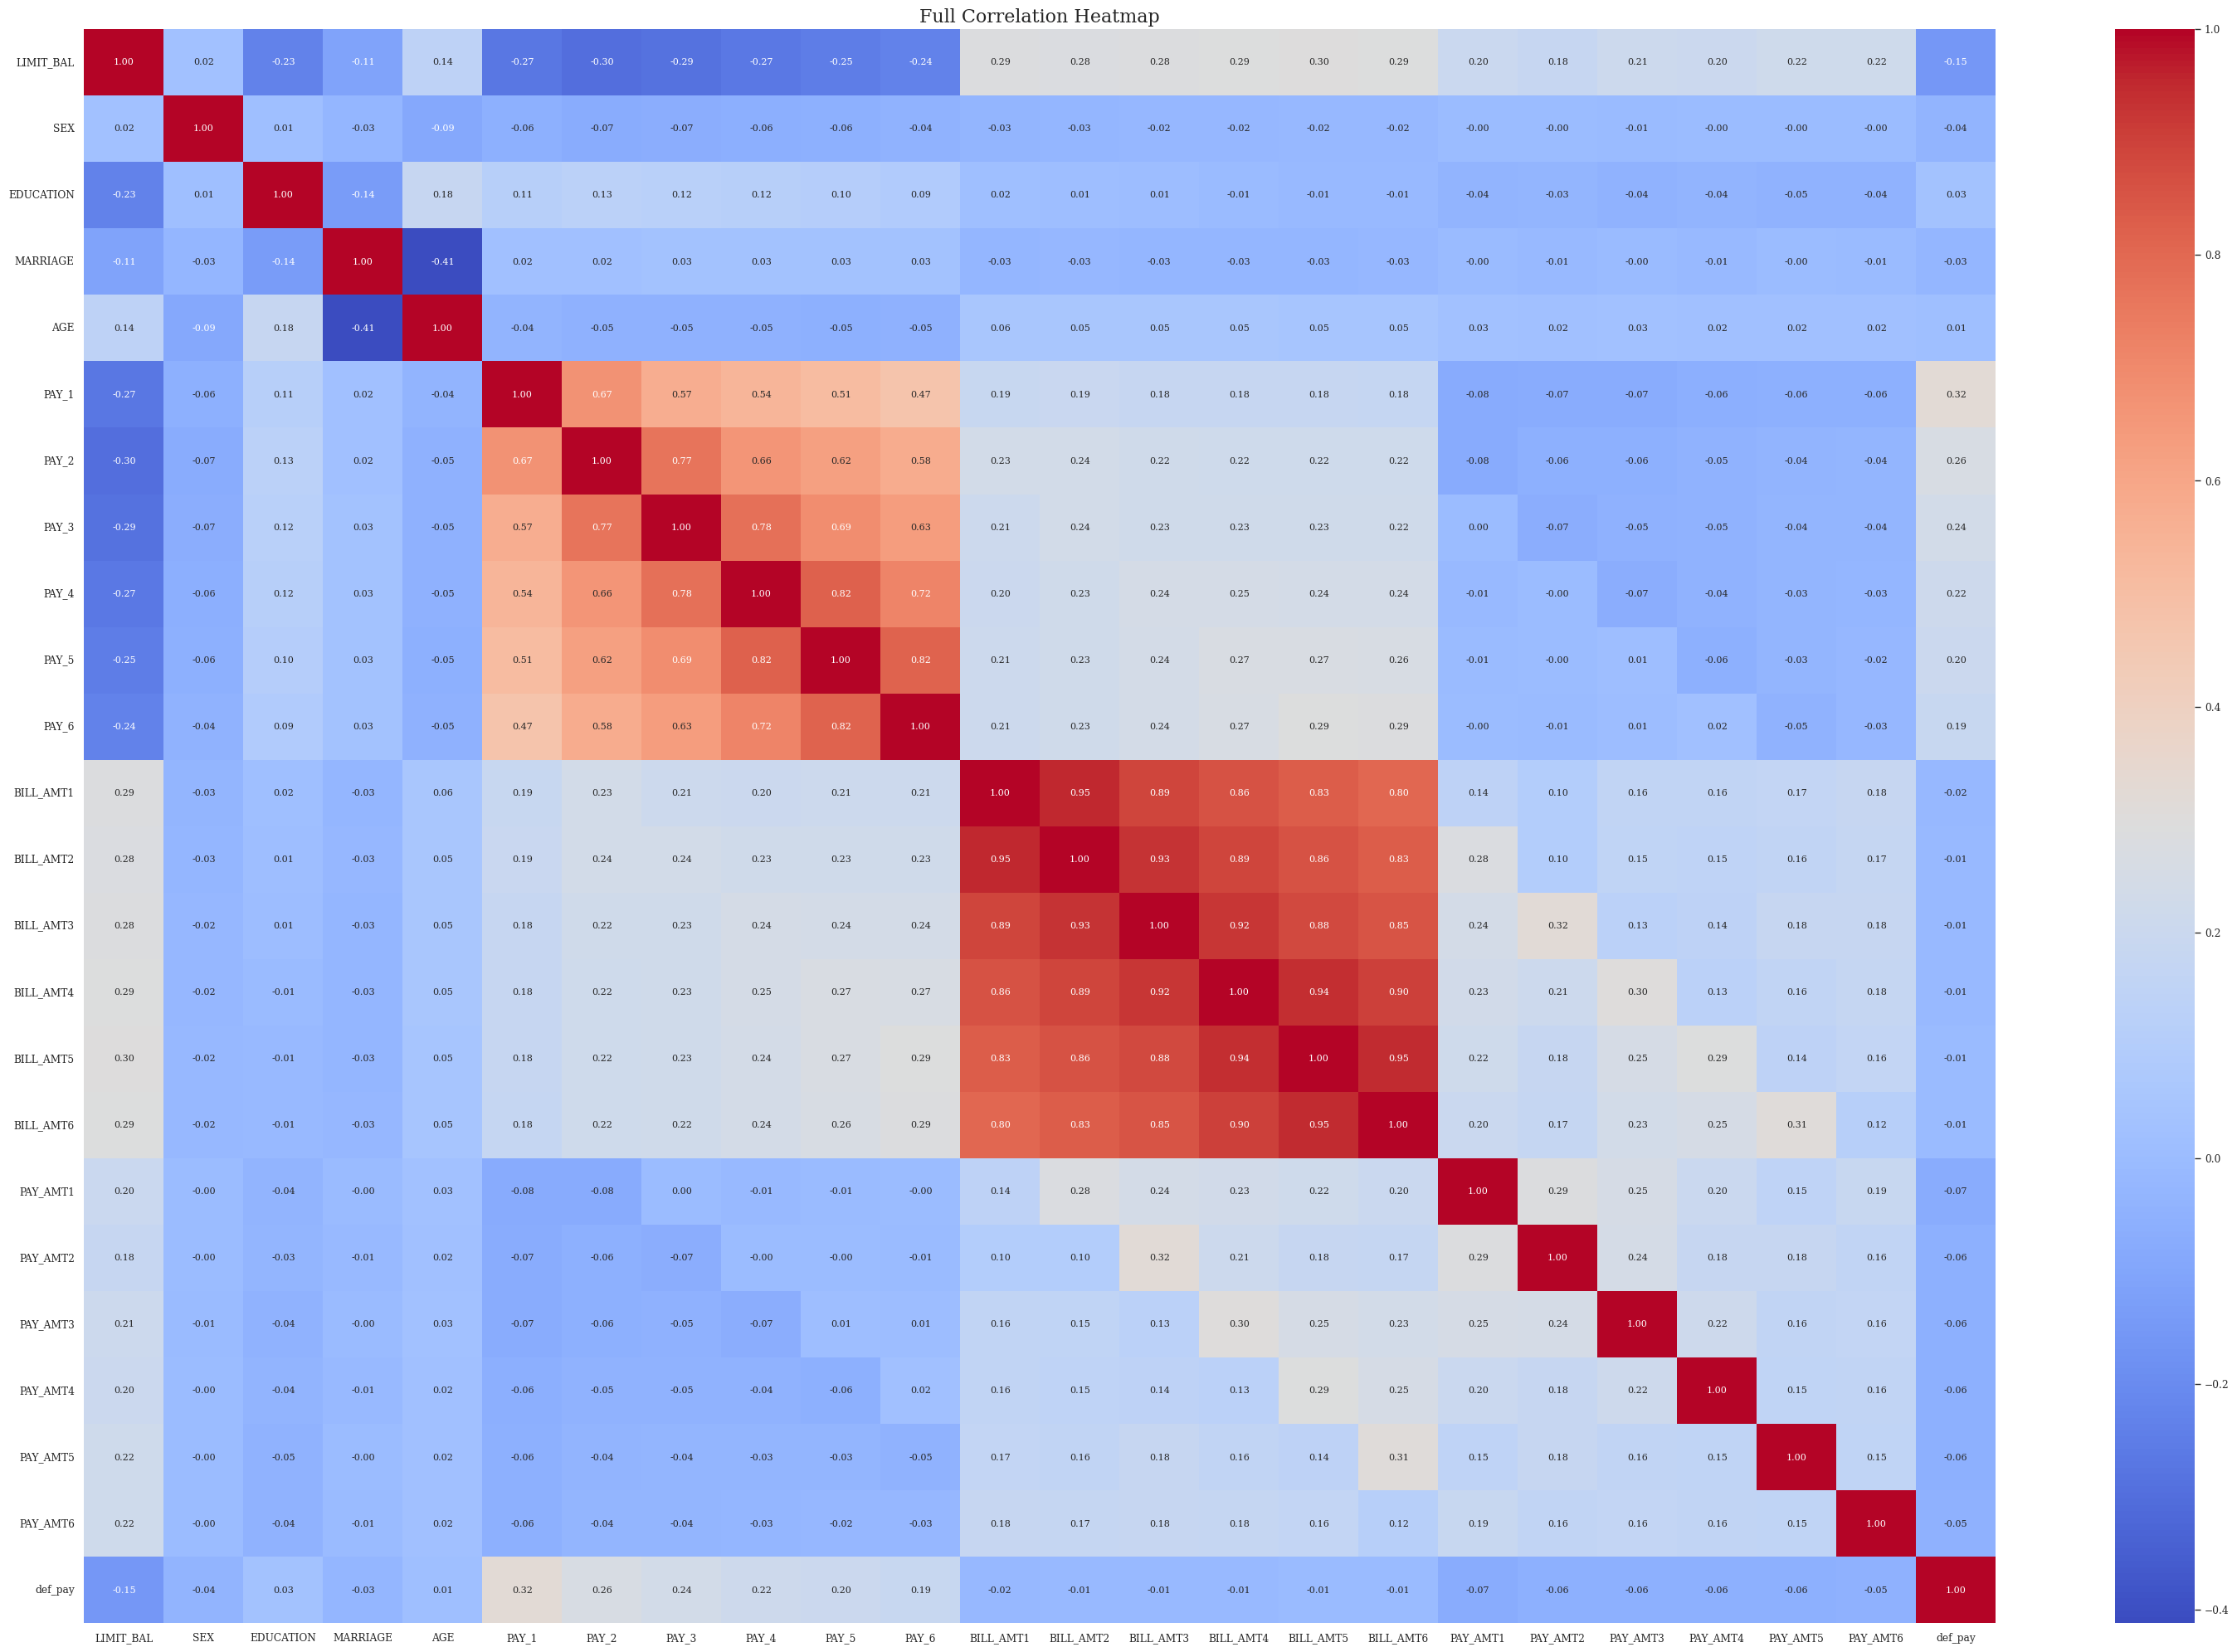

In [15]:
# ------------------------------------------------------------------------------
# 3.11 — Multicollinearity Analysis (Heatmap) — CORRECTED
# ------------------------------------------------------------------------------
# The heatmap now uses fmt=".2f" to limit decimal places and annot_kws for
# font size, preventing the cluttered, unreadable output from the extended EDA.
# ------------------------------------------------------------------------------
 
numeric_df = df.drop("AGE_BIN", axis=1)
corrmat = numeric_df.corr()
k = 10
cols = corrmat["def_pay"].abs().nlargest(k).index
 
plt.figure(figsize=(30, 20))
sns.heatmap(numeric_df.corr(), annot=True, fmt=".2f", cmap="coolwarm",
            annot_kws={'size': 8})
plt.title("Full Correlation Heatmap", fontsize=16)
plt.tight_layout()
plt.show()
 
# Note on multicollinearity: BILL_AMT2-6 show high pairwise correlation
# (Pearson r >= 0.92), consistent with the findings of MatteoM95 et al.
# For this study, all features are retained to preserve the full input space
# for the GAN models. Feature selection is orthogonal to the generative
# modelling objective.

Top 10 correlations with def_pay:
PAY_1        0.3248
PAY_2        0.2636
PAY_3        0.2353
PAY_4        0.2166
PAY_5        0.2041
PAY_6        0.1869
LIMIT_BAL    0.1535
PAY_AMT1     0.0729
PAY_AMT2     0.0586
PAY_AMT4     0.0568
Name: def_pay, dtype: float64


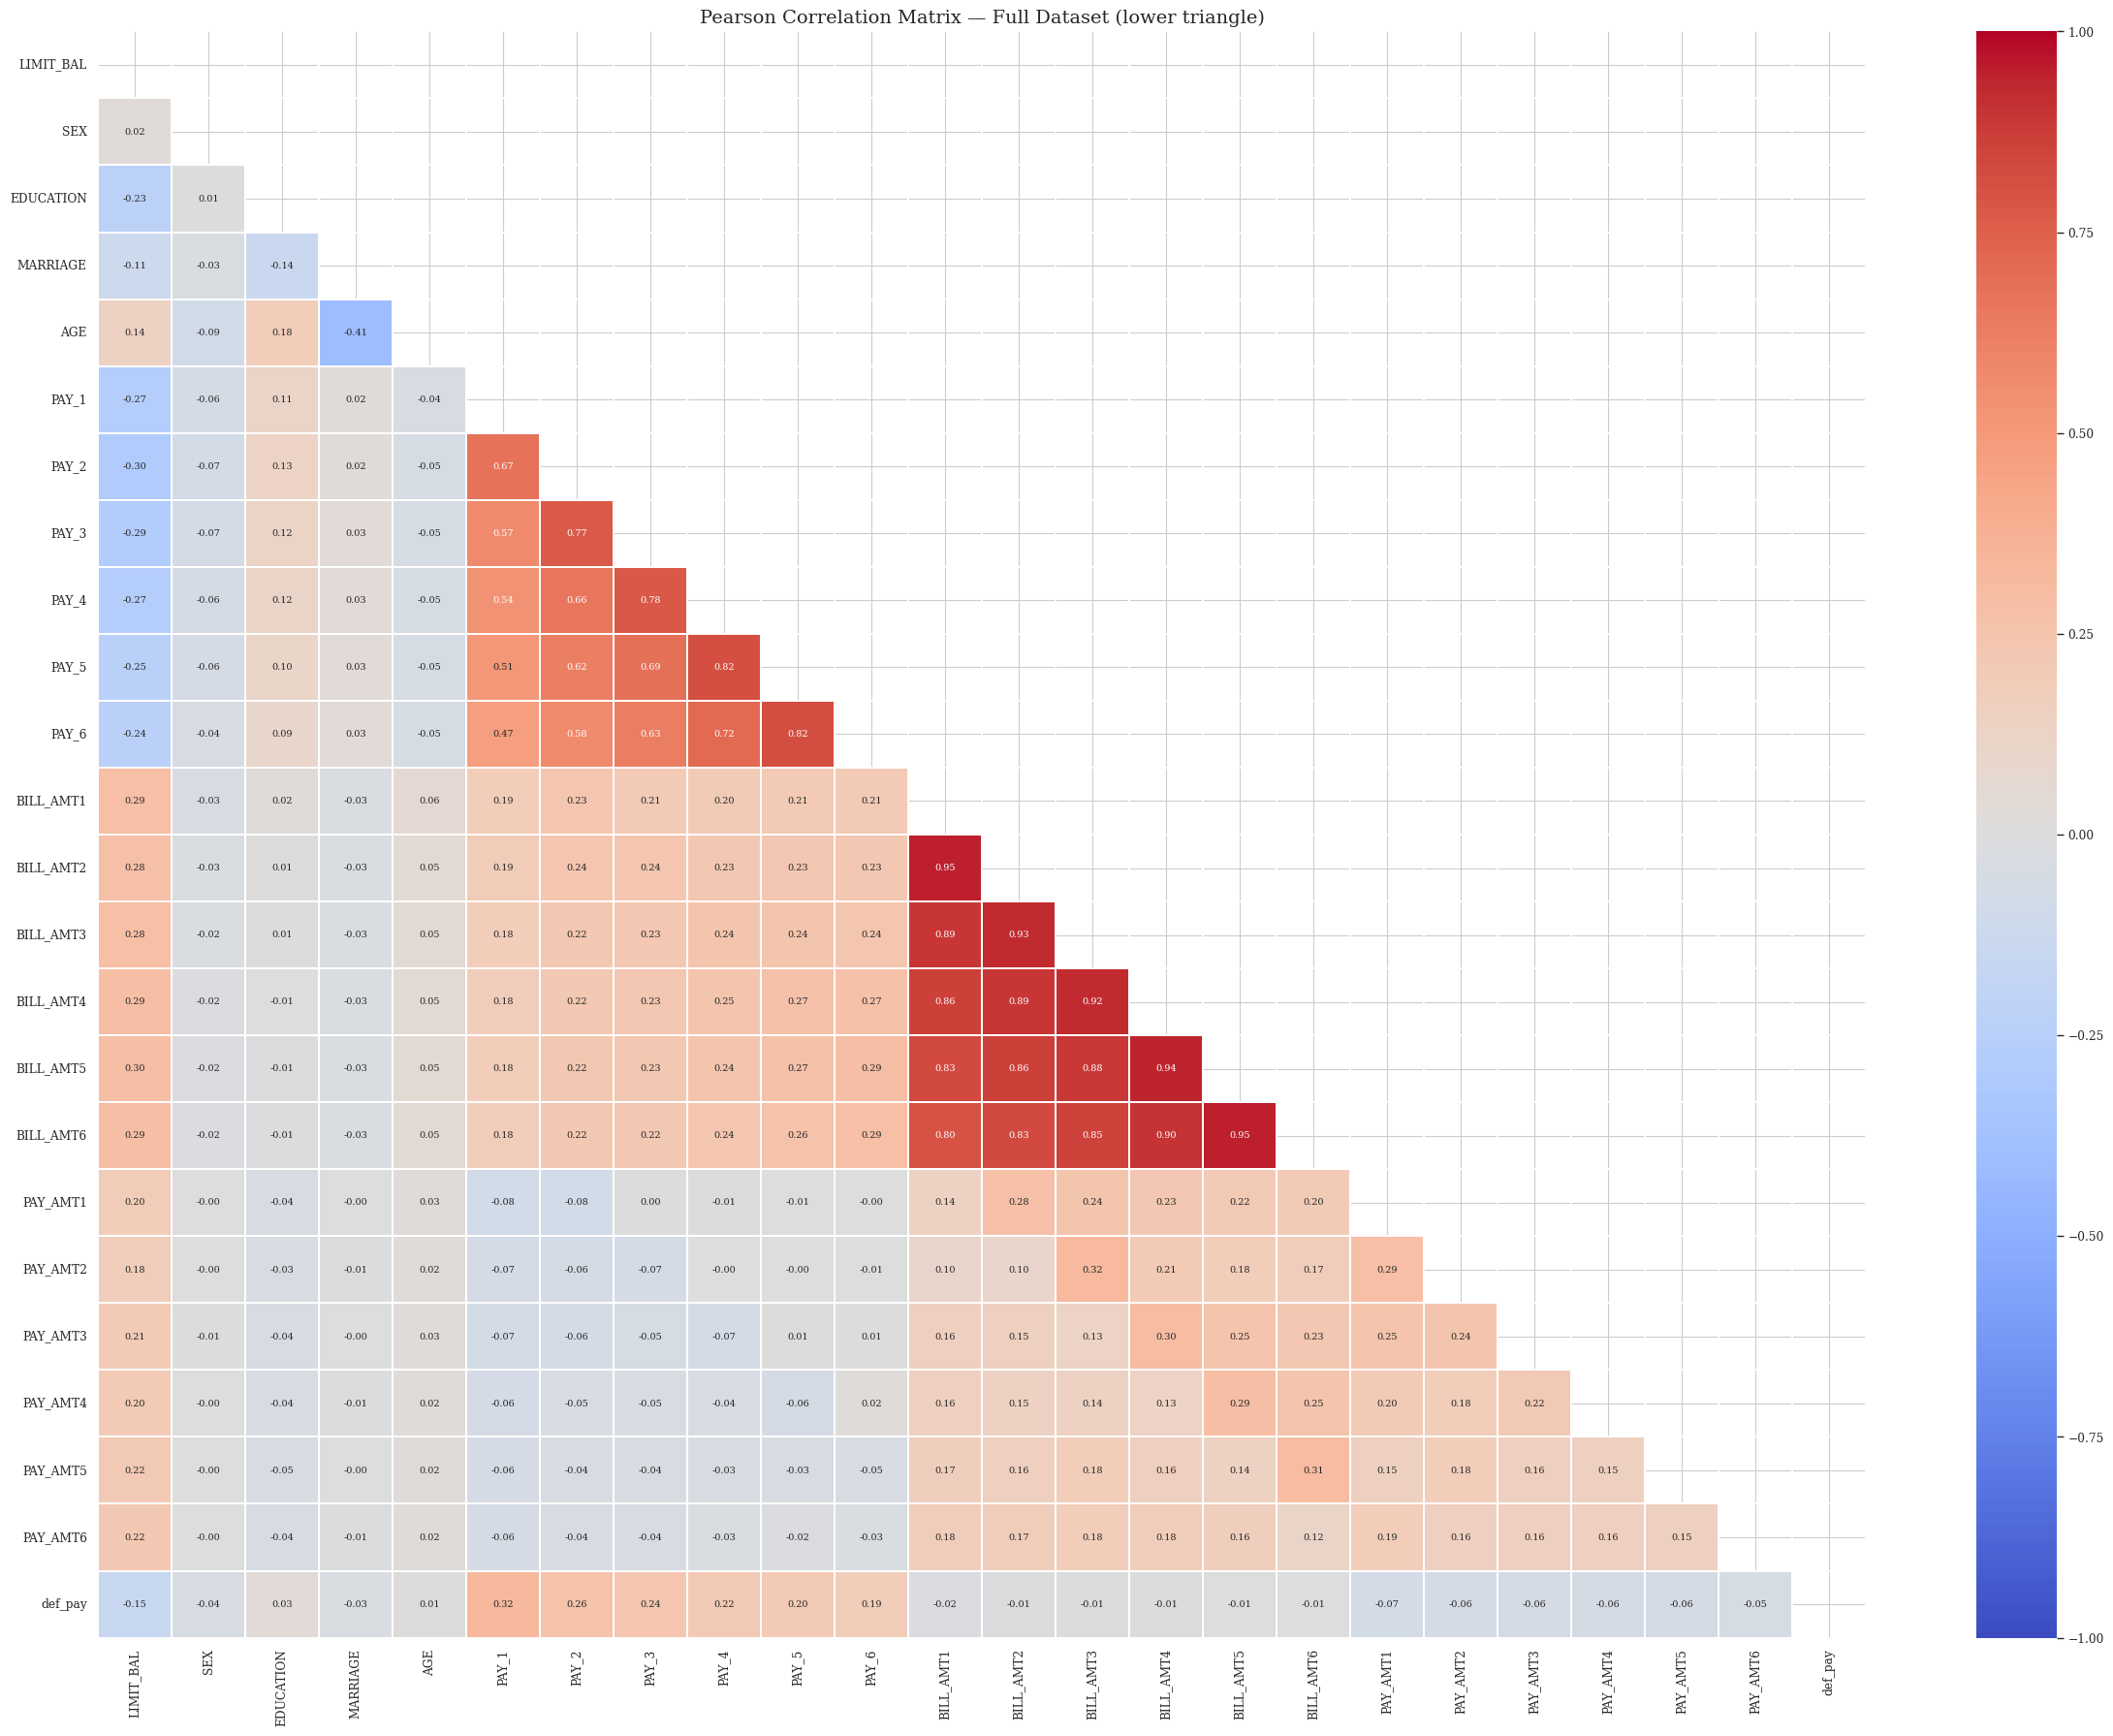


Real correlation matrix stored in REAL_CORR_MATRIX.

Note: BILL_AMT2–6 exhibit r ≥ 0.92 among themselves (severe multicollinearity).
This is a demanding benchmark for GANs — they should replicate this structure.


In [16]:
# ------------------------------------------------------------------------------
# 3.11 — Correlation Analysis (Pearson)
# ------------------------------------------------------------------------------

# Compute correlation matrix (excluding AGE_BIN if present)
numeric_df = df.drop("AGE_BIN", axis=1, errors="ignore")
corr_matrix = numeric_df.corr()

# Top 10 correlations with def_pay (absolute values)
top_corr = corr_matrix["def_pay"].abs().nlargest(11).drop("def_pay")
print("Top 10 correlations with def_pay:")
print(top_corr.round(4))

# Full correlation heatmap (lower triangle)
fig, ax = plt.subplots(figsize=(24, 18))
mask = np.zeros_like(corr_matrix, dtype=bool)
mask[np.triu_indices_from(mask)] = True

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    annot_kws={"size": 7},
    ax=ax,
    mask=mask,
    vmin=-1,
    vmax=1,
    linewidths=0.3
)

ax.set_title("Pearson Correlation Matrix — Full Dataset (lower triangle)", fontsize=14)
plt.tight_layout()
plt.show()

# Store real correlation matrix for future comparison
REAL_CORR_MATRIX = corr_matrix.copy()

print("\nReal correlation matrix stored in REAL_CORR_MATRIX.")
print("\nNote: BILL_AMT2–6 exhibit r ≥ 0.92 among themselves (severe multicollinearity).")
print("This is a demanding benchmark for GANs — they should replicate this structure.")

Explained variance: PC1 = 28.4%, PC2 = 17.8%, total = 46.3%


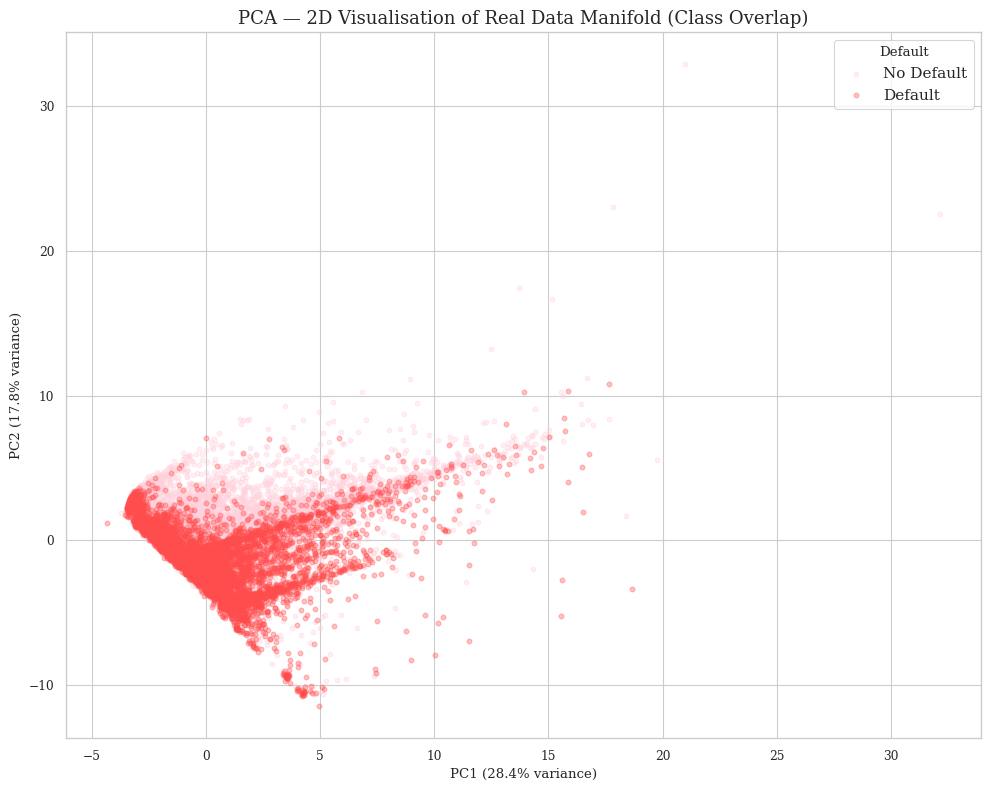


Insight: Substantial class overlap in 2D indicates that the decision
boundary is not linearly separable, justifying the use of non-linear models.
In Chapter 6, synthetic samples will be projected onto this same PCA space
to assess whether GANs preserve the real data manifold structure.


In [17]:
# ------------------------------------------------------------------------------
# 3.12 — PCA: Manifold Visualisation (EDA ONLY — NO DATA LEAKAGE)
# ------------------------------------------------------------------------------

# IMPORTANT METHODOLOGICAL NOTE:
# This PCA is applied to the FULL dataset exclusively for exploratory
# visualization purposes. The scaler used here is NOT the canonical scaler
# used for model training. No information from this step is used in the
# train/test split or downstream models. Therefore, no data leakage is introduced.
#
# The objective is to understand the global structure of the real data manifold
# and class separability in a reduced 2D space.
# ------------------------------------------------------------------------------

# Feature-target split
X_full = numeric_df.drop("def_pay", axis=1)
y_full = numeric_df["def_pay"]

# Standardization (PCA requires centered/scaled data)
scaler_pca = StandardScaler()
X_pca_scaled = scaler_pca.fit_transform(X_full)

# PCA projection to 2D
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_pca_scaled)

# Create DataFrame for visualization
pca_df = pd.DataFrame(X_pca, columns=["PC1", "PC2"])
pca_df["def_pay"] = y_full.values

# Explained variance (quantitative interpretability)
explained = pca.explained_variance_ratio_
print(f"Explained variance: PC1 = {explained[0]:.1%}, "
      f"PC2 = {explained[1]:.1%}, total = {sum(explained):.1%}")

# Scatter plot (class overlap visualization)
fig, ax = plt.subplots(figsize=(10, 8))

for cls, label, color in zip([0, 1], ["No Default", "Default"], PAL):
    mask = pca_df["def_pay"] == cls
    ax.scatter(
        pca_df.loc[mask, "PC1"],
        pca_df.loc[mask, "PC2"],
        c=color,
        label=label,
        alpha=0.35,
        s=12
    )

ax.set_xlabel(f"PC1 ({explained[0]:.1%} variance)")
ax.set_ylabel(f"PC2 ({explained[1]:.1%} variance)")
ax.set_title("PCA — 2D Visualisation of Real Data Manifold (Class Overlap)", fontsize=13)
ax.legend(title="Default", fontsize=11)

plt.tight_layout()
plt.show()

# Store PCA projection for direct comparison with synthetic data (Chapter 6)
REAL_PCA_COMPONENTS = pca_df.copy()

# Key insight
print("\nInsight: Substantial class overlap in 2D indicates that the decision")
print("boundary is not linearly separable, justifying the use of non-linear models.")
print("In Chapter 6, synthetic samples will be projected onto this same PCA space")
print("to assess whether GANs preserve the real data manifold structure.")

In [18]:
# ------------------------------------------------------------------------------
# 3.13 — Canonical Train/Test Split and Scaler (PIPELINE FOUNDATION)
# ------------------------------------------------------------------------------

# IMPORTANT METHODOLOGICAL NOTE:
# This block defines the SINGLE canonical data split and preprocessing pipeline
# reused across all subsequent chapters (baselines, SMOTE, CTGAN, CTAB-GAN+).
# These objects MUST NOT be modified after this point to ensure full
# experimental consistency and comparability.

# RATIONALE:
#   (1) The train/test split is performed BEFORE any scaling or augmentation.
#       This prevents data leakage from the test set into preprocessing
#       (Kaufman et al., 2012).
#
#   (2) The StandardScaler is fitted ONLY on X_train (raw data) and then reused
#       (transform only, no re-fitting) for:
#           - X_test
#           - SMOTE-generated data
#           - CTGAN synthetic data
#           - CTAB-GAN+ synthetic data
#
#   (3) GAN-based models (CTGAN, CTAB-GAN+) are trained on RAW (unscaled) data.
#       Their internal normalization mechanisms (e.g., Mode-Specific
#       Normalization) are designed to handle mixed-type data distributions.
#       Pre-scaling would distort categorical semantics and harm generation
#       quality (Xu et al., 2019; Zhao et al., 2023).
#
#   (4) Stratified splitting preserves the original class imbalance (~22%
#       default rate) in both training and test sets, ensuring fair evaluation
#       (Alfaiz & Fati, 2022).
# ------------------------------------------------------------------------------

# Remove temporary EDA column (if still present)
if "AGE_BIN" in df.columns:
    df.drop("AGE_BIN", axis=1, inplace=True)

# Feature-target split
X = df.drop("def_pay", axis=1)
y = df["def_pay"]

# *** SINGLE canonical split (70/30, stratified) ***
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    stratify=y,
    random_state=RANDOM_STATE
)

# *** SINGLE canonical scaler — fitted ONCE on X_train ***
# IMPORTANT: This scaler must NEVER be re-fitted on any other dataset
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)   # fit + transform (train only)
X_test_scaled  = scaler.transform(X_test)        # transform only (no re-fit)

# Diagnostics (sanity checks)
print("Canonical split defined:")
print(f"  Train shape: {X_train.shape} | Default rate: {y_train.mean():.4f}")
print(f"  Test shape:  {X_test.shape}  | Default rate: {y_test.mean():.4f}")

print("\nScaler fitted on X_train — ready for consistent transformation of all datasets.")

# Final note for downstream chapters
print("\nPipeline ready: All subsequent models and synthetic data evaluations")
print("will strictly reuse this split and scaler to ensure methodological consistency.")

Canonical split defined:
  Train shape: (21000, 23) | Default rate: 0.2212
  Test shape:  (9000, 23)  | Default rate: 0.2212

Scaler fitted on X_train — ready for consistent transformation of all datasets.

Pipeline ready: All subsequent models and synthetic data evaluations
will strictly reuse this split and scaler to ensure methodological consistency.


In [19]:
# ==============================================================================
# CHAPTER 3G: GROUNDWORK: Reference Metrics on Real Data
# ==============================================================================
# This section is the **quantitative foundation of Chapter 6**.
# It computes all metrics on the real minority data (`train_minority_raw`) before any synthetic data generation. 
# These metrics will serve as the "Real" baseline columns in the comparison tables.

# METRICS COMPUTED:
#   TVD (Total Variation Distance) for categorical and ordinal variables  
#   KS (Kolmogorov–Smirnov) for continuous variables  
#   Wasserstein Distance for continuous variables  
#   Correlation matrix of the real minority data  
#   Nearest-neighbour distances (Proximity — He et al. Property 1)  
#   Z-scores for Sensitivity (He et al. Property 4)  
#   Domain rule boundaries (Feasibility — He et al. Property 6) 

In [20]:
# Prepare real minority dataset (foundation for all comparisons)
train_data_raw      = X_train.copy()
train_data_raw["def_pay"] = y_train.values
train_data_full     = train_data_raw.copy()     # full training dataset (for CTAB-GAN+)
train_minority_raw  = train_data_raw[train_data_raw["def_pay"] == 1].drop("def_pay", axis=1).copy()
train_majority_raw  = train_data_raw[train_data_raw["def_pay"] == 0].drop("def_pay", axis=1).copy()

print("Training subsets prepared")
print(f"  train_data_full:     {train_data_full.shape}")
print(f"  train_minority_raw:  {train_minority_raw.shape}  (def_pay == 1)")
print(f"  train_majority_raw:  {train_majority_raw.shape}  (def_pay == 0)")

Training subsets prepared
  train_data_full:     (21000, 24)
  train_minority_raw:  (4645, 23)  (def_pay == 1)
  train_majority_raw:  (16355, 23)  (def_pay == 0)


In [21]:
# Feature type definition
CATEGORICAL_COLS = ["SEX", "EDUCATION", "MARRIAGE"]
ORDINAL_COLS     = ["PAY_1", "PAY_2", "PAY_3", "PAY_4", "PAY_5", "PAY_6"]
CONTINUOUS_COLS  = [
    "LIMIT_BAL", "AGE",
    "BILL_AMT1", "BILL_AMT2", "BILL_AMT3", "BILL_AMT4", "BILL_AMT5", "BILL_AMT6",
    "PAY_AMT1",  "PAY_AMT2",  "PAY_AMT3",  "PAY_AMT4",  "PAY_AMT5",  "PAY_AMT6",
]

print("Categorical columns: ", CATEGORICAL_COLS)
print("Ordinal columns:     ", ORDINAL_COLS)
print("Continuous columns:  ", CONTINUOUS_COLS)

Categorical columns:  ['SEX', 'EDUCATION', 'MARRIAGE']
Ordinal columns:      ['PAY_1', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6']
Continuous columns:   ['LIMIT_BAL', 'AGE', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6']


In [22]:
# ==============================================================================
# CHAPTER 3.G.1: TVD (Total Variation Distance) — Reference for categorical and ordinal distributions
# ==============================================================================

# Total Variation Distance measures the maximum discrepancy between two probability distributions.
# For categorical variables, TVD = 0 indicates identical distributions, while TVD = 1 indicates complete divergence.

# Here, we compute TVD within the real data, comparing minority vs majority classes.
# This provides the natural class separation baseline that generative models should reproduce.
# GAN should be able to reproduce the minority not the majority.

In [23]:
def compute_tvd(series_a, series_b):
    """
    Total Variation Distance between two categorical/ordinal series.
    TVD = 0.5 * sum(|P(x) - Q(x)|)
    """
    all_vals = sorted(set(series_a.unique()) | set(series_b.unique()))
    p = series_a.value_counts(normalize=True).reindex(all_vals, fill_value=0)
    q = series_b.value_counts(normalize=True).reindex(all_vals, fill_value=0)
    return 0.5 * np.abs(p - q).sum()


def compute_ks(series_a, series_b):
    """Kolmogorov-Smirnov statistic between two samples."""
    stat, pval = stats.ks_2samp(series_a.dropna(), series_b.dropna())
    return stat, pval


def compute_wasserstein(series_a, series_b):
    """Wasserstein (Earth Mover’s) distance between two distributions."""
    return stats.wasserstein_distance(series_a.dropna(), series_b.dropna())


print("Statistical fidelity functions defined: compute_tvd, compute_ks, compute_wasserstein")

Statistical fidelity functions defined: compute_tvd, compute_ks, compute_wasserstein


In [24]:
# TVD: Real Minority vs Real Majority
# This represents the intrinsic class separation baseline, i.e., the natural difficulty of the learning problem.

tvd_min_vs_maj = {}
for col in CATEGORICAL_COLS + ORDINAL_COLS:
    tvd = compute_tvd(train_minority_raw[col], train_majority_raw[col])
    tvd_min_vs_maj[col] = round(tvd, 4)

print("TVD: Real Minority vs Real Majority")
print("(Natural class separation baseline — GAN difficulty benchmark)\n")

tvd_df = pd.DataFrame.from_dict(
    tvd_min_vs_maj,
    orient="index",
    columns=["TVD (Minority vs Majority)"]
)

tvd_df["Type"] = ["categorical"] * 3 + ["ordinal"] * 6
print(tvd_df.sort_values("TVD (Minority vs Majority)", ascending=False))

REAL_TVD_REFERENCE = tvd_min_vs_maj.copy()

TVD: Real Minority vs Real Majority
(Natural class separation baseline — GAN difficulty benchmark)

           TVD (Minority vs Majority)         Type
PAY_1                          0.3690      ordinal
PAY_2                          0.2941      ordinal
PAY_3                          0.2531      ordinal
PAY_4                          0.2205      ordinal
PAY_5                          0.1928      ordinal
PAY_6                          0.1803      ordinal
EDUCATION                      0.0717  categorical
SEX                            0.0480  categorical
MARRIAGE                       0.0309  categorical


In [25]:
# Continuous distribution statistics (minority baseline)

ks_reference = {}
wasserstein_reference = {}

print("Real Minority Statistics — Continuous Variables")
print("(Baseline reference for Chapter 6 comparisons)\n")

for col in CONTINUOUS_COLS:
    s = train_minority_raw[col].astype(float)
    ks_reference[col] = {
        "mean": s.mean(),
        "std":  s.std(),
        "p25":  s.quantile(0.25),
        "p50":  s.median(),
        "p75":  s.quantile(0.75),
        "p95":  s.quantile(0.95),
        "p99":  s.quantile(0.99),
    }

ks_ref_df = pd.DataFrame(ks_reference).T.round(2)
print(ks_ref_df)

REAL_CONTINUOUS_STATS = ks_ref_df.copy()
print("\nSaved in REAL_CONTINUOUS_STATS.")

Real Minority Statistics — Continuous Variables
(Baseline reference for Chapter 6 comparisons)

                mean        std      p25      p50       p75       p95  \
LIMIT_BAL  130877.86  115896.59  50000.0  90000.0  200000.0  360000.0   
AGE            35.62       9.71     28.0     34.0      42.0      53.0   
BILL_AMT1   48651.71   73432.46   3030.0  20290.0   60455.0  195297.6   
BILL_AMT2   47673.92   71768.34   2524.0  20380.0   58941.0  190528.8   
BILL_AMT3   45637.28   68749.32   2500.0  19930.0   56950.0  180487.2   
BILL_AMT4   42611.56   64887.37   2140.0  19305.0   50767.0  175063.8   
BILL_AMT5   39816.49   61219.03   1505.0  18535.0   48026.0  165826.4   
BILL_AMT6   38541.87   59608.84   1150.0  18134.0   47740.0  159452.8   
PAY_AMT1     3491.94   10489.57      0.0   1604.0    3472.0   11175.2   
PAY_AMT2     3358.30   11018.02      0.0   1542.0    3400.0   10299.2   
PAY_AMT3     3383.33   12912.23      0.0   1200.0    3000.0   10946.4   
PAY_AMT4     3170.28   11328

In [26]:
# ==============================================================================
# CHAPTER 3.G.2: Correlation matrix of real minority data
# ==============================================================================

# Reference for He et al. (2025), Property 7 — Feature Interdependency
# In Chapter 6 (fidelity), the Frobenius norm between this matrix and the synthetic one is computed.

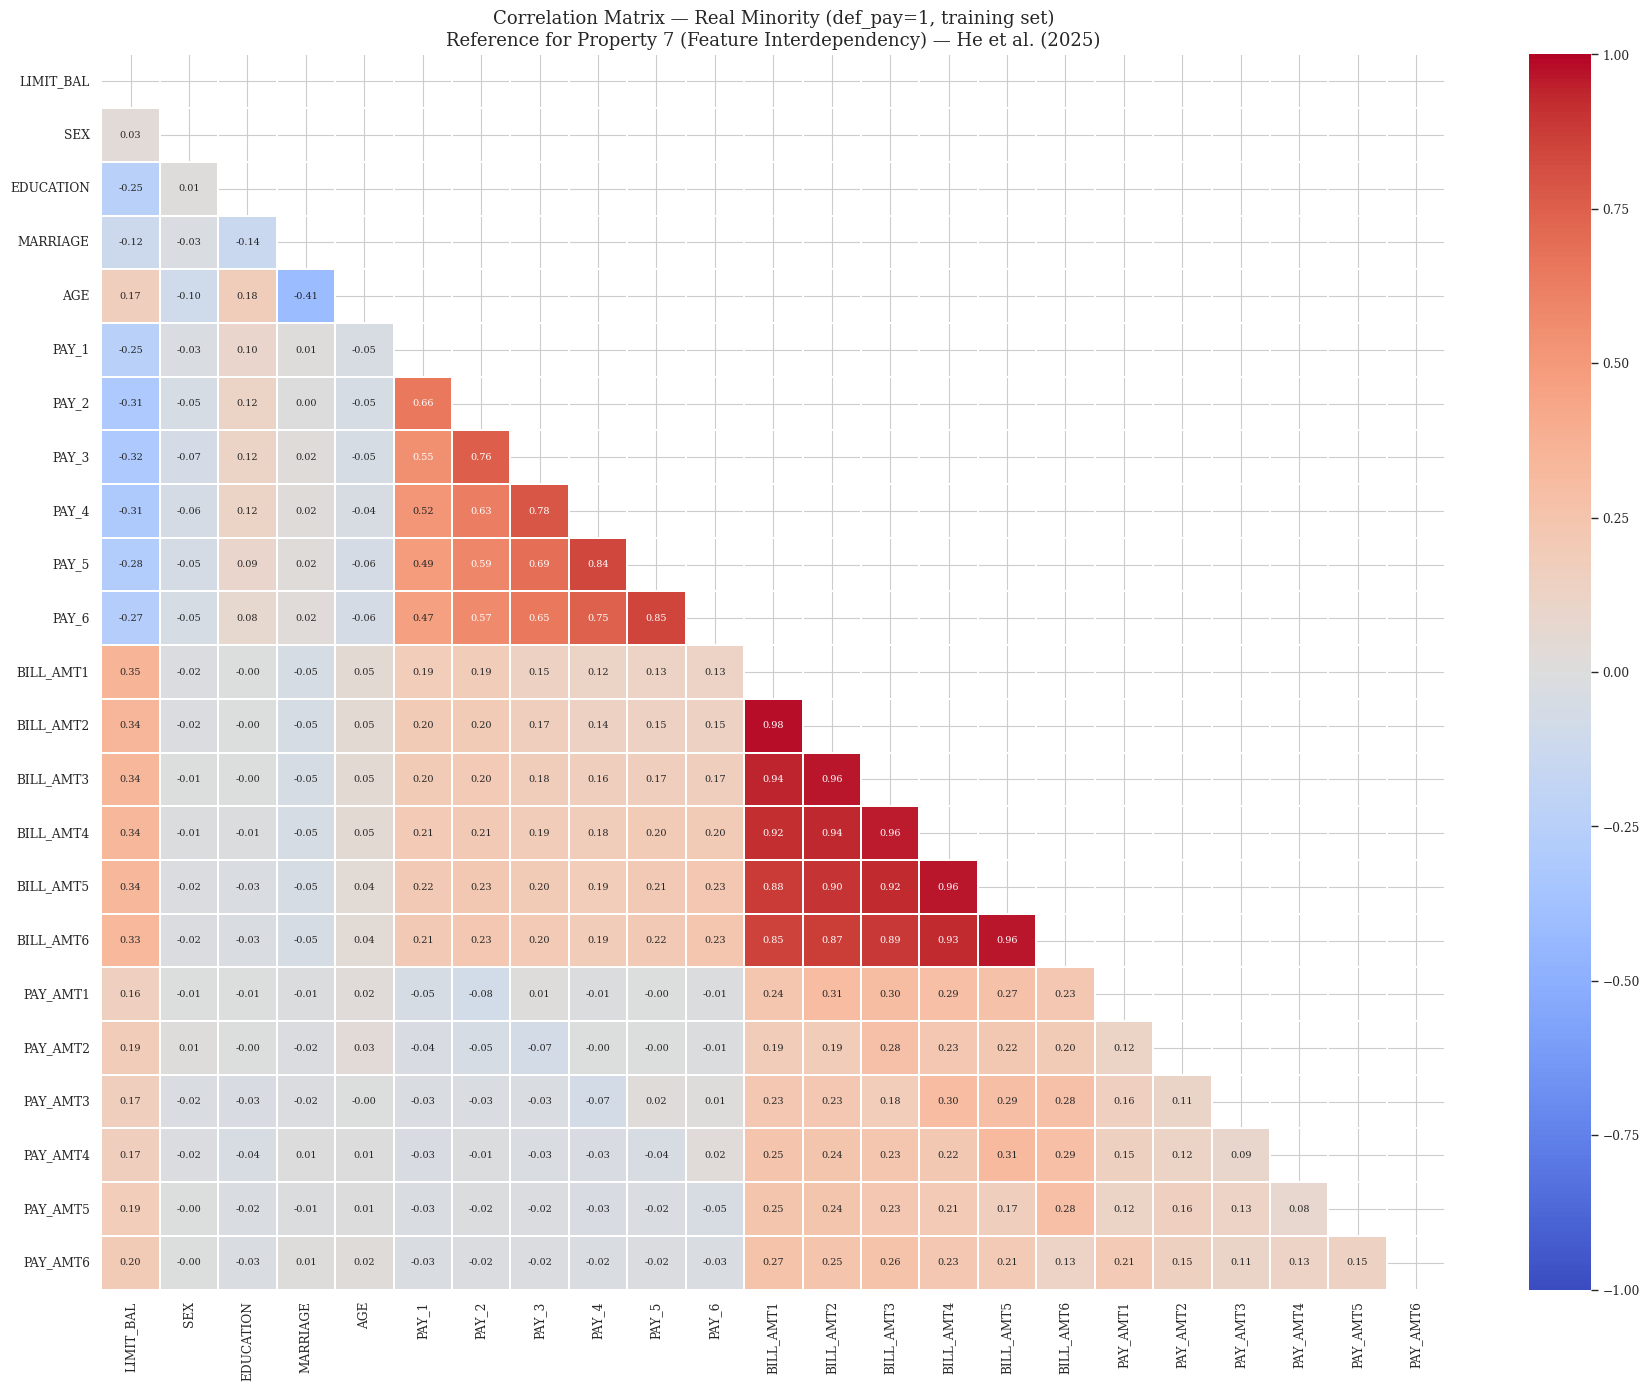


Top 10 strongest correlation pairs (real minority):
BILL_AMT1  BILL_AMT2    0.983
BILL_AMT2  BILL_AMT1    0.983
BILL_AMT5  BILL_AMT6    0.962
BILL_AMT6  BILL_AMT5    0.962
BILL_AMT3  BILL_AMT2    0.962
BILL_AMT2  BILL_AMT3    0.962
BILL_AMT4  BILL_AMT5    0.961
BILL_AMT5  BILL_AMT4    0.961
BILL_AMT3  BILL_AMT4    0.959
BILL_AMT4  BILL_AMT3    0.959
dtype: float64

→ Saved as REAL_MINORITY_CORR


In [27]:
REAL_MINORITY_CORR = train_minority_raw.corr()

fig, ax = plt.subplots(figsize=(18, 14))
mask = np.zeros_like(REAL_MINORITY_CORR, dtype=bool)
mask[np.triu_indices_from(mask)] = True

sns.heatmap(
    REAL_MINORITY_CORR,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    annot_kws={"size": 7},
    ax=ax,
    mask=mask,
    vmin=-1,
    vmax=1,
    linewidths=0.3
)

ax.set_title(
    "Correlation Matrix — Real Minority (def_pay=1, training set)\n"
    "Reference for Property 7 (Feature Interdependency) — He et al. (2025)",
    fontsize=13
)

plt.tight_layout()
plt.show()

# Highter correlations (multicolinearidade BILL_AMT)
corr_vals = REAL_MINORITY_CORR.abs().unstack()
corr_vals = corr_vals[corr_vals < 1.0].sort_values(ascending=False)

print("\nTop 10 strongest correlation pairs (real minority):")
print(corr_vals.head(10).round(3))

print("\n→ Saved as REAL_MINORITY_CORR")

In [28]:
# ==============================================================================
# CHAPTER 3.G.3: KDE reference plots (key continuous variables)
# ==============================================================================

# Original plots for a visual comparison with the synthetic data in Chapter 6.

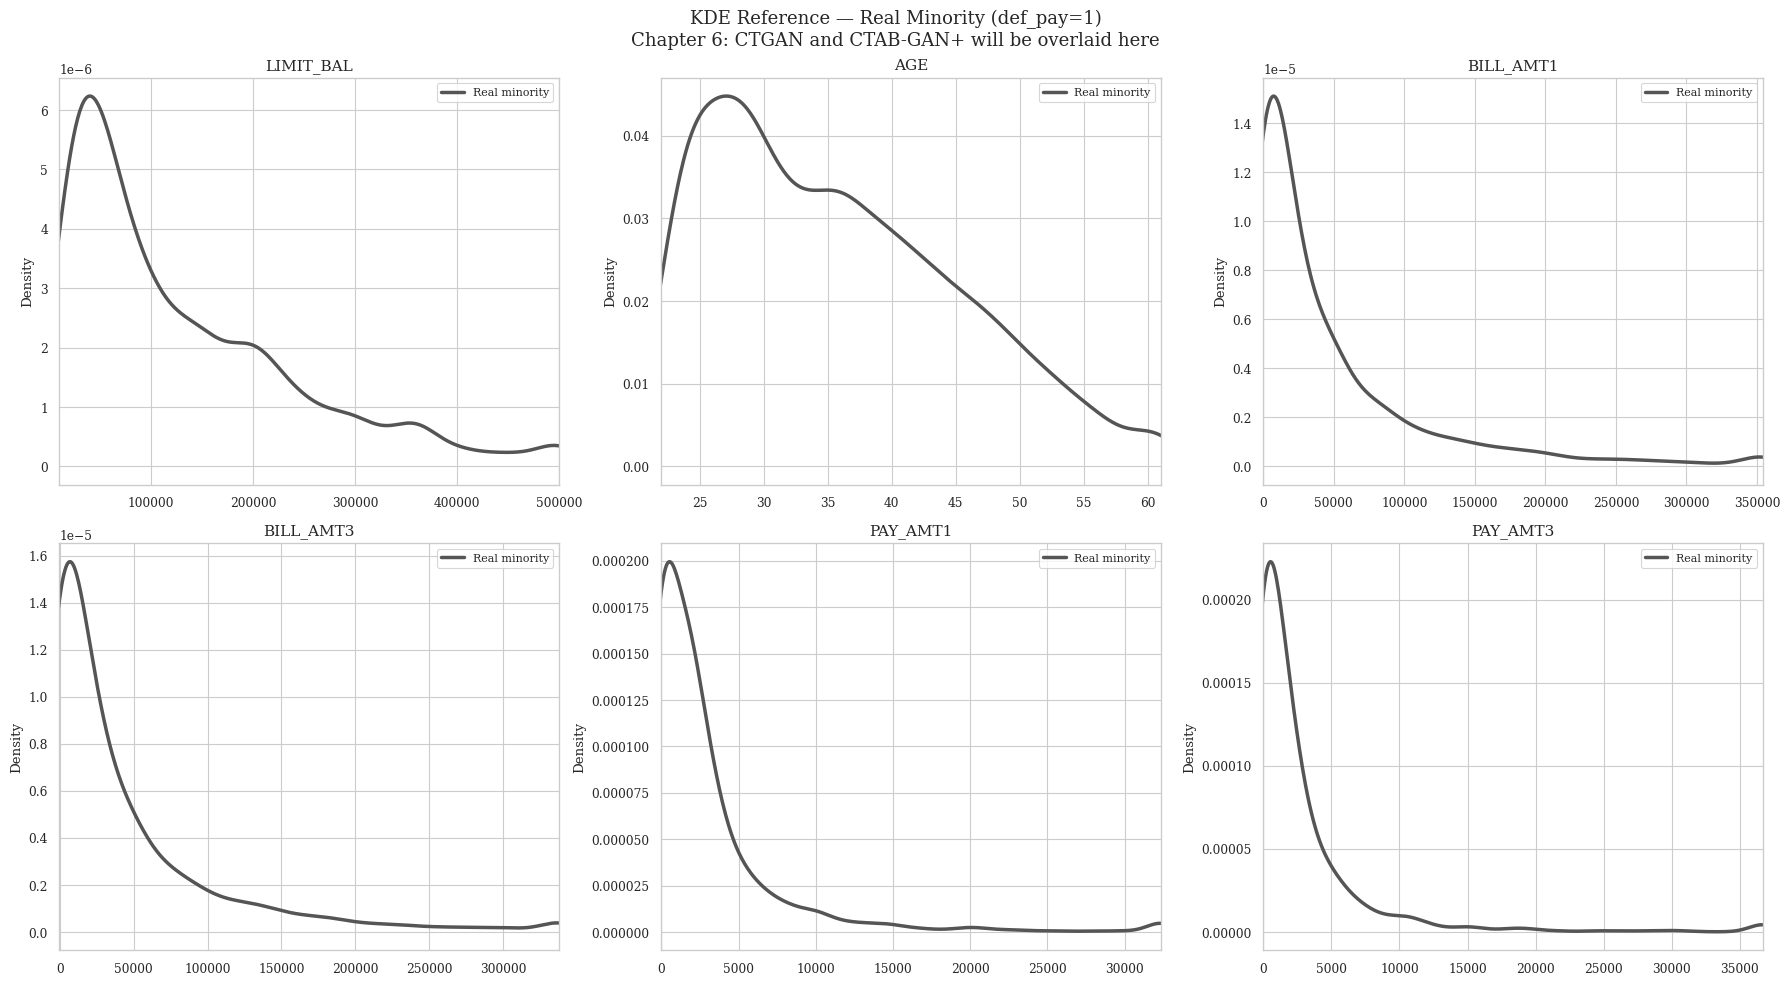

Saved figure: kde_real_minority_reference.png


In [29]:
key_continuous = [
    "LIMIT_BAL", "AGE",
    "BILL_AMT1", "BILL_AMT3",
    "PAY_AMT1",  "PAY_AMT3",
]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle(
    "KDE Reference — Real Minority (def_pay=1)\n"
    "Chapter 6: CTGAN and CTAB-GAN+ will be overlaid here",
    fontsize=13
)

for idx, col in enumerate(key_continuous):
    row, c = divmod(idx, 3)
    ax = axes[row, c]

    s = train_minority_raw[col].astype(float)
    p01, p99 = s.quantile(0.01), s.quantile(0.99)

    s.clip(p01, p99).plot.kde(
        ax=ax,
        color="#555555",
        linewidth=2.5,
        label="Real minority"
    )

    ax.set_title(col, fontsize=11)
    ax.set_ylabel("Density")
    ax.legend(fontsize=8)
    ax.set_xlim(p01, p99)

plt.tight_layout()
plt.savefig("figures/kde_real_minority_reference.png", dpi=150, bbox_inches="tight")
plt.show()

print("Saved figure: kde_real_minority_reference.png")

In [30]:
# ==============================================================================
# CHAPTER 3.G.4: Formal domain rules (He et al. Property 6 — Feasibility)
# ==============================================================================

# Explicit and formal definition of domain rules that synthetic data must respect.
# This cell serves as documentation and as the basis for post-generation validation assertions.

In [31]:
# Formal domain rules — He et al. (2025), Property 6: Feasibility 

DOMAIN_RULES = {
    # Categorical: sets of valid values
    "SEX":       {"type": "categorical", "valid_set": {1, 2}},
    "EDUCATION": {"type": "categorical", "valid_set": {1, 2, 3, 4}},
    "MARRIAGE":  {"type": "categorical", "valid_set": {1, 2, 3}},
    
    # Ordinal: range [-2, 8]
    "PAY_1": {"type": "ordinal", "min": -2, "max": 8},
    "PAY_2": {"type": "ordinal", "min": -2, "max": 8},
    "PAY_3": {"type": "ordinal", "min": -2, "max": 8},
    "PAY_4": {"type": "ordinal", "min": -2, "max": 8},
    "PAY_5": {"type": "ordinal", "min": -2, "max": 8},
    "PAY_6": {"type": "ordinal", "min": -2, "max": 8},
    
    # Numeric: physical constraints
    "AGE":      {"type": "numeric", "min": 18,  "max": 100,         "integer": True},
    "LIMIT_BAL":{"type": "numeric", "min": 1,   "max": np.inf,      "integer": False},
    "BILL_AMT1":{"type": "numeric", "min": -np.inf, "max": np.inf,  "integer": False},
    "BILL_AMT2":{"type": "numeric", "min": -np.inf, "max": np.inf,  "integer": False},
    "BILL_AMT3":{"type": "numeric", "min": -np.inf, "max": np.inf,  "integer": False},
    "BILL_AMT4":{"type": "numeric", "min": -np.inf, "max": np.inf,  "integer": False},
    "BILL_AMT5":{"type": "numeric", "min": -np.inf, "max": np.inf,  "integer": False},
    "BILL_AMT6":{"type": "numeric", "min": -np.inf, "max": np.inf,  "integer": False},
    "PAY_AMT1": {"type": "numeric", "min": 0,   "max": np.inf,      "integer": False},
    "PAY_AMT2": {"type": "numeric", "min": 0,   "max": np.inf,      "integer": False},
    "PAY_AMT3": {"type": "numeric", "min": 0,   "max": np.inf,      "integer": False},
    "PAY_AMT4": {"type": "numeric", "min": 0,   "max": np.inf,      "integer": False},
    "PAY_AMT5": {"type": "numeric", "min": 0,   "max": np.inf,      "integer": False},
    "PAY_AMT6": {"type": "numeric", "min": 0,   "max": np.inf,      "integer": False},
}

# He et al. (2025) Property 5: Immutability — features that MUST NOT vary
# in a minority-oriented data synthesis context (all clients are real,
# therefore SEX and MARRIAGE should reflect the real distribution without GAN distortion)
IMMUTABLE_FEATURES = ["SEX"]  # SEX is immutable; MARRIAGE may vary slightly

print("Formal domain rules defined (DOMAIN_RULES).")
print(f"Immutable features defined: {IMMUTABLE_FEATURES}")
print("\nSummary of rules:")
for col, rules in DOMAIN_RULES.items():
    if rules["type"] == "categorical":
        print(f"  {col:12s}: categorical  valid={rules['valid_set']}")
    elif rules["type"] == "ordinal":
        print(f"  {col:12s}: ordinal      [{rules['min']}, {rules['max']}]")
    else:
        print(f"  {col:12s}: numeric      [{rules['min']}, {rules['max']}]  integer={rules['integer']}")

Formal domain rules defined (DOMAIN_RULES).
Immutable features defined: ['SEX']

Summary of rules:
  SEX         : categorical  valid={1, 2}
  EDUCATION   : categorical  valid={1, 2, 3, 4}
  MARRIAGE    : categorical  valid={1, 2, 3}
  PAY_1       : ordinal      [-2, 8]
  PAY_2       : ordinal      [-2, 8]
  PAY_3       : ordinal      [-2, 8]
  PAY_4       : ordinal      [-2, 8]
  PAY_5       : ordinal      [-2, 8]
  PAY_6       : ordinal      [-2, 8]
  AGE         : numeric      [18, 100]  integer=True
  LIMIT_BAL   : numeric      [1, inf]  integer=False
  BILL_AMT1   : numeric      [-inf, inf]  integer=False
  BILL_AMT2   : numeric      [-inf, inf]  integer=False
  BILL_AMT3   : numeric      [-inf, inf]  integer=False
  BILL_AMT4   : numeric      [-inf, inf]  integer=False
  BILL_AMT5   : numeric      [-inf, inf]  integer=False
  BILL_AMT6   : numeric      [-inf, inf]  integer=False
  PAY_AMT1    : numeric      [0, inf]  integer=False
  PAY_AMT2    : numeric      [0, inf]  integer=Fa

In [32]:
def audit_domain_violations(synthetic_df, domain_rules, label="Synthetic"):
    """
    Audits a synthetic DataFrame against the defined domain rules.
    Returns a DataFrame with the count and rate of violations per column.
    
    Used for He et al. (2025) Property 6 — Feasibility.
    """
    results = []
    total = len(synthetic_df)
    
    for col, rules in domain_rules.items():
        if col not in synthetic_df.columns:
            continue
        
        series = synthetic_df[col].copy()
        
        if rules["type"] == "categorical":
            rounded = series.round().astype(int)
            n_viol = (~rounded.isin(rules["valid_set"])).sum()
            
        elif rules["type"] == "ordinal":
            rounded = series.round().astype(int)
            n_viol = ((rounded < rules["min"]) | (rounded > rules["max"])).sum()
            
        else:  # numeric
            vals = series.astype(float)
            n_viol = 0
            if rules["min"] != -np.inf:
                n_viol += (vals < rules["min"]).sum()
            if rules["max"] != np.inf:
                n_viol += (vals > rules["max"]).sum()
        
        results.append({
            "Column":    col,
            "Type":      rules["type"],
            "n_total":   total,
            "n_violations": int(n_viol),
            "violation_rate_%": round(n_viol / total * 100, 2),
        })
    
    result_df = pd.DataFrame(results)
    print(f"\n=== Domain Violation Audit — {label} ===")
    print(f"Total records: {total}")
    has_violations = result_df[result_df["n_violations"] > 0]
    if has_violations.empty:
        print("No violations detected.")
    else:
        print(f"WARNING: {len(has_violations)} columns with violations:")
        print(has_violations[["Column", "Type", "n_violations", "violation_rate_%"]].to_string(index=False))
    
    return result_df


def correct_domain_violations(synthetic_df, domain_rules, real_minority_df, label="Synthetic"):
    """
    Applies post-generation domain correction to the synthetic DataFrame.
    Returns the corrected DataFrame and the violation report (before correction).
    """
    df_corrected = synthetic_df.copy()
    
    # Audit BEFORE correction
    audit_before = audit_domain_violations(df_corrected, domain_rules, label=f"{label} — BEFORE")
    
    for col, rules in domain_rules.items():
        if col not in df_corrected.columns:
            continue
        
        if rules["type"] == "categorical":
            min_v = min(rules["valid_set"])
            max_v = max(rules["valid_set"])
            df_corrected[col] = df_corrected[col].round().astype(int).clip(min_v, max_v)
        
        elif rules["type"] == "ordinal":
            df_corrected[col] = df_corrected[col].round().astype(int).clip(rules["min"], rules["max"])
        
        else:  # numeric
            if rules["integer"]:
                df_corrected[col] = df_corrected[col].clip(
                    lower=rules["min"] if rules["min"] != -np.inf else None,
                    upper=rules["max"] if rules["max"] != np.inf  else None
                ).round().astype(int)
            else:
                real_min = real_minority_df[col].min() if col in real_minority_df.columns else rules["min"]
                effective_min = max(rules["min"], real_min) if rules["min"] != -np.inf else None
                df_corrected[col] = df_corrected[col].clip(
                    lower=effective_min,
                    upper=rules["max"] if rules["max"] != np.inf else None
                )
    
    # Audit AFTER correction (should show 0 violations)
    audit_after = audit_domain_violations(df_corrected, domain_rules, label=f"{label} — AFTER")
    
    return df_corrected, audit_before, audit_after


print("Audit functions defined: audit_domain_violations, correct_domain_violations")

Audit functions defined: audit_domain_violations, correct_domain_violations


In [33]:
# ==============================================================================
# CHAPTER 3.G.5: Core statistical fidelity function
# ==============================================================================

# This single function computes **all** fidelity metrics at once for a synthetic dataset. 
# It will be used in Chapter 6 for both CTGAN and CTAB-GAN+.

In [34]:
def compute_fidelity_report(real_df, synthetic_df, label="Synthetic"):
    """
    Computes a complete statistical fidelity report.
    
    Metrics:
      - TVD for categorical and ordinal columns
      - KS statistic for continuous columns
      - Wasserstein Distance for continuous columns
      - Frobenius norm between correlation matrices
    
    Returns: DataFrame with per-column results + aggregated metrics dictionary.
    """
    rows = []
    
    # TVD — categorical
    for col in CATEGORICAL_COLS:
        tvd = compute_tvd(real_df[col], synthetic_df[col].round().astype(int))
        rows.append({"Column": col, "Type": "categorical", "Metric": "TVD",
                     "Value": round(tvd, 4), "Lower_is_better": True})
    
    # TVD — ordinal
    for col in ORDINAL_COLS:
        tvd = compute_tvd(real_df[col], synthetic_df[col].round().astype(int))
        rows.append({"Column": col, "Type": "ordinal", "Metric": "TVD",
                     "Value": round(tvd, 4), "Lower_is_better": True})
    
    # KS + Wasserstein — continuous
    for col in CONTINUOUS_COLS:
        ks_stat, ks_pval = compute_ks(real_df[col].astype(float), synthetic_df[col].astype(float))
        wass = compute_wasserstein(real_df[col].astype(float), synthetic_df[col].astype(float))
        rows.append({"Column": col, "Type": "continuous", "Metric": "KS",
                     "Value": round(ks_stat, 4), "p_value": round(ks_pval, 4), "Lower_is_better": True})
        rows.append({"Column": col, "Type": "continuous", "Metric": "Wasserstein",
                     "Value": round(wass, 2), "Lower_is_better": True})
    
    result_df = pd.DataFrame(rows)
    
    # Frobenius norm of correlations
    real_corr   = real_df[CONTINUOUS_COLS].astype(float).corr().values
    synth_corr  = synthetic_df[CONTINUOUS_COLS].astype(float).corr().values
    frob_norm   = np.linalg.norm(real_corr - synth_corr, "fro")
    
    # Proximity: average nearest-neighbor distance (Property 1 — He et al.)
    from sklearn.neighbors import NearestNeighbors
    real_scaled   = StandardScaler().fit_transform(real_df[CONTINUOUS_COLS].astype(float))
    synth_scaled  = StandardScaler().fit_transform(synthetic_df[CONTINUOUS_COLS].astype(float))
    nbrs = NearestNeighbors(n_neighbors=1, algorithm="auto").fit(real_scaled)
    distances, _  = nbrs.kneighbors(synth_scaled)
    mean_proximity = distances.mean()
    
    # OOD rate (Sparsity proxy — Property 2): % of samples outside real P5–P95 range
    ood_count = 0
    for col in CONTINUOUS_COLS:
        p05 = real_df[col].quantile(0.05)
        p95 = real_df[col].quantile(0.95)
        ood_count += ((synthetic_df[col] < p05) | (synthetic_df[col] > p95)).sum()
    ood_rate = ood_count / (len(synthetic_df) * len(CONTINUOUS_COLS))
    
    # Z-score sensitivity (Property 4): % of samples with >3 features having |z|>2
    mean_real = real_df[CONTINUOUS_COLS].astype(float).mean()
    std_real  = real_df[CONTINUOUS_COLS].astype(float).std()
    z_scores  = ((synthetic_df[CONTINUOUS_COLS].astype(float) - mean_real) / (std_real + 1e-8)).abs()
    high_sens_rate = ((z_scores > 2).sum(axis=1) > 3).mean()
    
    summary = {
        "label":            label,
        "mean_TVD_cat":     result_df[(result_df["Type"]=="categorical") & (result_df["Metric"]=="TVD")]["Value"].mean(),
        "mean_TVD_ord":     result_df[(result_df["Type"]=="ordinal")     & (result_df["Metric"]=="TVD")]["Value"].mean(),
        "mean_KS_cont":     result_df[(result_df["Type"]=="continuous")  & (result_df["Metric"]=="KS")]["Value"].mean(),
        "mean_Wass_cont":   result_df[(result_df["Type"]=="continuous")  & (result_df["Metric"]=="Wasserstein")]["Value"].mean(),
        "frobenius_delta":  round(frob_norm, 4),
        "mean_proximity":   round(mean_proximity, 4),
        "ood_rate":         round(ood_rate, 4),
        "high_sensitivity_rate": round(high_sens_rate, 4),
    }
    
    print(f"\n=== Fidelity Report — {label} ===")
    for k, v in summary.items():
        if k != "label":
            print(f"  {k:30s}: {v}")
    
    return result_df, summary


print("Function compute_fidelity_report defined and ready for use in Chapter 6.")

Function compute_fidelity_report defined and ready for use in Chapter 6.


In [35]:
# ==============================================================================
# CHAPTER 3.G.6: Save all reference artifacts as CSV
# ==============================================================================

# These files represent the "saved state" of the real data. In Chapter 6, they are simply loaded and compared against.

In [36]:
# Save base datasets
train_minority_raw.to_csv("data/real_minority_train.csv", index=False)
train_data_full.to_csv("data/real_train_full.csv", index=False)

# Save reference metrics
REAL_CONTINUOUS_STATS.to_csv("data/real_continuous_stats.csv")
REAL_MINORITY_CORR.to_csv("data/real_minority_correlation.csv")

# Save TVD reference
pd.DataFrame.from_dict(REAL_TVD_REFERENCE, orient="index",
                       columns=["TVD_minority_vs_majority"]).to_csv("data/real_tvd_reference.csv")

# Save default rates per segment
for feat, df_dr in REAL_DEFAULT_RATES.items():
    df_dr.to_csv(f"data/real_default_rate_{feat}.csv")

print("Reference artifacts saved:")
print("  real_minority_train.csv         — minority training set (comparison baseline)")
print("  real_train_full.csv             — full training set (for CTAB-GAN+)")
print("  real_continuous_stats.csv       — continuous reference statistics")
print("  real_minority_correlation.csv   — correlation matrix (Property 7)")
print("  real_tvd_reference.csv          — TVD minority vs majority")
print("  real_default_rate_*.csv         — default rates by segment")

Reference artifacts saved:
  real_minority_train.csv         — minority training set (comparison baseline)
  real_train_full.csv             — full training set (for CTAB-GAN+)
  real_continuous_stats.csv       — continuous reference statistics
  real_minority_correlation.csv   — correlation matrix (Property 7)
  real_tvd_reference.csv          — TVD minority vs majority
  real_default_rate_*.csv         — default rates by segment


In [37]:
# ==============================================================================
# CHAPTER 4: BASELINE PREDICTIVE MODELING (IMBALANCED DATA)
# ==============================================================================
#
# Objective: Establish baseline performance on the raw imbalanced dataset.
# Models: Logistic Regression (linear) and Random Forest (non-linear ensemble).
#
# Key decision: class_weight='balanced' is NOT used here. The goal is to
# capture the raw degradation on the minority class that motivates the
# data augmentation strategies in Chapter 5.
#
# Primary metric: Macro F1-Score and Class-1 Recall.
# Accuracy is explicitly avoided as a primary metric because in imbalanced
# settings a naive classifier predicting only the majority class achieves
# ~78% accuracy (Alfaiz & Fati, 2022; Arora et al., 2022).
# ==============================================================================


evaluate_model defined (full version with y_prob and average_precision).
Training Logistic Regression (Baseline)...
Training Random Forest (Baseline)...
Logistic Regression — Baseline — CLASSIFICATION REPORT
              precision    recall  f1-score   support

  No Default       0.82      0.98      0.89      7009
     Default       0.72      0.23      0.35      1991

    accuracy                           0.81      9000
   macro avg       0.77      0.60      0.62      9000
weighted avg       0.80      0.81      0.77      9000

  ROC-AUC:            0.7298
  Avg Precision (PR): 0.5137
  Macro F1:           0.6180
  Minority Recall:    0.2285
  Minority Precision: 0.7222
  Minority F1:        0.3472


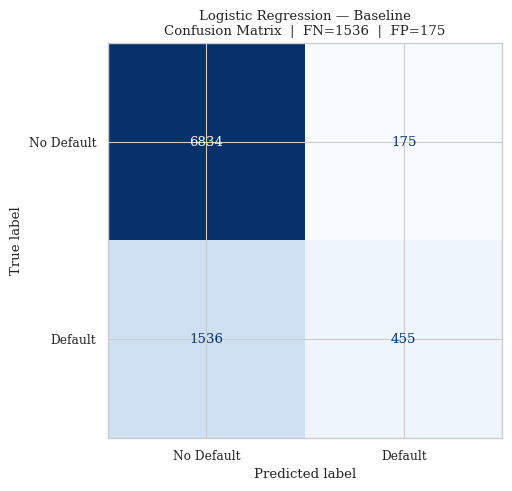

Random Forest — Baseline — CLASSIFICATION REPORT
              precision    recall  f1-score   support

  No Default       0.84      0.95      0.89      7009
     Default       0.66      0.36      0.47      1991

    accuracy                           0.82      9000
   macro avg       0.75      0.66      0.68      9000
weighted avg       0.80      0.82      0.80      9000

  ROC-AUC:            0.7611
  Avg Precision (PR): 0.5377
  Macro F1:           0.6792
  Minority Recall:    0.3636
  Minority Precision: 0.6588
  Minority F1:        0.4686


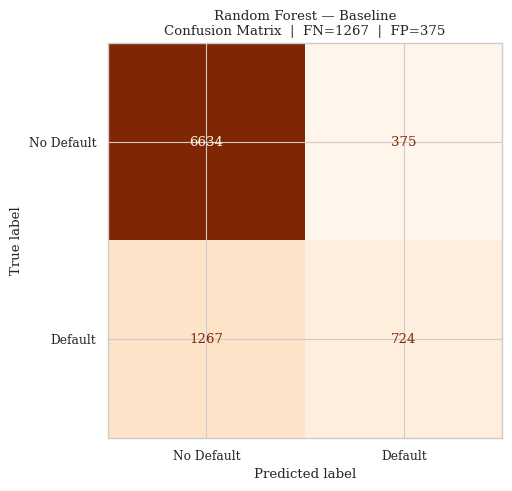

In [38]:
def evaluate_model(model, X_test_s, y_test, model_name, cmap="Blues"):
    """
    Evaluate a trained classifier and return a full metrics dictionary.

    Returns
    -------
    dict with keys:
        model_name, report, auc, avg_precision, macro_f1,
        minority_recall, minority_precision, minority_f1,
        accuracy, y_prob, y_pred
    """
    y_pred = model.predict(X_test_s)
    y_prob = model.predict_proba(X_test_s)[:, 1]

    report = classification_report(
        y_test, y_pred,
        target_names=["No Default", "Default"],
        output_dict=True
    )

    auc          = roc_auc_score(y_test, y_prob)
    avg_prec     = average_precision_score(y_test, y_prob)  
    macro_f1     = report["macro avg"]["f1-score"]
    min_recall   = report["Default"]["recall"]
    min_prec     = report["Default"]["precision"]
    min_f1       = report["Default"]["f1-score"]
    accuracy     = report["accuracy"]

    print("=" * 60)
    print(f"{model_name} — CLASSIFICATION REPORT")
    print("=" * 60)
    print(classification_report(y_test, y_pred, target_names=["No Default", "Default"]))
    print(f"  ROC-AUC:            {auc:.4f}")
    print(f"  Avg Precision (PR): {avg_prec:.4f}")
    print(f"  Macro F1:           {macro_f1:.4f}")
    print(f"  Minority Recall:    {min_recall:.4f}")
    print(f"  Minority Precision: {min_prec:.4f}")
    print(f"  Minority F1:        {min_f1:.4f}")

    cm = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = cm.ravel()
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No Default", "Default"])
    fig, ax = plt.subplots(figsize=(6, 5))
    disp.plot(ax=ax, cmap=cmap, colorbar=False)
    ax.set_title(f"{model_name}\nConfusion Matrix  |  FN={fn}  |  FP={fp}")
    plt.tight_layout()
    plt.show()

    return {
        "model_name":       model_name,
        "report":           report,
        "auc":              auc,
        "avg_precision":    avg_prec,   
        "macro_f1":         macro_f1,
        "minority_recall":  min_recall,
        "minority_prec":    min_prec,
        "minority_f1":      min_f1,
        "accuracy":         accuracy,
        "y_prob":           y_prob,      
        "y_pred":           y_pred,      
    }

print("evaluate_model defined (full version with y_prob and average_precision).")

# Train baseline models
print("Training Logistic Regression (Baseline)...")
log_reg = LogisticRegression(random_state=RANDOM_STATE, max_iter=1000)
log_reg.fit(X_train_scaled, y_train)
 
print("Training Random Forest (Baseline)...")
rf_clf = RandomForestClassifier(random_state=RANDOM_STATE, n_estimators=100)
rf_clf.fit(X_train_scaled, y_train)
 
# Evaluate
results_lr_base = evaluate_model(
    log_reg, X_test_scaled, y_test,
    "Logistic Regression — Baseline", "Blues"
)

results_rf_base = evaluate_model(
    rf_clf, X_test_scaled, y_test,
    "Random Forest — Baseline", "Oranges"
)

In [39]:
# ==============================================================================
# CHAPTER 5: DATA AUGMENTATION AND GENERATIVE MODELLING
# ==============================================================================

--- Before SMOTE ---
def_pay
0    16355
1     4645
Name: count, dtype: int64

--- After SMOTE ---
def_pay
0    16355
1    16355
Name: count, dtype: int64
New training set shape: (32710, 23)

Training Logistic Regression (SMOTE)...
Training Random Forest (SMOTE)...
Logistic Regression — SMOTE — CLASSIFICATION REPORT
              precision    recall  f1-score   support

  No Default       0.88      0.68      0.77      7009
     Default       0.37      0.67      0.48      1991

    accuracy                           0.68      9000
   macro avg       0.63      0.68      0.62      9000
weighted avg       0.77      0.68      0.70      9000

  ROC-AUC:            0.7316
  Avg Precision (PR): 0.5105
  Macro F1:           0.6232
  Minority Recall:    0.6695
  Minority Precision: 0.3732
  Minority F1:        0.4792


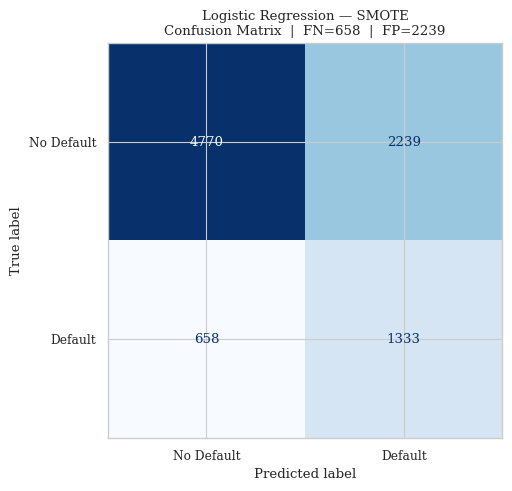

Random Forest — SMOTE — CLASSIFICATION REPORT
              precision    recall  f1-score   support

  No Default       0.86      0.88      0.87      7009
     Default       0.54      0.48      0.51      1991

    accuracy                           0.79      9000
   macro avg       0.70      0.68      0.69      9000
weighted avg       0.79      0.79      0.79      9000

  ROC-AUC:            0.7567
  Avg Precision (PR): 0.5215
  Macro F1:           0.6891
  Minority Recall:    0.4787
  Minority Precision: 0.5409
  Minority F1:        0.5079


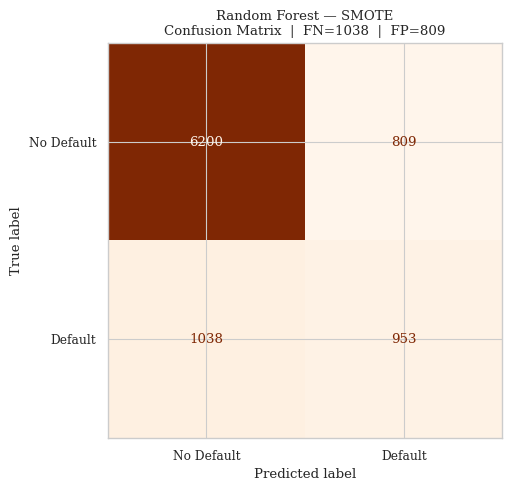

In [40]:
# ------------------------------------------------------------------------------
# 5.1 — SMOTE (Geometric Oversampling Baseline)
# ------------------------------------------------------------------------------
#
# SMOTE (Chawla et al., 2002) is applied ONLY to the training data.
# The test set remains completely unmodified to ensure evaluation against
# the true, imbalanced real-world distribution (the TSTR paradigm).
#
# Reference: Hollig et al. (2025) demonstrate that SMOTE achieves competitive
# utility-privacy scores precisely because its interpolation does not
# memorise individual training records, making it an important baseline.
# ------------------------------------------------------------------------------
 
smote = SMOTE(random_state=RANDOM_STATE)
X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)
 
print("--- Before SMOTE ---")
print(y_train.value_counts())
print(f"\n--- After SMOTE ---")
print(pd.Series(y_train_smote).value_counts())
print(f"New training set shape: {X_train_smote.shape}")
 
log_reg_smote = LogisticRegression(random_state=RANDOM_STATE, max_iter=1000)
rf_clf_smote = RandomForestClassifier(random_state=RANDOM_STATE, n_estimators=100)
 
print("\nTraining Logistic Regression (SMOTE)...")
log_reg_smote.fit(X_train_smote, y_train_smote)
print("Training Random Forest (SMOTE)...")
rf_clf_smote.fit(X_train_smote, y_train_smote)
 
results_lr_smote = evaluate_model(
    log_reg_smote, X_test_scaled, y_test,
    "Logistic Regression — SMOTE", "Blues"
)

results_rf_smote = evaluate_model(
    rf_clf_smote, X_test_scaled, y_test,
    "Random Forest — SMOTE", "Oranges"
)


In [41]:
# ------------------------------------------------------------------------------
# 5.2 — CTGAN (Conditional Tabular GAN) - TRAINING & GENERATION
# ------------------------------------------------------------------------------
#
# CTGAN (Xu et al., 2019) is the current benchmark for tabular data synthesis.
# Its Mode-Specific Normalisation (MSN) via a Variational Gaussian Mixture
# (VGM) model handles the multimodal continuous distributions present in
# financial data (e.g., BILL_AMT long tails).
#
# Training strategy: the model is trained ONLY on the minority class
# (def_pay == 1) from the RAW (unscaled) training data.
#
# WHY RAW DATA: CTGAN's internal MSN pipeline normalises continuous variables
# and one-hot encodes categoricals internally. Pre-scaling with StandardScaler
# destroys the integer nature of categorical columns like EDUCATION and
# MARRIAGE, causing the model to treat them as continuous (Xu et al., 2019).
#
# WHY MINORITY CLASS ONLY: We need to synthesise additional defaulters to
# reach a 50/50 balance. Training on the full dataset and filtering outputs
# wastes training capacity and may dilute generator focus on the rare class.
# ------------------------------------------------------------------------------

# ------------------------------------------------------------------------------
# CTGAN import: sets CTGAN_AVAILABLE
# ------------------------------------------------------------------------------
try:
    from ctgan import CTGAN
    CTGAN_AVAILABLE = True
    print("CTGAN imported successfully.")
except ImportError as e:
    print(f"ERROR: Could not import CTGAN: {e}")
    print("Skipping CTGAN section...")
    CTGAN_AVAILABLE = False


if CTGAN_AVAILABLE:

    # train_minority_raw and train_data_raw were defined in Section 3.G
    # No need to redefine them here — use them directly.
    # Verify that they exist:
    assert "train_minority_raw" in globals(), "train_minority_raw not found — did you run Section 3.G?"
    print(f"train_minority_raw available: {train_minority_raw.shape}")

    # Discrete columns inform CTGAN which variables to treat as categorical
    discrete_columns = [
        "SEX", "EDUCATION", "MARRIAGE",
        "PAY_1", "PAY_2", "PAY_3", "PAY_4", "PAY_5", "PAY_6",
        "def_pay",
    ]

    # NOTE: train_minority_raw does not include the def_pay column
    # To train CTGAN, we need to add def_pay = 1
    train_minority_for_ctgan = train_minority_raw.copy()
    train_minority_for_ctgan["def_pay"] = 1

    # Set reproducibility seeds
    np.random.seed(RANDOM_STATE)
    try:
        import torch
        torch.manual_seed(RANDOM_STATE)
        print("PyTorch seed set for reproducibility.")
    except ImportError:
        print("PyTorch not found — skipping torch seed.")

    # Initialize CTGAN
    ctgan_model = CTGAN(epochs=300, batch_size=500, verbose=True)

    print("\nTraining CTGAN on the minority class (raw, unscaled data)...")
    start_time = time.time()
    ctgan_model.fit(train_minority_for_ctgan, discrete_columns)
    elapsed = (time.time() - start_time) / 60
    print(f"CTGAN training completed in {elapsed:.2f} minutes.")

    # Calculate the exact number of synthetic samples needed for 50/50 balance
    num_majority = (y_train == 0).sum()
    num_minority  = (y_train == 1).sum()
    samples_to_generate_ctgan = num_majority - num_minority
    print(f"\nGenerating {samples_to_generate_ctgan} synthetic minority instances...")

    synthetic_ctgan = ctgan_model.sample(samples_to_generate_ctgan)
    print(f"Synthetic data shape: {synthetic_ctgan.shape}")

else:
    synthetic_ctgan = None
    print("\nCTGAN section skipped due to missing import.")

CTGAN imported successfully.
train_minority_raw available: (4645, 23)
PyTorch seed set for reproducibility.

Training CTGAN on the minority class (raw, unscaled data)...


Gen. (-00.20) | Discrim. (-00.10): 100%|██████████| 300/300 [01:43<00:00,  2.91it/s]


CTGAN training completed in 2.00 minutes.

Generating 11710 synthetic minority instances...
Synthetic data shape: (11710, 24)


In [42]:
# Optional cell: inspect the raw CTGAN output
print("Raw synthetic data (before correction):")
print(synthetic_ctgan.head())
print("\nColumn data types:")
print(synthetic_ctgan.dtypes)

Raw synthetic data (before correction):
       LIMIT_BAL  SEX  EDUCATION  MARRIAGE  AGE  PAY_1  PAY_2  PAY_3  PAY_4  \
0  108763.670391    2          1         1   42      2      2      0      2   
1   58737.780312    2          2         1   49      2      0      2      0   
2  174631.866700    1          2         2   24      3      2      2      2   
3   60754.368255    2          1         2   33      0      2      2      3   
4  166429.586326    2          1         2   40     -1     -1     -2     -2   

   PAY_5  ...      BILL_AMT4      BILL_AMT5      BILL_AMT6      PAY_AMT1  \
0      0  ...   42809.464077  216728.334097   99860.013358   3138.008443   
1      0  ...   21362.806382   10754.172151   34094.544321   2876.674170   
2      3  ...  155560.430729   38870.959386   71470.784488   -295.341282   
3      2  ...   98122.682730   42709.254316  248307.473639  21526.244941   
4     -1  ...   -7502.834592     282.711858   -2083.647910    564.219727   

      PAY_AMT2     PAY_AMT3 


--- CTGAN Post-Generation Validation & Domain Correction ---

[DIAGNOSTIC] Out-of-domain values BEFORE correction:
  AGE  outside [18, 100]: 0 records (0.00%)
  LIMIT_BAL <= 0        : 353 records (3.01%)
  PAY_AMT1 < 0: 1499 records (12.80%)
  PAY_AMT2 < 0: 1103 records (9.42%)
  PAY_AMT3 < 0: 4823 records (41.19%)
  PAY_AMT4 < 0: 5018 records (42.85%)
  PAY_AMT5 < 0: 3292 records (28.11%)
  PAY_AMT6 < 0: 4733 records (40.42%)

  LIMIT_BAL clipped to minimum of 10000 (real minority minimum).

[ASSERTIONS] Verifying domain compliance after correction:
  All assertions passed — synthetic data is domain-compliant.

CTGAN Synthetic Minority — Descriptive Statistics (post-correction):
       LIMIT_BAL_Real  LIMIT_BAL_Synth  AGE_Real  AGE_Synth  BILL_AMT1_Real  \
count         4645.00         11710.00   4645.00   11710.00         4645.00   
mean        130877.86         96310.82     35.62      36.52        48651.71   
std         115896.59         84392.15      9.71      10.57        73432

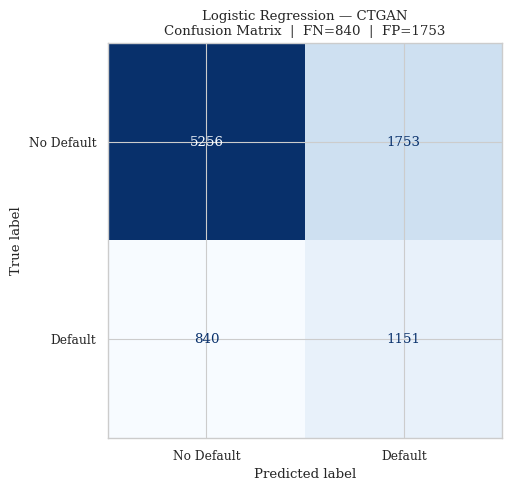

Random Forest — CTGAN — CLASSIFICATION REPORT
              precision    recall  f1-score   support

  No Default       0.85      0.91      0.88      7009
     Default       0.59      0.43      0.50      1991

    accuracy                           0.81      9000
   macro avg       0.72      0.67      0.69      9000
weighted avg       0.79      0.81      0.80      9000

  ROC-AUC:            0.7594
  Avg Precision (PR): 0.5244
  Macro F1:           0.6907
  Minority Recall:    0.4335
  Minority Precision: 0.5907
  Minority F1:        0.5000


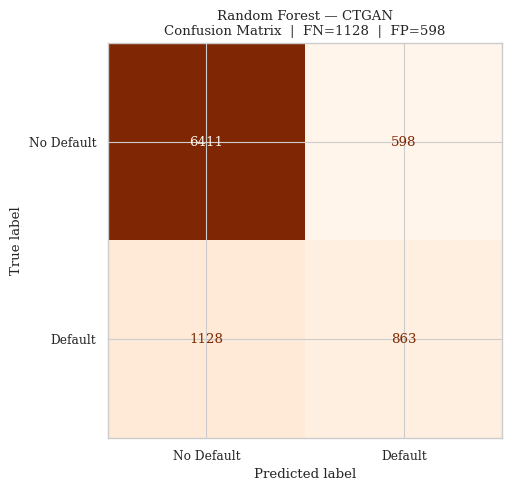


EXPERIMENTAL PIPELINE COMPLETED SUCCESSFULLY

Summary of available results:
  - Baseline (LR): AUC=0.7298, Macro F1=0.6180
  - Baseline (RF): AUC=0.7611, Macro F1=0.6792
  - SMOTE (LR):    AUC=0.7316, Macro F1=0.6232
  - SMOTE (RF):    AUC=0.7567, Macro F1=0.6891
  - CTGAN (LR):    AUC=0.7218, Macro F1=0.6362
  - CTGAN (RF):    AUC=0.7594, Macro F1=0.6907


In [43]:
# POST-GENERATION SEMANTIC VALIDATION + DOMAIN CORRECTION — CTGAN
#
# CTGAN uses VGM-based Gaussian mixture normalisation for continuous
# columns. Because the generator maps Gaussian latent noise through
# a sigmoid/tanh activation, it can produce out-of-domain values for
# strictly positive columns — a known architectural limitation
# documented in the CTGAN GitHub issue tracker (sdv-dev/CTGAN #94)
# and consistent with the 'logical hallucination' phenomenon described
# by He et al. (2025) and Kapar et al. (2026).
#
# Methodological decision: domain-guided post-processing (clipping)
# is applied before use, following the approach adopted in the
# synthetic tabular data literature (Zhao et al., 2021; 2023).
# ------------------------------------------------------------------------------

if CTGAN_AVAILABLE and synthetic_ctgan is not None:
    
    print("\n--- CTGAN Post-Generation Validation & Domain Correction ---")

    # ── 0. Diagnostic: quantify violations BEFORE any correction ──────
    print("\n[DIAGNOSTIC] Out-of-domain values BEFORE correction:")

    # AGE
    age_violations = ((synthetic_ctgan["AGE"] < 18) | (synthetic_ctgan["AGE"] > 100)).sum()
    print(f"  AGE  outside [18, 100]: {age_violations} records ({age_violations/len(synthetic_ctgan)*100:.2f}%)")

    # LIMIT_BAL
    lb_violations = (synthetic_ctgan["LIMIT_BAL"] <= 0).sum()
    print(f"  LIMIT_BAL <= 0        : {lb_violations} records ({lb_violations/len(synthetic_ctgan)*100:.2f}%)")

    # PAY_AMT negative values
    pay_amt_cols = ["PAY_AMT1", "PAY_AMT2", "PAY_AMT3", "PAY_AMT4", "PAY_AMT5", "PAY_AMT6"]
    for col in pay_amt_cols:
        neg = (synthetic_ctgan[col] < 0).sum()
        if neg > 0:
            print(f"  {col} < 0: {neg} records ({neg/len(synthetic_ctgan)*100:.2f}%)")

    # PAY_X ordinal range
    valid_pay_range = set(range(-2, 9))
    for col in ["PAY_1", "PAY_2", "PAY_3", "PAY_4", "PAY_5", "PAY_6"]:
        invalid_vals = set(synthetic_ctgan[col].round().astype(int).unique()) - valid_pay_range
        if invalid_vals:
            n_invalid = synthetic_ctgan[col].apply(
                lambda v: int(round(v)) not in valid_pay_range
            ).sum()
            print(f"  {col} out of [-2,8]: {n_invalid} records — values: {invalid_vals}")

    # ── 1. Categorical correction (rounding + clipping to valid sets) ──
    valid_sex = {1, 2}
    valid_edu = {1, 2, 3, 4}
    valid_mar = {1, 2, 3}

    def clip_categorical(series, valid_set):
        """Clip out-of-range categorical values to the nearest valid value."""
        min_val = min(valid_set)
        max_val = max(valid_set)
        return series.round().astype(int).clip(min_val, max_val)

    synthetic_ctgan["SEX"]       = clip_categorical(synthetic_ctgan["SEX"],       valid_sex)
    synthetic_ctgan["EDUCATION"] = clip_categorical(synthetic_ctgan["EDUCATION"],  valid_edu)
    synthetic_ctgan["MARRIAGE"]  = clip_categorical(synthetic_ctgan["MARRIAGE"],   valid_mar)

    # PAY_X ordinal correction
    for col in ["PAY_1", "PAY_2", "PAY_3", "PAY_4", "PAY_5", "PAY_6"]:
        synthetic_ctgan[col] = synthetic_ctgan[col].round().astype(int).clip(-2, 8)

    # ── 2. Numerical domain correction ────────────────────────────────
    synthetic_ctgan["AGE"] = synthetic_ctgan["AGE"].clip(18, 100).round().astype(int)

    real_lb_min = train_minority_raw["LIMIT_BAL"].min()
    synthetic_ctgan["LIMIT_BAL"] = synthetic_ctgan["LIMIT_BAL"].clip(lower=real_lb_min)
    print(f"\n  LIMIT_BAL clipped to minimum of {real_lb_min:.0f} (real minority minimum).")

    for col in pay_amt_cols:
        synthetic_ctgan[col] = synthetic_ctgan[col].clip(lower=0)

    # ── 3. Post-correction assertion checks ───────────────────────────
    print("\n[ASSERTIONS] Verifying domain compliance after correction:")

    assert set(synthetic_ctgan["SEX"].unique()).issubset(valid_sex), "SEX invalid"
    assert set(synthetic_ctgan["EDUCATION"].unique()).issubset(valid_edu), "EDUCATION invalid"
    assert set(synthetic_ctgan["MARRIAGE"].unique()).issubset(valid_mar), "MARRIAGE invalid"
    assert (synthetic_ctgan["AGE"] >= 18).all() and (synthetic_ctgan["AGE"] <= 100).all(), "AGE invalid"
    assert (synthetic_ctgan["LIMIT_BAL"] > 0).all(), "LIMIT_BAL invalid"
    for col in pay_amt_cols:
        assert (synthetic_ctgan[col] >= 0).all(), f"{col} invalid"
    for col in ["PAY_1", "PAY_2", "PAY_3", "PAY_4", "PAY_5", "PAY_6"]:
        assert set(synthetic_ctgan[col].unique()).issubset(valid_pay_range), f"{col} invalid"

    print("  All assertions passed — synthetic data is domain-compliant.")

    # ── 4. Distribution sanity check ──────────────────────────────────
    print("\nCTGAN Synthetic Minority — Descriptive Statistics (post-correction):")
    num_cols_check = ["LIMIT_BAL", "AGE", "BILL_AMT1", "PAY_AMT1"]
    comparison = pd.concat([
        train_minority_raw[num_cols_check].describe().add_suffix("_Real"),
        synthetic_ctgan[num_cols_check].describe().add_suffix("_Synth"),
    ], axis=1)
    ordered_cols = [f"{c}{s}" for c in num_cols_check for s in ["_Real", "_Synth"]]
    print(comparison[ordered_cols].round(2))

    print("\nCTGAN Synthetic — Categorical distributions (post-correction):")
    for col in ["SEX", "EDUCATION", "MARRIAGE"]:
        real_dist  = train_minority_raw[col].value_counts(normalize=True).sort_index().round(3).to_dict()
        synth_dist = synthetic_ctgan[col].value_counts(normalize=True).sort_index().round(3).to_dict()
        print(f"\n  {col}:")
        print(f"    Real:      {real_dist}")
        print(f"    Synthetic: {synth_dist}")

    # ── 5. Build balanced training set ────────────────────────────────
    balanced_ctgan = pd.concat([train_data_raw, synthetic_ctgan], ignore_index=True)

    X_train_ctgan_raw = balanced_ctgan.drop("def_pay", axis=1)
    y_train_ctgan     = balanced_ctgan["def_pay"]

    print("\nCTGAN class distribution (balanced training set):")
    print(y_train_ctgan.value_counts())

    # Scale using the CANONICAL scaler — transform only, NEVER re-fit
    X_train_ctgan_scaled = scaler.transform(X_train_ctgan_raw)

    # ── 6. Train classifiers ──────────────────────────────────────────
    log_reg_ctgan = LogisticRegression(random_state=RANDOM_STATE, max_iter=1000)
    rf_clf_ctgan  = RandomForestClassifier(random_state=RANDOM_STATE, n_estimators=100)

    print("\nTraining Logistic Regression (CTGAN)...")
    log_reg_ctgan.fit(X_train_ctgan_scaled, y_train_ctgan)
    print("Training Random Forest (CTGAN)...")
    rf_clf_ctgan.fit(X_train_ctgan_scaled, y_train_ctgan)

    # Evaluate on the UNTOUCHED original test set
    results_lr_ctgan = evaluate_model(
        log_reg_ctgan, X_test_scaled, y_test,
        "Logistic Regression — CTGAN", "Blues"
    )

    results_rf_ctgan = evaluate_model(
        rf_clf_ctgan, X_test_scaled, y_test,
        "Random Forest — CTGAN", "Oranges"
    )
    
else:
    print("\nCTGAN section skipped — model not available.")
    results_lr_ctgan = None
    results_rf_ctgan = None

# ==============================================================================
# FINAL SUMMARY
# ==============================================================================

print("\n" + "=" * 70)
print("EXPERIMENTAL PIPELINE COMPLETED SUCCESSFULLY")
print("=" * 70)
print("\nSummary of available results:")
print(f"  - Baseline (LR): AUC={results_lr_base['auc']:.4f}, Macro F1={results_lr_base['macro_f1']:.4f}")
print(f"  - Baseline (RF): AUC={results_rf_base['auc']:.4f}, Macro F1={results_rf_base['macro_f1']:.4f}")
print(f"  - SMOTE (LR):    AUC={results_lr_smote['auc']:.4f}, Macro F1={results_lr_smote['macro_f1']:.4f}")
print(f"  - SMOTE (RF):    AUC={results_rf_smote['auc']:.4f}, Macro F1={results_rf_smote['macro_f1']:.4f}")

if CTGAN_AVAILABLE and results_lr_ctgan is not None:
    print(f"  - CTGAN (LR):    AUC={results_lr_ctgan['auc']:.4f}, Macro F1={results_lr_ctgan['macro_f1']:.4f}")
    print(f"  - CTGAN (RF):    AUC={results_rf_ctgan['auc']:.4f}, Macro F1={results_rf_ctgan['macro_f1']:.4f}")
else:
    print("  - CTGAN:        Skipped (not installed)")

In [44]:
# ------------------------------------------------------------------------------
# 5.3 — CTAB-GAN+ (Advanced: WGAN-GP + Auxiliary Classifier)
# ------------------------------------------------------------------------------
#
# CTAB-GAN+ (Zhao et al., 2023) extends CTAB-GAN with:
#   (a) WGAN-GP optimiser for superior training stability and mode coverage;
#   (b) auxiliary classification loss to ensure ML utility is preserved;
#   (c) mixed-type encoder for long-tail continuous variables.
#
# Unlike the CTGAN approach (minority-only training), CTAB-GAN+ is trained on
# the FULL training dataset because its auxiliary classifier requires both
# classes to learn the decision boundary (Zhao et al., 2021; 2023).
# The training-by-sampling conditional vector then upsamples the minority
# class during training to address imbalance (Zhao et al., 2023).
#
# Pool strategy: since CTAB-GAN+ generates both classes in proportions
# reflecting its internal training distribution, we generate a large pool
# and filter minority samples. An iterative generation loop is used with
# a safety assertion to detect insufficient minority output.
#
# Reproducibility: seeds are set immediately before fit().
# ------------------------------------------------------------------------------

# Try to import CTAB-GAN+ with verification
try:
    import sys
    sys.path.append("CTAB-GAN-Plus")  # Update path as needed
    from model.ctabgan import CTABGAN
    CTABGAN_AVAILABLE = True
    print("CTAB-GAN+ imported successfully.")
except ImportError as e:
    print(f"ERROR: Could not import CTAB-GAN+: {e}")
    print("Skipping CTAB-GAN+ section...")
    CTABGAN_AVAILABLE = False

CTAB-GAN+ imported successfully.


In [45]:
if CTABGAN_AVAILABLE:
    
    # --------------------------------------------------------------------------
    # 5.3.1 — Data Preparation
    # --------------------------------------------------------------------------
    
    # Prepare FULL raw training data (both classes — required for auxiliary classifier)
    train_data_full = X_train.copy()
    train_data_full["def_pay"] = y_train
    
    # Save to temporary CSV (required by CTAB-GAN+ interface)
    csv_path = "data/train_data_full_temp.csv"
    train_data_full.to_csv(csv_path, index=False)
    print(f"Training data saved to: {csv_path}")
    
    # Column type definitions
    categorical_columns_ctab = [
        "SEX", "EDUCATION", "MARRIAGE",
        "PAY_1", "PAY_2", "PAY_3", "PAY_4", "PAY_5", "PAY_6",
        "def_pay",
    ]
    integer_columns_ctab = [
        "AGE", "LIMIT_BAL",
        "BILL_AMT1", "BILL_AMT2", "BILL_AMT3", "BILL_AMT4",
        "BILL_AMT5", "BILL_AMT6",
        "PAY_AMT1", "PAY_AMT2", "PAY_AMT3", "PAY_AMT4", "PAY_AMT5", "PAY_AMT6",
    ]
    
    # Set reproducibility seeds before initialising the model
    np.random.seed(RANDOM_STATE)
    try:
        import torch
        torch.manual_seed(RANDOM_STATE)
        print("PyTorch seed set for reproducibility.")
    except ImportError:
        print("PyTorch not found — skipping torch seed.")
    
    print("Data preparation for CTAB-GAN+ completed.")
    
else:
    print("CTAB-GAN+ not available — skipping data preparation.")

Training data saved to: data/train_data_full_temp.csv
PyTorch seed set for reproducibility.
Data preparation for CTAB-GAN+ completed.


In [46]:
if CTABGAN_AVAILABLE:
    
    # --------------------------------------------------------------------------
    # 5.3.2 — Model Initialisation and Training
    # --------------------------------------------------------------------------
    
    # Initialise CTAB-GAN+
    print("Initialising CTAB-GAN+ model...")
    ctabgan_model = CTABGAN(
        raw_csv_path=csv_path,
        test_ratio=0.2,   # CTAB-GAN+ holds out a stratified 20% internally (seed 42, fixed
                         # by the library) and trains on the remaining 80%
        categorical_columns=categorical_columns_ctab,
        integer_columns=integer_columns_ctab,
        problem_type={"Classification": "def_pay"},
    )
    
    # Train
    print("Training CTAB-GAN+ on full dataset (WGAN-GP)...")
    start_time = time.time()
    ctabgan_model.fit()
    elapsed = (time.time() - start_time) / 60
    print(f"CTAB-GAN+ training completed in {elapsed:.2f} minutes.")
    
    # Optional: Save trained model to prevent re-training
    import pickle
    with open("models/ctabgan_model_trained.pkl", "wb") as f:
        pickle.dump(ctabgan_model, f)
    print("Model saved to models/ctabgan_model_trained.pkl")
    
else:
    print("CTAB-GAN+ not available — skipping training.")

Initialising CTAB-GAN+ model...
Training CTAB-GAN+ on full dataset (WGAN-GP)...


100%|██████████| 150/150 [6:27:03<00:00, 154.82s/it]   

Finished training in 23241.354033231735  seconds.
CTAB-GAN+ training completed in 387.36 minutes.
Model saved to models/ctabgan_model_trained.pkl


In [47]:
if CTABGAN_AVAILABLE:
    
    # --------------------------------------------------------------------------
    # 5.3.3 — Iterative Generation with Pooling Strategy
    # --------------------------------------------------------------------------
    
    num_majority = (y_train == 0).sum()
    num_minority_train = (y_train == 1).sum()
    samples_to_generate_ctab = num_majority - num_minority_train
    
    print(f"\nNeed {samples_to_generate_ctab} synthetic minority samples to reach 50/50 balance.")
    print(f"Each generate_samples() call produces ~{len(train_data_full)} records "
          f"(minority share per batch is not fixed; batches are pooled until the target is reached).\n")
    
    # Iterative generation loop
    collected_minority = []
    total_generated = 0
    max_iterations = 20
    
    iteration = 0
    while True:
        iteration += 1
        if iteration > max_iterations:
            raise RuntimeError(
                f"Reached max_iterations ({max_iterations}) without collecting "
                f"{samples_to_generate_ctab} minority samples. "
                f"Collected so far: {sum(len(b) for b in collected_minority)}."
            )
        
        print(f"  [Iteration {iteration}] Generating batch...")
        batch = ctabgan_model.generate_samples()
        
        # CRITICAL: CTAB-GAN+ may return def_pay as float (1.0) or string ("1")
        batch["def_pay"] = pd.to_numeric(batch["def_pay"], errors="coerce").round().astype("Int64")
        
        # Debug on first iteration
        if iteration == 1:
            print(f"    def_pay unique values in batch: {sorted(batch['def_pay'].dropna().unique())}")
            print(f"    def_pay dtype: {batch['def_pay'].dtype}")
        
        batch_minority = batch[batch["def_pay"] == 1]
        collected_minority.append(batch_minority)
        
        total_minority_so_far = sum(len(b) for b in collected_minority)
        total_generated += len(batch)
        minority_rate = len(batch_minority) / len(batch) if len(batch) > 0 else 0
        
        print(f"    Batch size: {len(batch)} | Minority in batch: {len(batch_minority)} "
              f"({minority_rate:.1%}) | Cumulative minority: {total_minority_so_far}")
        
        if total_minority_so_far >= samples_to_generate_ctab:
            print(f"\n  Target reached after {iteration} iteration(s).")
            break
    
    # Concatenate and sample
    synthetic_minority_pool_ctab = pd.concat(collected_minority, ignore_index=True)
    
    assert len(synthetic_minority_pool_ctab) >= samples_to_generate_ctab, (
        f"Pool has {len(synthetic_minority_pool_ctab)} minority samples "
        f"but {samples_to_generate_ctab} are needed."
    )
    
    synthetic_ctab = synthetic_minority_pool_ctab.sample(
        n=samples_to_generate_ctab, random_state=RANDOM_STATE
    )
    synthetic_ctab = synthetic_ctab[train_data_full.columns]
    
    print(f"\nFinal synthetic minority set: {len(synthetic_ctab)} records.")
    print(f"Total records generated: {total_generated} "
          f"(pool minority yield: {len(synthetic_minority_pool_ctab)/total_generated:.1%})")
    
else:
    print("CTAB-GAN+ not available — skipping generation.")
    synthetic_ctab = None


Need 11710 synthetic minority samples to reach 50/50 balance.
Each generate_samples() call produces ~21000 records (minority share per batch is not fixed; batches are pooled until the target is reached).

  [Iteration 1] Generating batch...
    def_pay unique values in batch: [0, 1]
    def_pay dtype: Int64
    Batch size: 21000 | Minority in batch: 3191 (15.2%) | Cumulative minority: 3191
  [Iteration 2] Generating batch...
    Batch size: 21000 | Minority in batch: 3130 (14.9%) | Cumulative minority: 6321
  [Iteration 3] Generating batch...
    Batch size: 21000 | Minority in batch: 3099 (14.8%) | Cumulative minority: 9420
  [Iteration 4] Generating batch...
    Batch size: 21000 | Minority in batch: 3170 (15.1%) | Cumulative minority: 12590

  Target reached after 4 iteration(s).

Final synthetic minority set: 11710 records.
Total records generated: 84000 (pool minority yield: 15.0%)


In [48]:
if CTABGAN_AVAILABLE and synthetic_ctab is not None:
    
    # --------------------------------------------------------------------------
    # 5.3.4 — Post-Generation Semantic Validation + Domain Correction (CTAB-GAN+)
    # --------------------------------------------------------------------------
    # Identical validation protocol as CTGAN: diagnose → correct → assert.
    # Ensures methodological consistency and fair comparison between architectures.
    # He et al. (2025); Kapar et al. (2026).
    # --------------------------------------------------------------------------
    
    print("\n--- CTAB-GAN+ Post-Generation Validation & Domain Correction ---")
    
    # Type normalisation for categorical columns
    cat_cols_ctab = ["SEX", "EDUCATION", "MARRIAGE", "PAY_1", "PAY_2", "PAY_3",
                     "PAY_4", "PAY_5", "PAY_6", "def_pay"]
    for col in cat_cols_ctab:
        synthetic_ctab[col] = pd.to_numeric(synthetic_ctab[col], errors="coerce").round().astype("Int64")

    valid_sex       = {1, 2}
    valid_edu       = {1, 2, 3, 4}
    valid_mar       = {1, 2, 3}
    valid_pay_range = set(range(-2, 9))

    # ── 0. Diagnostic BEFORE correction ───────────────────────────────────────
    print("\n[DIAGNOSTIC] Out-of-domain values BEFORE correction:")

    age_v = ((synthetic_ctab["AGE"] < 18) | (synthetic_ctab["AGE"] > 100)).sum()
    print(f"  AGE outside [18, 100]  : {age_v} ({age_v/len(synthetic_ctab)*100:.2f}%)")

    lb_v = (synthetic_ctab["LIMIT_BAL"] <= 0).sum()
    print(f"  LIMIT_BAL <= 0         : {lb_v} ({lb_v/len(synthetic_ctab)*100:.2f}%)")

    pay_amt_cols = [f"PAY_AMT{i}" for i in range(1, 7)]
    for col in pay_amt_cols:
        neg = (synthetic_ctab[col] < 0).sum()
        if neg > 0:
            print(f"  {col} < 0               : {neg} ({neg/len(synthetic_ctab)*100:.2f}%)")

    for col in ["PAY_1", "PAY_2", "PAY_3", "PAY_4", "PAY_5", "PAY_6"]:
        invalid_vals = set(synthetic_ctab[col].dropna().astype(int).unique()) - valid_pay_range
        if invalid_vals:
            n_inv = synthetic_ctab[col].apply(lambda v: int(v) not in valid_pay_range).sum()
            print(f"  {col} out of [-2,8]     : {n_inv} — values: {invalid_vals}")

    # ── 1. Categorical correction ──────────────────────────────────────────────
    def clip_categorical(series, valid_set):
        return series.round().astype(int).clip(min(valid_set), max(valid_set))

    synthetic_ctab["SEX"]       = clip_categorical(synthetic_ctab["SEX"],       valid_sex)
    synthetic_ctab["EDUCATION"] = clip_categorical(synthetic_ctab["EDUCATION"],  valid_edu)
    synthetic_ctab["MARRIAGE"]  = clip_categorical(synthetic_ctab["MARRIAGE"],   valid_mar)

    for col in ["PAY_1", "PAY_2", "PAY_3", "PAY_4", "PAY_5", "PAY_6"]:
        synthetic_ctab[col] = synthetic_ctab[col].apply(
            lambda v: max(-2, min(8, int(round(v))))
        )

    # ── 2. Numerical correction ────────────────────────────────────────────────
    synthetic_ctab["AGE"]       = synthetic_ctab["AGE"].clip(18, 100).round().astype(int)
    limit_bal_min = train_data_full[train_data_full["def_pay"].astype(int) == 1]["LIMIT_BAL"].min()
    synthetic_ctab["LIMIT_BAL"] = synthetic_ctab["LIMIT_BAL"].clip(lower=limit_bal_min)
    for col in pay_amt_cols:
        synthetic_ctab[col] = synthetic_ctab[col].clip(lower=0)

    # ── 3. Post-correction assertions ─────────────────────────────────────────
    print("\n[ASSERTIONS] Verifying domain compliance after correction:")
    assert set(synthetic_ctab["SEX"].unique()).issubset(valid_sex), "SEX violation"
    assert set(synthetic_ctab["EDUCATION"].unique()).issubset(valid_edu), "EDUCATION violation"
    assert set(synthetic_ctab["MARRIAGE"].unique()).issubset(valid_mar), "MARRIAGE violation"
    assert (synthetic_ctab["AGE"] >= 18).all() and (synthetic_ctab["AGE"] <= 100).all(), "AGE violation"
    assert (synthetic_ctab["LIMIT_BAL"] > 0).all(), "LIMIT_BAL violation"
    for col in ["PAY_1", "PAY_2", "PAY_3", "PAY_4", "PAY_5", "PAY_6"]:
        invalid = set(synthetic_ctab[col].unique()) - valid_pay_range
        assert not invalid, f"{col} violation: {invalid}"
    print("  All assertions passed.")

    # ── 4. Distribution sanity check ──────────────────────────────────────────
    num_cols = ["LIMIT_BAL", "AGE", "BILL_AMT1", "PAY_AMT1"]
    train_minority_raw_full = train_data_full[train_data_full["def_pay"].astype(int) == 1]
    print("\nCTAB-GAN+ Synthetic Minority — Descriptive Statistics:")
    print(pd.concat(
        [train_minority_raw_full[num_cols].describe().rename(columns={c: f"Real_{c}" for c in num_cols}),
         synthetic_ctab[num_cols].describe().rename(columns={c: f"Synth_{c}" for c in num_cols})],
        axis=1
    ).round(2))

    print("\nCTAB-GAN+ Synthetic — Categorical distributions:")
    for col in ["SEX", "EDUCATION", "MARRIAGE"]:
        print(f"\n{col}:")
        print(f"  Real:      {train_minority_raw_full[col].value_counts(normalize=True).round(3).to_dict()}")
        print(f"  Synthetic: {synthetic_ctab[col].value_counts(normalize=True).round(3).to_dict()}")

    print("\nCTAB-GAN+ post-generation validation completed.")

else:
    print("CTAB-GAN+ not available or synthetic_ctab is None — skipping validation.")


--- CTAB-GAN+ Post-Generation Validation & Domain Correction ---

[DIAGNOSTIC] Out-of-domain values BEFORE correction:
  AGE outside [18, 100]  : 0 (0.00%)
  LIMIT_BAL <= 0         : 0 (0.00%)

[ASSERTIONS] Verifying domain compliance after correction:
  All assertions passed.

CTAB-GAN+ Synthetic Minority — Descriptive Statistics:
       Real_LIMIT_BAL  Real_AGE  Real_BILL_AMT1  Real_PAY_AMT1  \
count         4645.00   4645.00         4645.00        4645.00   
mean        130877.86     35.62        48651.71        3491.94   
std         115896.59      9.71        73432.46       10489.57   
min          10000.00     21.00        -6676.00           0.00   
25%          50000.00     28.00         3030.00           0.00   
50%          90000.00     34.00        20290.00        1604.00   
75%         200000.00     42.00        60455.00        3472.00   
max         720000.00     73.00       610723.00      300000.00   

       Synth_LIMIT_BAL  Synth_AGE  Synth_BILL_AMT1  Synth_PAY_AMT1  
c


CTAB-GAN+ class distribution (balanced training set):
def_pay
0    16355
1    16355
Name: count, dtype: Int64

Training Logistic Regression (CTAB-GAN+)...
Training Random Forest (CTAB-GAN+)...
Logistic Regression — CTAB-GAN+ — CLASSIFICATION REPORT
              precision    recall  f1-score   support

  No Default       0.86      0.74      0.80      7009
     Default       0.39      0.57      0.46      1991

    accuracy                           0.71      9000
   macro avg       0.62      0.66      0.63      9000
weighted avg       0.76      0.71      0.72      9000

  ROC-AUC:            0.7041
  Avg Precision (PR): 0.4909
  Macro F1:           0.6299
  Minority Recall:    0.5746
  Minority Precision: 0.3877
  Minority F1:        0.4630


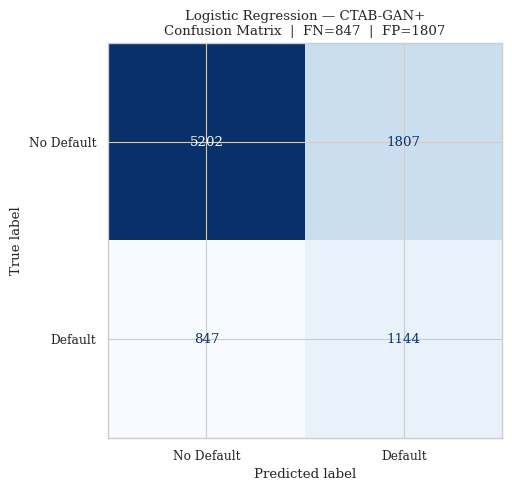

Random Forest — CTAB-GAN+ — CLASSIFICATION REPORT
              precision    recall  f1-score   support

  No Default       0.85      0.91      0.88      7009
     Default       0.56      0.42      0.48      1991

    accuracy                           0.80      9000
   macro avg       0.71      0.66      0.68      9000
weighted avg       0.78      0.80      0.79      9000

  ROC-AUC:            0.7256
  Avg Precision (PR): 0.4918
  Macro F1:           0.6785
  Minority Recall:    0.4194
  Minority Precision: 0.5638
  Minority F1:        0.4810


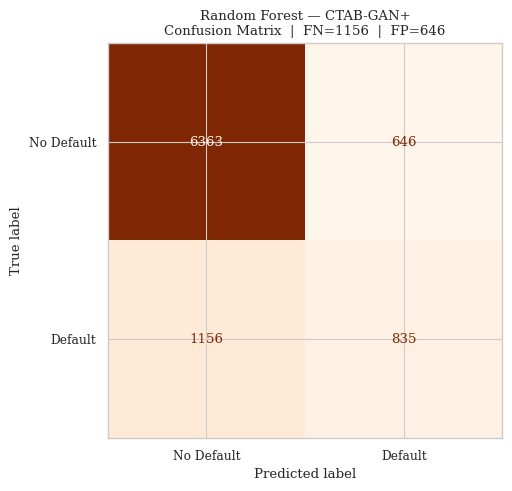


CTAB-GAN+ section completed successfully.


In [49]:
if CTABGAN_AVAILABLE and synthetic_ctab is not None:
    
    # --------------------------------------------------------------------------
    # 5.3.5 — Build Balanced Training Set and Train Classifiers
    # --------------------------------------------------------------------------
    
    # Build balanced training set
    balanced_ctab = pd.concat([train_data_full, synthetic_ctab], ignore_index=True)
    
    X_train_ctab_raw = balanced_ctab.drop("def_pay", axis=1)
    y_train_ctab = balanced_ctab["def_pay"]
    
    print("\nCTAB-GAN+ class distribution (balanced training set):")
    print(y_train_ctab.value_counts())
    
    # Scale using the CANONICAL scaler (transform only — no re-fit)
    X_train_ctab_scaled = scaler.transform(X_train_ctab_raw)
    
    # Train classifiers
    log_reg_ctab = LogisticRegression(random_state=RANDOM_STATE, max_iter=1000)
    rf_clf_ctab = RandomForestClassifier(random_state=RANDOM_STATE, n_estimators=100)
    
    print("\nTraining Logistic Regression (CTAB-GAN+)...")
    log_reg_ctab.fit(X_train_ctab_scaled, y_train_ctab)
    print("Training Random Forest (CTAB-GAN+)...")
    rf_clf_ctab.fit(X_train_ctab_scaled, y_train_ctab)
    
    # Evaluate on the UNTOUCHED original test set
    results_lr_ctab = evaluate_model(
        log_reg_ctab, X_test_scaled, y_test,
        "Logistic Regression — CTAB-GAN+", "Blues"
    )
    
    results_rf_ctab = evaluate_model(
        rf_clf_ctab, X_test_scaled, y_test,
        "Random Forest — CTAB-GAN+", "Oranges"
    )
    
    print("\nCTAB-GAN+ section completed successfully.")
    
else:
    print("\nCTAB-GAN+ section skipped due to missing import or synthetic_ctab is None.")
    results_lr_ctab = None
    results_rf_ctab = None

In [50]:
# ==============================================================================
# FINAL SUMMARY — VERIFICATION & IMPORTS
# ==============================================================================
#
# This cell verifies that all expected result variables are available
# before proceeding with the summary tables and visualizations.
# ==============================================================================

import pandas as pd
import matplotlib.pyplot as plt

print("=" * 70)
print("FINAL SUMMARY — VERIFYING AVAILABLE VARIABLES")
print("=" * 70)

# Define expected variables based on available models
expected_vars = ['results_lr_base', 'results_rf_base', 'results_lr_smote', 'results_rf_smote']

if CTGAN_AVAILABLE:
    expected_vars.extend(['results_lr_ctgan', 'results_rf_ctgan'])

if CTABGAN_AVAILABLE:
    expected_vars.extend(['results_lr_ctab', 'results_rf_ctab'])

# Check which variables exist
available_vars = []
missing_vars = []

for var in expected_vars:
    if var in globals() and globals()[var] is not None:
        available_vars.append(var)
        val = globals()[var]
        if isinstance(val, dict) and 'auc' in val:
            print(f"  {var}: AUC={val['auc']:.4f}, Macro F1={val['macro_f1']:.4f}")
        else:
            print(f"  {var}: {val}")
    else:
        missing_vars.append(var)
        print(f"  {var} NOT FOUND")

print(f"\nSummary: {len(available_vars)}/{len(expected_vars)} variables available.")

FINAL SUMMARY — VERIFYING AVAILABLE VARIABLES
  results_lr_base: AUC=0.7298, Macro F1=0.6180
  results_rf_base: AUC=0.7611, Macro F1=0.6792
  results_lr_smote: AUC=0.7316, Macro F1=0.6232
  results_rf_smote: AUC=0.7567, Macro F1=0.6891
  results_lr_ctgan: AUC=0.7218, Macro F1=0.6362
  results_rf_ctgan: AUC=0.7594, Macro F1=0.6907
  results_lr_ctab: AUC=0.7041, Macro F1=0.6299
  results_rf_ctab: AUC=0.7256, Macro F1=0.6785

Summary: 8/8 variables available.


In [51]:
# ==============================================================================
# FINAL SUMMARY — SIMPLE RESULTS TABLE (AUC & MACRO F1)
# ==============================================================================
#
# This cell produces a clean summary table showing AUC and Macro F1
# for all available models (Baseline, SMOTE, CTGAN, CTAB-GAN+).
# ==============================================================================

print("\n" + "=" * 70)
print("SUMMARY OF RESULTS — ALL MODELS")
print("=" * 70)

# ------------------------------------------------------------------------------
# Logistic Regression Results
# ------------------------------------------------------------------------------
print("\nLOGISTIC REGRESSION RESULTS:")
print("-" * 55)
print(f"  {'Model':<25} {'AUC':<12} {'Macro F1':<12}")
print("-" * 55)
print(f"  {'Baseline (Imbalanced)':<25} {results_lr_base['auc']:.4f}      {results_lr_base['macro_f1']:.4f}")
print(f"  {'SMOTE':<25} {results_lr_smote['auc']:.4f}      {results_lr_smote['macro_f1']:.4f}")

if CTGAN_AVAILABLE and results_lr_ctgan is not None:
    print(f"  {'CTGAN':<25} {results_lr_ctgan['auc']:.4f}      {results_lr_ctgan['macro_f1']:.4f}")
else:
    print(f"  {'CTGAN':<25} {'N/A':<12} {'N/A':<12}")

if CTABGAN_AVAILABLE and results_lr_ctab is not None:
    print(f"  {'CTAB-GAN+':<25} {results_lr_ctab['auc']:.4f}      {results_lr_ctab['macro_f1']:.4f}")
else:
    print(f"  {'CTAB-GAN+':<25} {'N/A':<12} {'N/A':<12}")

# ------------------------------------------------------------------------------
# Random Forest Results
# ------------------------------------------------------------------------------
print("\nRANDOM FOREST RESULTS:")
print("-" * 55)
print(f"  {'Model':<25} {'AUC':<12} {'Macro F1':<12}")
print("-" * 55)
print(f"  {'Baseline (Imbalanced)':<25} {results_rf_base['auc']:.4f}      {results_rf_base['macro_f1']:.4f}")
print(f"  {'SMOTE':<25} {results_rf_smote['auc']:.4f}      {results_rf_smote['macro_f1']:.4f}")

if CTGAN_AVAILABLE and results_rf_ctgan is not None:
    print(f"  {'CTGAN':<25} {results_rf_ctgan['auc']:.4f}      {results_rf_ctgan['macro_f1']:.4f}")
else:
    print(f"  {'CTGAN':<25} {'N/A':<12} {'N/A':<12}")

if CTABGAN_AVAILABLE and results_rf_ctab is not None:
    print(f"  {'CTAB-GAN+':<25} {results_rf_ctab['auc']:.4f}      {results_rf_ctab['macro_f1']:.4f}")
else:
    print(f"  {'CTAB-GAN+':<25} {'N/A':<12} {'N/A':<12}")

print("\n" + "=" * 70)
print("Legend: AUC (higher is better) | Macro F1 (higher is better)")
print("=" * 70)


SUMMARY OF RESULTS — ALL MODELS

LOGISTIC REGRESSION RESULTS:
-------------------------------------------------------
  Model                     AUC          Macro F1    
-------------------------------------------------------
  Baseline (Imbalanced)     0.7298      0.6180
  SMOTE                     0.7316      0.6232
  CTGAN                     0.7218      0.6362
  CTAB-GAN+                 0.7041      0.6299

RANDOM FOREST RESULTS:
-------------------------------------------------------
  Model                     AUC          Macro F1    
-------------------------------------------------------
  Baseline (Imbalanced)     0.7611      0.6792
  SMOTE                     0.7567      0.6891
  CTGAN                     0.7594      0.6907
  CTAB-GAN+                 0.7256      0.6785

Legend: AUC (higher is better) | Macro F1 (higher is better)


In [52]:
# ==============================================================================
# FINAL SUMMARY — BUILD COMPLETE DATAFRAME
# ==============================================================================
#
# This cell constructs a comprehensive DataFrame with all metrics
# (Accuracy, Precision, Recall, F1, AUC, Macro F1) for all conditions.
# ==============================================================================

def extract_detailed_metrics(results_dict, condition_name, classifier_name):
    """
    Extract detailed metrics from a results dictionary.
    
    Parameters:
    -----------
    results_dict : dict
        Dictionary returned by evaluate_model() containing 'report', 'auc', 'macro_f1'
    condition_name : str
        Name of the augmentation condition (e.g., 'Baseline', 'SMOTE')
    classifier_name : str
        Name of the classifier ('LR' or 'RF')
    
    Returns:
    --------
    dict or None
        Dictionary with all metrics, or None if results_dict is None
    """
    if results_dict is None:
        return None
    
    return {
        "Condition": condition_name,
        "Classifier": classifier_name,
        "Accuracy": results_dict['report']['accuracy'],
        "Precision (Default)": results_dict['report']['Default']['precision'],
        "Recall (Default)": results_dict['report']['Default']['recall'],
        "F1-score (Default)": results_dict['report']['Default']['f1-score'],
        "ROC-AUC": results_dict['auc'],
        "Macro F1": results_dict['macro_f1'],
    }

# Collect all available results
all_results = []

# Baseline
all_results.append(extract_detailed_metrics(results_lr_base, "Baseline", "LR"))
all_results.append(extract_detailed_metrics(results_rf_base, "Baseline", "RF"))

# SMOTE
all_results.append(extract_detailed_metrics(results_lr_smote, "SMOTE", "LR"))
all_results.append(extract_detailed_metrics(results_rf_smote, "SMOTE", "RF"))

# CTGAN (if available)
if CTGAN_AVAILABLE and results_lr_ctgan is not None:
    all_results.append(extract_detailed_metrics(results_lr_ctgan, "CTGAN", "LR"))
    all_results.append(extract_detailed_metrics(results_rf_ctgan, "CTGAN", "RF"))

# CTAB-GAN+ (if available)
if CTABGAN_AVAILABLE and results_lr_ctab is not None:
    all_results.append(extract_detailed_metrics(results_lr_ctab, "CTAB-GAN+", "LR"))
    all_results.append(extract_detailed_metrics(results_rf_ctab, "CTAB-GAN+", "RF"))

# Remove None entries and create DataFrame
all_results = [r for r in all_results if r is not None]
detailed_df = pd.DataFrame(all_results)

print("\n" + "=" * 70)
print("COMPLETE DATAFRAME — ALL METRICS")
print("=" * 70)
print(detailed_df.set_index(["Condition", "Classifier"]).round(4))


COMPLETE DATAFRAME — ALL METRICS
                      Accuracy  Precision (Default)  Recall (Default)  \
Condition Classifier                                                    
Baseline  LR            0.8099               0.7222            0.2285   
          RF            0.8176               0.6588            0.3636   
SMOTE     LR            0.6781               0.3732            0.6695   
          RF            0.7948               0.5409            0.4787   
CTGAN     LR            0.7119               0.3963            0.5781   
          RF            0.8082               0.5907            0.4335   
CTAB-GAN+ LR            0.7051               0.3877            0.5746   
          RF            0.7998               0.5638            0.4194   

                      F1-score (Default)  ROC-AUC  Macro F1  
Condition Classifier                                         
Baseline  LR                      0.3472   0.7298    0.6180  
          RF                      0.4686   0.7611

In [53]:
# ==============================================================================
# FINAL SUMMARY — PIVOT TABLES
# ==============================================================================
#
# This cell creates pivot tables for each metric, showing performance
# across conditions (rows) and classifiers (columns).
# ==============================================================================

print("\n" + "=" * 70)
print("PIVOT TABLES — COMPARISON ACROSS CONDITIONS")
print("=" * 70)

metrics_to_pivot = ["ROC-AUC", "Recall (Default)", "F1-score (Default)", "Macro F1", "Accuracy"]

for metric in metrics_to_pivot:
    pivot = detailed_df.pivot(index="Condition", columns="Classifier", values=metric)
    print(f"\n{metric}:")
    print(pivot.round(4))

# Best results per metric
print("\n" + "=" * 70)
print("BEST RESULTS PER METRIC")
print("=" * 70)

for metric in ["ROC-AUC", "Recall (Default)", "F1-score (Default)", "Macro F1"]:
    best_idx = detailed_df[metric].idxmax()
    best_row = detailed_df.loc[best_idx]
    print(f"\nBest {metric}:")
    print(f"   {best_row['Condition']} + {best_row['Classifier']} = {best_row[metric]:.4f}")


PIVOT TABLES — COMPARISON ACROSS CONDITIONS

ROC-AUC:
Classifier      LR      RF
Condition                 
Baseline    0.7298  0.7611
CTAB-GAN+   0.7041  0.7256
CTGAN       0.7218  0.7594
SMOTE       0.7316  0.7567

Recall (Default):
Classifier      LR      RF
Condition                 
Baseline    0.2285  0.3636
CTAB-GAN+   0.5746  0.4194
CTGAN       0.5781  0.4335
SMOTE       0.6695  0.4787

F1-score (Default):
Classifier      LR      RF
Condition                 
Baseline    0.3472  0.4686
CTAB-GAN+   0.4630  0.4810
CTGAN       0.4703  0.5000
SMOTE       0.4792  0.5079

Macro F1:
Classifier      LR      RF
Condition                 
Baseline    0.6180  0.6792
CTAB-GAN+   0.6299  0.6785
CTGAN       0.6362  0.6907
SMOTE       0.6232  0.6891

Accuracy:
Classifier      LR      RF
Condition                 
Baseline    0.8099  0.8176
CTAB-GAN+   0.7051  0.7998
CTGAN       0.7119  0.8082
SMOTE       0.6781  0.7948

BEST RESULTS PER METRIC

Best ROC-AUC:
   Baseline + RF = 0.7611

Best R

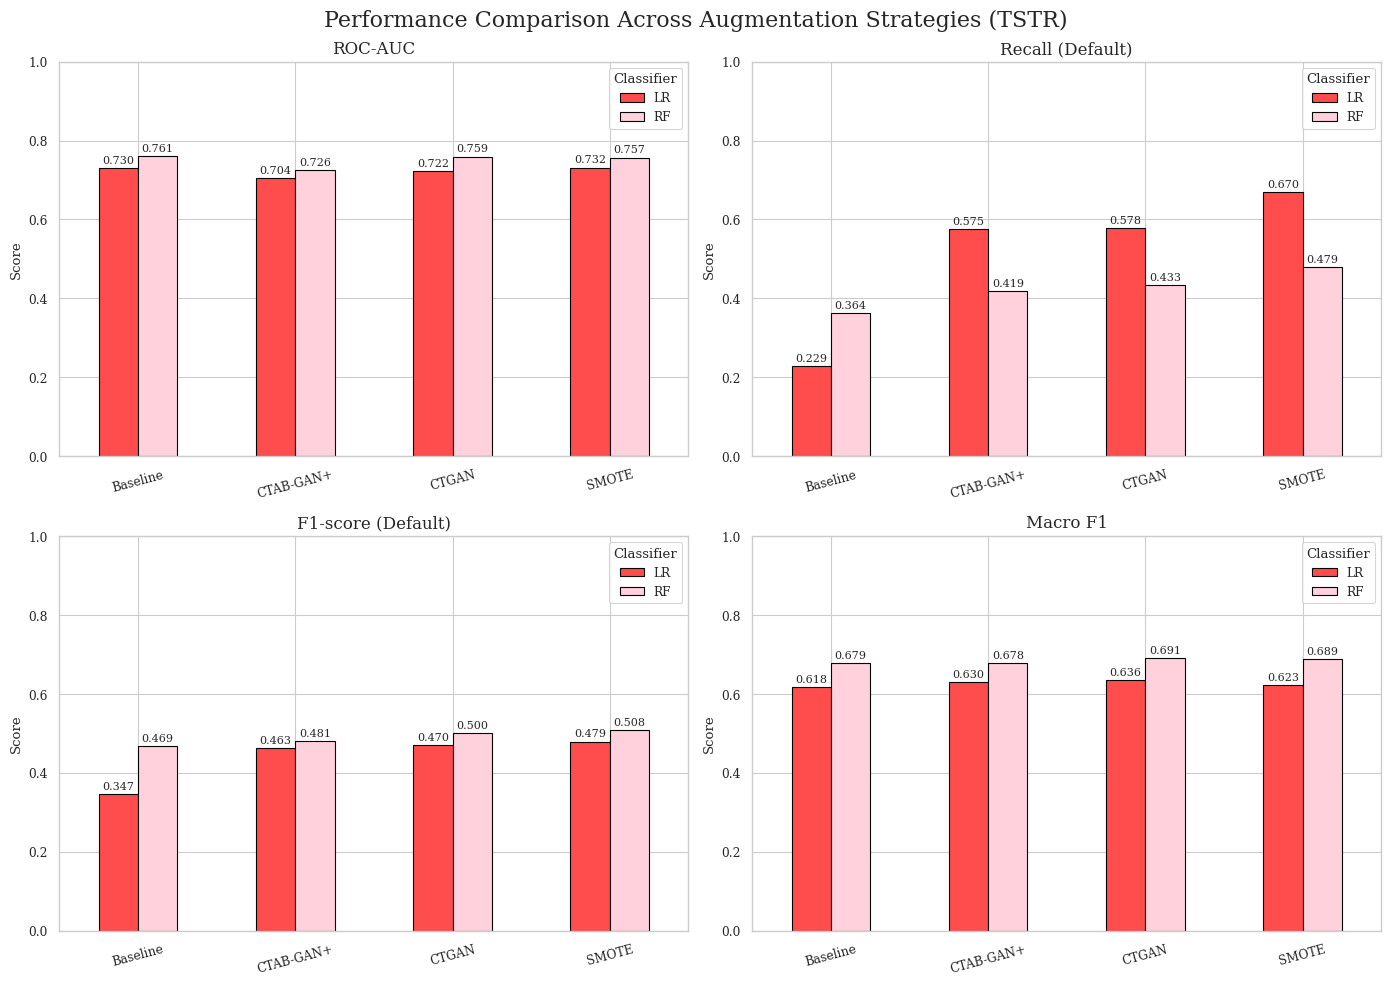

In [54]:
# ==============================================================================
# FINAL SUMMARY — VISUALIZATION (2x2 SUBPLOTS)
# ==============================================================================
#
# This cell generates a 2x2 grid of bar charts showing:
#   - ROC-AUC
#   - Recall (Default)
#   - F1-score (Default)
#   - Macro F1
# ==============================================================================

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Performance Comparison Across Augmentation Strategies (TSTR)", fontsize=16)

colors = ["#FF4D4D", "#FFD1DC"]  # LR = red, RF = pink
plot_metrics = ["ROC-AUC", "Recall (Default)", "F1-score (Default)", "Macro F1"]

for idx, metric in enumerate(plot_metrics):
    row, col = divmod(idx, 2)
    pivot = detailed_df.pivot(index="Condition", columns="Classifier", values=metric)
    ax = pivot.plot(kind="bar", ax=axes[row, col], color=colors, edgecolor="black")
    axes[row, col].set_title(metric, fontsize=12)
    axes[row, col].set_ylabel("Score")
    axes[row, col].set_xlabel("")
    axes[row, col].set_ylim(0, 1)
    axes[row, col].legend(title="Classifier")
    axes[row, col].tick_params(axis='x', rotation=15)
    
    # Add value labels on bars
    for container in ax.containers:
        ax.bar_label(container, fmt="%.3f", fontsize=8, padding=2)

plt.tight_layout()
plt.show()

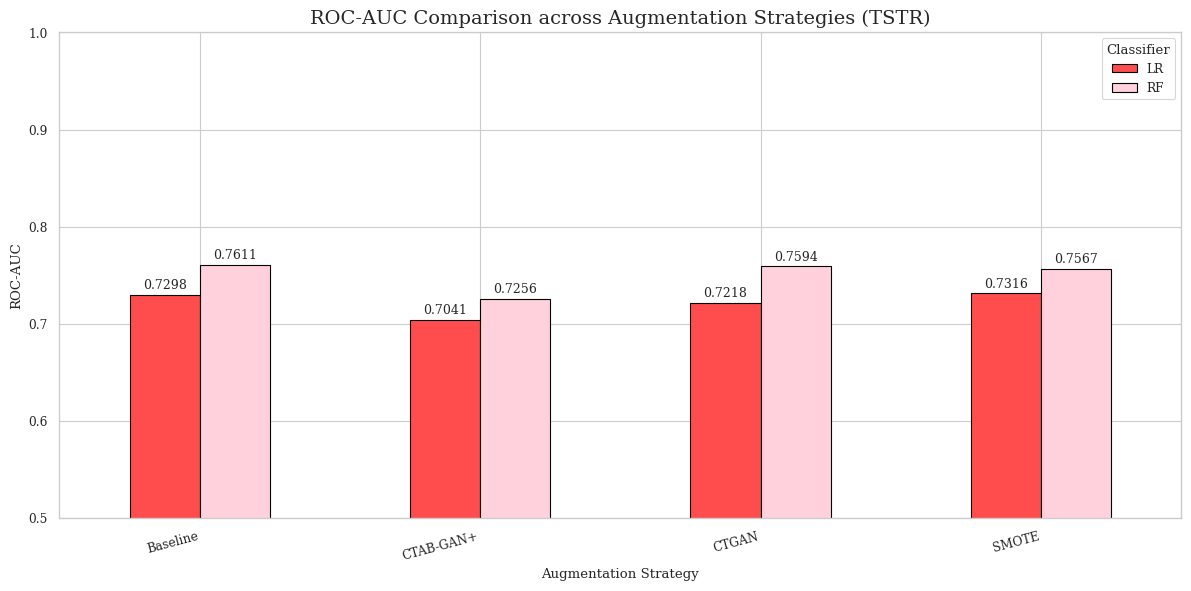

In [55]:
# ==============================================================================
# FINAL SUMMARY — ROC-AUC BAR CHART
# ==============================================================================
#
# This cell generates a dedicated bar chart for ROC-AUC comparison.
# ==============================================================================

roc_pivot = detailed_df.pivot(index="Condition", columns="Classifier", values="ROC-AUC")

ax = roc_pivot.plot(kind="bar", figsize=(12, 6), color=["#FF4D4D", "#FFD1DC"], edgecolor="black")
plt.title("ROC-AUC Comparison across Augmentation Strategies (TSTR)", fontsize=14)
plt.ylabel("ROC-AUC")
plt.xlabel("Augmentation Strategy")
plt.xticks(rotation=15, ha="right")
plt.ylim(0.5, 1.0)
plt.legend(title="Classifier")

for container in ax.containers:
    ax.bar_label(container, fmt="%.4f", fontsize=9, padding=2)

plt.tight_layout()
plt.show()

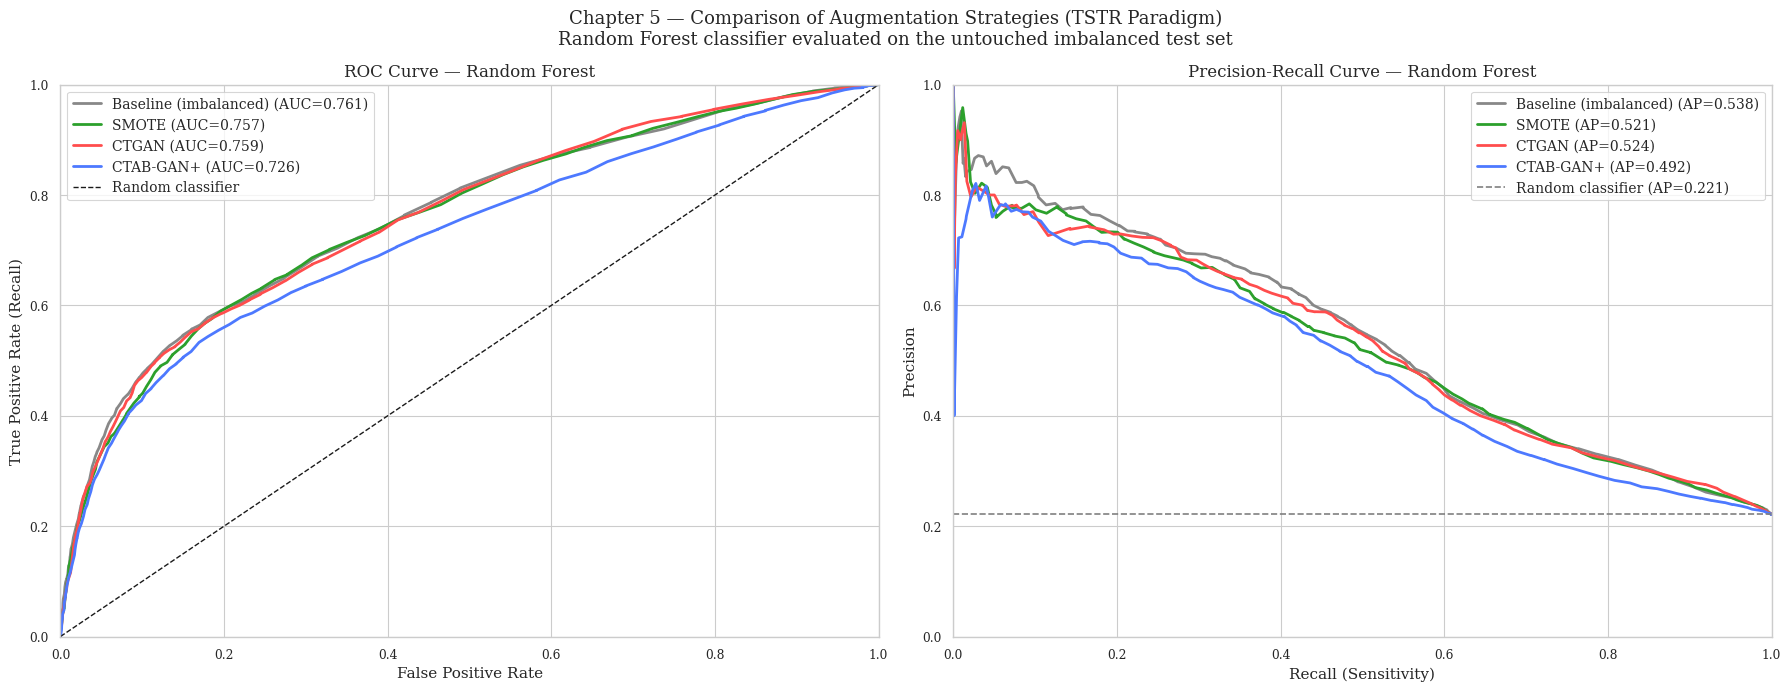

Figure saved: figures/roc_pr_all_strategies_rf.png

Note: The PR curve is more informative than ROC in imbalanced settings.
It directly illustrates the trade-off between detecting true defaulters (recall)
and minimizing false alarms (precision) — the core challenge in fraud detection.


In [56]:
# ==============================================================================
# FINAL SUMMARY — Comparative ROC and Precision-Recall Curves
# Random Forest — all augmentation strategies
# ==============================================================================
#
# The Precision-Recall curve is more informative than ROC in imbalanced settings:
# it focuses exclusively on the minority class and is not artificially inflated
# by the large proportion of the majority class.
# (Davis & Goadrich, 2006; Saito & Rehmsmeier, 2015)
# ==============================================================================

# Aggregate Random Forest results by strategy
# (CTGAN and CTAB-GAN+ are included only if available)
rf_results_all = [
    ("Baseline (imbalanced)", results_rf_base,  "#888888"),
    ("SMOTE",                 results_rf_smote, "#2ca02c"),
]

if CTGAN_AVAILABLE and results_rf_ctgan is not None:
    rf_results_all.append(("CTGAN",     results_rf_ctgan, "#FF4D4D"))

if CTABGAN_AVAILABLE and results_rf_ctab is not None:
    rf_results_all.append(("CTAB-GAN+", results_rf_ctab,  "#4D79FF"))

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle(
    "Chapter 5 — Comparison of Augmentation Strategies (TSTR Paradigm)\n"
    "Random Forest classifier evaluated on the untouched imbalanced test set",
    fontsize=13
)

# ── ROC Curve ─────────────────────────────────────────────────────────────────
for name, res, color in rf_results_all:
    if res is None:
        continue
    fpr, tpr, _ = roc_curve(y_test, res["y_prob"])
    axes[0].plot(fpr, tpr, color=color, linewidth=2,
                 label=f"{name} (AUC={res['auc']:.3f})")

axes[0].plot([0, 1], [0, 1], "k--", linewidth=1, label="Random classifier")
axes[0].set_xlabel("False Positive Rate", fontsize=11)
axes[0].set_ylabel("True Positive Rate (Recall)", fontsize=11)
axes[0].set_title("ROC Curve — Random Forest", fontsize=12)
axes[0].legend(fontsize=10)
axes[0].set_xlim(0, 1)
axes[0].set_ylim(0, 1)

# ── Precision-Recall Curve ────────────────────────────────────────────────────
for name, res, color in rf_results_all:
    if res is None:
        continue
    prec, rec, _ = precision_recall_curve(y_test, res["y_prob"])
    ap_val       = res["avg_precision"]
    axes[1].plot(rec, prec, color=color, linewidth=2,
                 label=f"{name} (AP={ap_val:.3f})")

# Random classifier baseline = class prevalence in the test set
prevalence = y_test.mean()
axes[1].axhline(
    prevalence, color="gray", linestyle="--", linewidth=1.2,
    label=f"Random classifier (AP={prevalence:.3f})"
)
axes[1].set_xlabel("Recall (Sensitivity)", fontsize=11)
axes[1].set_ylabel("Precision", fontsize=11)
axes[1].set_title("Precision-Recall Curve — Random Forest", fontsize=12)
axes[1].legend(fontsize=10)
axes[1].set_xlim(0, 1)
axes[1].set_ylim(0, 1)

plt.tight_layout()
plt.savefig("figures/roc_pr_all_strategies_rf.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figure saved: figures/roc_pr_all_strategies_rf.png")
print("\nNote: The PR curve is more informative than ROC in imbalanced settings.")
print("It directly illustrates the trade-off between detecting true defaulters (recall)")
print("and minimizing false alarms (precision) — the core challenge in fraud detection.")

In [57]:
# ==============================================================================
# FINAL SUMMARY — OBJECTS AVAILABLE FOR CHAPTER 6
# ==============================================================================
#
# This cell lists all objects that have been created and are available
# for the multidimensional evaluation phase (fidelity, feasibility and privacy).
# ==============================================================================

print("\n" + "=" * 70)
print("OBJECTS AVAILABLE FOR CHAPTER 6 (Multidimensional Evaluation)")
print("=" * 70)

available_objects = {
    "scaler": "fitted StandardScaler",
    "X_train": "raw training features",
    "X_test": "raw test features",
    "y_train": "training target",
    "y_test": "test target",
    "X_test_scaled": "scaled test features",
    "train_data_raw": "full raw training data (with target)",
    "train_minority_raw": "raw minority training records (CTGAN)",
}

for obj_name, description in available_objects.items():
    if obj_name in globals():
        print(f"  {obj_name:<20} : {description}")
    else:
        print(f"  {obj_name:<20} : NOT FOUND")

# CTGAN synthetic data
if CTGAN_AVAILABLE and 'synthetic_ctgan' in globals():
    print(f"  synthetic_ctgan     : raw synthetic minority records (CTGAN)")

# CTAB-GAN+ synthetic data
if CTABGAN_AVAILABLE and 'synthetic_ctab' in globals():
    print(f"  synthetic_ctab      : raw synthetic minority records (CTAB-GAN+)")

# Detailed results DataFrames
print(f"\n  detailed_df         : complete metrics DataFrame ({len(detailed_df)} rows)")

print("\n" + "=" * 70)
print("Chapters 3-5 pipeline complete.")
print("Proceed to Chapter 6 for multidimensional evaluation (fidelity, feasibility and privacy).")
print("=" * 70)


OBJECTS AVAILABLE FOR CHAPTER 6 (Multidimensional Evaluation)
  scaler               : fitted StandardScaler
  X_train              : raw training features
  X_test               : raw test features
  y_train              : training target
  y_test               : test target
  X_test_scaled        : scaled test features
  train_data_raw       : full raw training data (with target)
  train_minority_raw   : raw minority training records (CTGAN)
  synthetic_ctgan     : raw synthetic minority records (CTGAN)
  synthetic_ctab      : raw synthetic minority records (CTAB-GAN+)

  detailed_df         : complete metrics DataFrame (8 rows)

Chapters 3-5 pipeline complete.
Proceed to Chapter 6 for multidimensional evaluation (fidelity, feasibility and privacy).


In [58]:
#############################################################################################

In [59]:
# ======================================================================
# TRAIN SET EVALUATION: train vs test comparison (Random Forest)
# Added following the supervisors' suggestion, to check for overfitting
# ======================================================================

from sklearn.metrics import roc_auc_score, f1_score, recall_score, precision_score

print("=" * 70)
print("TRAIN SET EVALUATION — Random Forest (compared with the test set)")
print("=" * 70)

# Training sets and fitted Random Forest models for each strategy
train_configs = [
    ("Baseline",  X_train_scaled,       y_train,       rf_clf),
    ("SMOTE",     X_train_smote,         y_train_smote, rf_clf_smote),
    ("CTGAN",     X_train_ctgan_scaled,  y_train_ctgan, rf_clf_ctgan),
    ("CTAB-GAN+", X_train_ctab_scaled,   y_train_ctab,  rf_clf_ctab),
]

# Test-set values, copied from the TSTR results table above
test_aucs = {
    "Baseline":   0.7611,
    "SMOTE":      0.7567,
    "CTGAN":      0.7594,
    "CTAB-GAN+":  0.7249,
}

print(f"\n{'Strategy':<15} {'AUC Train':>12} {'AUC Test':>12} {'Gap':>10}")
print("-" * 52)

train_results = {}
for name, X_tr, y_tr, model in train_configs:
    y_prob_tr = model.predict_proba(X_tr)[:, 1]
    y_pred_tr = model.predict(X_tr)

    auc_tr  = roc_auc_score(y_tr, y_prob_tr)
    rec_tr  = recall_score(y_tr, y_pred_tr)
    prec_tr = precision_score(y_tr, y_pred_tr, zero_division=0)
    f1_tr   = f1_score(y_tr, y_pred_tr)
    mf1_tr  = f1_score(y_tr, y_pred_tr, average="macro")
    gap     = auc_tr - test_aucs[name]

    train_results[name] = {
        "auc": auc_tr, "recall": rec_tr, "precision": prec_tr,
        "f1": f1_tr, "macro_f1": mf1_tr, "gap": gap
    }

    print(f"{name:<15} {auc_tr:>12.4f} {test_aucs[name]:>12.4f} {gap:>+10.4f}")

print("\nGap = AUC Train - AUC Test. A large gap suggests overfitting.")

# Detailed table: train value (left) vs test value (right)
test_vals = {
    "Baseline":   {"recall": 0.3636, "precision": 0.6588, "f1": 0.4686, "macro_f1": 0.6792},
    "SMOTE":      {"recall": 0.4787, "precision": 0.5409, "f1": 0.5079, "macro_f1": 0.6891},
    "CTGAN":      {"recall": 0.4335, "precision": 0.5907, "f1": 0.5000, "macro_f1": 0.6907},
    "CTAB-GAN+":  {"recall": 0.4184, "precision": 0.5484, "f1": 0.4746, "macro_f1": 0.6737},
}

print(f"\n{'='*70}")
print("DETAILED TABLE — TRAIN vs TEST")
print(f"{'='*70}")

for name, _, _, _ in train_configs:
    tr = train_results[name]
    te = test_vals[name]
    print(f"\n  {name}")
    print(f"  {'AUC':<20} {tr['auc']:>8.4f}   {test_aucs[name]:>8.4f}")
    print(f"  {'Recall (Default)':<20} {tr['recall']:>8.4f}   {te['recall']:>8.4f}")
    print(f"  {'Precision':<20} {tr['precision']:>8.4f}   {te['precision']:>8.4f}")
    print(f"  {'F1 (Default)':<20} {tr['f1']:>8.4f}   {te['f1']:>8.4f}")
    print(f"  {'Macro F1':<20} {tr['macro_f1']:>8.4f}   {te['macro_f1']:>8.4f}")


TRAIN SET EVALUATION — Random Forest (compared with the test set)

Strategy           AUC Train     AUC Test        Gap
----------------------------------------------------
Baseline              1.0000       0.7611    +0.2389
SMOTE                 1.0000       0.7567    +0.2433
CTGAN                 1.0000       0.7594    +0.2406
CTAB-GAN+             1.0000       0.7249    +0.2751

Gap = AUC Train - AUC Test. A large gap suggests overfitting.

DETAILED TABLE — TRAIN vs TEST

  Baseline
  AUC                    1.0000     0.7611
  Recall (Default)       0.9978     0.3636
  Precision              0.9994     0.6588
  F1 (Default)           0.9986     0.4686
  Macro F1               0.9991     0.6792

  SMOTE
  AUC                    1.0000     0.7567
  Recall (Default)       0.9996     0.4787
  Precision              0.9997     0.5409
  F1 (Default)           0.9997     0.5079
  Macro F1               0.9997     0.6891

  CTGAN
  AUC                    1.0000     0.7594
  Recall (Default

In [60]:
"""
================================================================================
  CHAPTER 6 — STATISTICAL FIDELITY: TVD ANALYSIS PER VARIABLE
  + PRE-AUDIT FOR HE ET AL. (2025) 7 PROPERTIES
================================================================================

This section produces:

  1. TVD (Total Variation Distance) for all categorical/ordinal variables
  2. KS statistic for all continuous variables
  3. A unified fidelity heatmap across CTGAN and CTAB-GAN+
  4. Pre-audit data structures needed for He et al. (2025) 7-property framework

REQUIRES: All objects from Chapters 3-5 to be loaded in the session.
  - train_data_full      : full raw training set (with def_pay)
  - synthetic_ctgan      : CTGAN synthetic minority (post-correction)
  - synthetic_ctab       : CTAB-GAN+ synthetic minority (post-correction)

NOTE: TVD is computed for the *minority class* distributions only,
comparing synthetic minority vs real minority. This is correct because
both generators were tasked with synthesising the minority class.
================================================================================
"""

'\n================================================================================\n  CHAPTER 6 — STATISTICAL FIDELITY: TVD ANALYSIS PER VARIABLE\n  + PRE-AUDIT FOR HE ET AL. (2025) 7 PROPERTIES\n================================================================================\n\nThis section produces:\n\n  1. TVD (Total Variation Distance) for all categorical/ordinal variables\n  2. KS statistic for all continuous variables\n  3. A unified fidelity heatmap across CTGAN and CTAB-GAN+\n  4. Pre-audit data structures needed for He et al. (2025) 7-property framework\n\nREQUIRES: All objects from Chapters 3-5 to be loaded in the session.\n  - train_data_full      : full raw training set (with def_pay)\n  - synthetic_ctgan      : CTGAN synthetic minority (post-correction)\n  - synthetic_ctab       : CTAB-GAN+ synthetic minority (post-correction)\n\nNOTE: TVD is computed for the *minority class* distributions only,\ncomparing synthetic minority vs real minority. This is correct because\nboth

In [61]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [62]:
# ==============================================================================
# 6.0 — SETUP: Extract real minority from training set
# ==============================================================================

# Real minority records from training data (the "ground truth" for comparison)
train_minority_raw = train_data_full[train_data_full["def_pay"].astype(int) == 1].copy()

print(f"Real minority (train): {len(train_minority_raw)} records")
print(f"CTGAN synthetic:       {len(synthetic_ctgan)} records")
print(f"CTAB-GAN+ synthetic:   {len(synthetic_ctab)} records")

Real minority (train): 4645 records
CTGAN synthetic:       11710 records
CTAB-GAN+ synthetic:   11710 records


In [63]:
# ==============================================================================
# 6.1 — COLUMN TYPE DEFINITIONS
# ==============================================================================
# These must match the domain knowledge established in Chapter 3.
# PAY_X columns are treated as ORDINAL (discrete integers) for TVD computation.
# BILL_AMT and PAY_AMT are treated as CONTINUOUS for KS computation.

CATEGORICAL_COLS = ["SEX", "EDUCATION", "MARRIAGE"]

ORDINAL_COLS = ["PAY_1", "PAY_2", "PAY_3", "PAY_4", "PAY_5", "PAY_6"]

CONTINUOUS_COLS = [
    "LIMIT_BAL", "AGE",
    "BILL_AMT1", "BILL_AMT2", "BILL_AMT3",
    "BILL_AMT4", "BILL_AMT5", "BILL_AMT6",
    "PAY_AMT1", "PAY_AMT2", "PAY_AMT3",
    "PAY_AMT4", "PAY_AMT5", "PAY_AMT6",
]

ALL_FEATURE_COLS = CATEGORICAL_COLS + ORDINAL_COLS + CONTINUOUS_COLS



In [64]:
# ==============================================================================
# 6.2 — TVD FUNCTION (for categorical and ordinal columns)
# ==============================================================================

def compute_tvd(real_series, synth_series, column_type="categorical"):
    """
    Compute Total Variation Distance between real and synthetic distributions.
    
    For categorical/ordinal: TVD = 0.5 * sum(|P(k) - Q(k)|)
    Interpretation: TVD=0 means identical distributions; TVD=1 means no overlap.
    
    Parameters
    ----------
    real_series  : pd.Series — real data column
    synth_series : pd.Series — synthetic data column
    column_type  : "categorical" or "ordinal"
    
    Returns
    -------
    float : TVD in [0, 1]
    dict  : {"real": proportions, "synth": proportions, "diff": differences}
    """
    # Get all categories that appear in either distribution
    all_cats = sorted(set(real_series.dropna().unique()) |
                      set(synth_series.dropna().unique()))
    
    # Compute normalized proportions (handling missing categories with 0)
    real_props  = real_series.value_counts(normalize=True)
    synth_props = synth_series.value_counts(normalize=True)
    
    real_vec  = np.array([real_props.get(c, 0.0) for c in all_cats])
    synth_vec = np.array([synth_props.get(c, 0.0) for c in all_cats])
    
    tvd = 0.5 * np.sum(np.abs(real_vec - synth_vec))
    
    detail = {
        "categories": all_cats,
        "real":  real_vec,
        "synth": synth_vec,
        "diff":  synth_vec - real_vec,
    }
    return tvd, detail


def compute_ks(real_series, synth_series):
    """
    Compute Kolmogorov-Smirnov statistic for continuous variables.
    
    KS statistic = max|F_real(x) - F_synth(x)|
    p-value < 0.05 → distributions are significantly different.
    
    Returns
    -------
    ks_stat : float in [0, 1]
    p_value : float
    """
    real_clean  = real_series.dropna().astype(float)
    synth_clean = synth_series.dropna().astype(float)
    ks_stat, p_value = stats.ks_2samp(real_clean, synth_clean)
    return ks_stat, p_value

In [65]:
# ==============================================================================
# 6.3 — COMPUTE ALL METRICS: CTGAN vs Real Minority
# ==============================================================================

print("\n" + "="*70)
print("TVD / KS ANALYSIS: CTGAN Synthetic vs Real Minority")
print("="*70)

results_ctgan = {}

# Categorical TVD
for col in CATEGORICAL_COLS + ORDINAL_COLS:
    tvd, detail = compute_tvd(
        train_minority_raw[col].astype(int),
        synthetic_ctgan[col].astype(int)
    )
    results_ctgan[col] = {
        "metric": "TVD",
        "value": tvd,
        "detail": detail,
        "col_type": "categorical" if col in CATEGORICAL_COLS else "ordinal",
    }
    status = "GOOD" if tvd < 0.05 else ("MODERATE" if tvd < 0.15 else "POOR")
    print(f"  {col:<12} TVD = {tvd:.4f}  {status}")

# Continuous KS
for col in CONTINUOUS_COLS:
    ks, pval = compute_ks(
        train_minority_raw[col].astype(float),
        synthetic_ctgan[col].astype(float)
    )
    results_ctgan[col] = {
        "metric": "KS",
        "value": ks,
        "p_value": pval,
        "col_type": "continuous",
    }
    status = "GOOD" if ks < 0.05 else ("MODERATE" if ks < 0.15 else "POOR")
    print(f"  {col:<12} KS  = {ks:.4f}  (p={pval:.3f})  {status}")


TVD / KS ANALYSIS: CTGAN Synthetic vs Real Minority
  SEX          TVD = 0.1741  POOR
  EDUCATION    TVD = 0.1731  POOR
  MARRIAGE     TVD = 0.0677  MODERATE
  PAY_1        TVD = 0.1775  POOR
  PAY_2        TVD = 0.1365  MODERATE
  PAY_3        TVD = 0.1917  POOR
  PAY_4        TVD = 0.1837  POOR
  PAY_5        TVD = 0.1691  POOR
  PAY_6        TVD = 0.1908  POOR
  LIMIT_BAL    KS  = 0.1569  (p=0.000)  POOR
  AGE          KS  = 0.0404  (p=0.000)  GOOD
  BILL_AMT1    KS  = 0.1124  (p=0.000)  MODERATE
  BILL_AMT2    KS  = 0.1581  (p=0.000)  POOR
  BILL_AMT3    KS  = 0.1377  (p=0.000)  MODERATE
  BILL_AMT4    KS  = 0.2506  (p=0.000)  POOR
  BILL_AMT5    KS  = 0.0988  (p=0.000)  MODERATE
  BILL_AMT6    KS  = 0.1141  (p=0.000)  MODERATE
  PAY_AMT1     KS  = 0.1624  (p=0.000)  POOR
  PAY_AMT2     KS  = 0.1807  (p=0.000)  POOR
  PAY_AMT3     KS  = 0.2506  (p=0.000)  POOR
  PAY_AMT4     KS  = 0.2808  (p=0.000)  POOR
  PAY_AMT5     KS  = 0.1818  (p=0.000)  POOR
  PAY_AMT6     KS  = 0.2201  (p=

In [66]:
# ==============================================================================
# 6.4 — COMPUTE ALL METRICS: CTAB-GAN+ vs Real Minority
# ==============================================================================

print("\n" + "="*70)
print("TVD / KS ANALYSIS: CTAB-GAN+ Synthetic vs Real Minority")
print("="*70)

results_ctab = {}

for col in CATEGORICAL_COLS + ORDINAL_COLS:
    tvd, detail = compute_tvd(
        train_minority_raw[col].astype(int),
        synthetic_ctab[col].astype(int)
    )
    results_ctab[col] = {
        "metric": "TVD",
        "value": tvd,
        "detail": detail,
        "col_type": "categorical" if col in CATEGORICAL_COLS else "ordinal",
    }
    status = "GOOD" if tvd < 0.05 else ("MODERATE" if tvd < 0.15 else "POOR")
    print(f"  {col:<12} TVD = {tvd:.4f}  {status}")

for col in CONTINUOUS_COLS:
    ks, pval = compute_ks(
        train_minority_raw[col].astype(float),
        synthetic_ctab[col].astype(float)
    )
    results_ctab[col] = {
        "metric": "KS",
        "value": ks,
        "p_value": pval,
        "col_type": "continuous",
    }
    status = "GOOD" if ks < 0.05 else ("MODERATE" if ks < 0.15 else "POOR")
    print(f"  {col:<12} KS  = {ks:.4f}  (p={pval:.3f})  {status}")


TVD / KS ANALYSIS: CTAB-GAN+ Synthetic vs Real Minority
  SEX          TVD = 0.0203  GOOD
  EDUCATION    TVD = 0.0629  MODERATE
  MARRIAGE     TVD = 0.1364  MODERATE
  PAY_1        TVD = 0.1137  MODERATE
  PAY_2        TVD = 0.1133  MODERATE
  PAY_3        TVD = 0.1278  MODERATE
  PAY_4        TVD = 0.1393  MODERATE
  PAY_5        TVD = 0.1543  POOR
  PAY_6        TVD = 0.1376  MODERATE
  LIMIT_BAL    KS  = 0.1628  (p=0.000)  POOR
  AGE          KS  = 0.1037  (p=0.000)  MODERATE
  BILL_AMT1    KS  = 0.1870  (p=0.000)  POOR
  BILL_AMT2    KS  = 0.1950  (p=0.000)  POOR
  BILL_AMT3    KS  = 0.1588  (p=0.000)  POOR
  BILL_AMT4    KS  = 0.1937  (p=0.000)  POOR
  BILL_AMT5    KS  = 0.1821  (p=0.000)  POOR
  BILL_AMT6    KS  = 0.2064  (p=0.000)  POOR
  PAY_AMT1     KS  = 0.2918  (p=0.000)  POOR
  PAY_AMT2     KS  = 0.2758  (p=0.000)  POOR
  PAY_AMT3     KS  = 0.2981  (p=0.000)  POOR
  PAY_AMT4     KS  = 0.2970  (p=0.000)  POOR
  PAY_AMT5     KS  = 0.2978  (p=0.000)  POOR
  PAY_AMT6     KS  =


UNIFIED FIDELITY SUMMARY (TVD for discrete, KS for continuous)
          Metric   CTGAN  CTAB-GAN+  Difference
Variable                                       
SEX          TVD  0.1741     0.0203     -0.1538
EDUCATION    TVD  0.1731     0.0629     -0.1102
MARRIAGE     TVD  0.0677     0.1364      0.0687
PAY_1        TVD  0.1775     0.1137     -0.0638
PAY_2        TVD  0.1365     0.1133     -0.0232
PAY_3        TVD  0.1917     0.1278     -0.0640
PAY_4        TVD  0.1837     0.1393     -0.0444
PAY_5        TVD  0.1691     0.1543     -0.0149
PAY_6        TVD  0.1908     0.1376     -0.0532
LIMIT_BAL     KS  0.1569     0.1628      0.0059
AGE           KS  0.0404     0.1037      0.0633
BILL_AMT1     KS  0.1124     0.1870      0.0746
BILL_AMT2     KS  0.1581     0.1950      0.0369
BILL_AMT3     KS  0.1377     0.1588      0.0211
BILL_AMT4     KS  0.2506     0.1937     -0.0570
BILL_AMT5     KS  0.0988     0.1821      0.0833
BILL_AMT6     KS  0.1141     0.2064      0.0923
PAY_AMT1      KS  0.1624

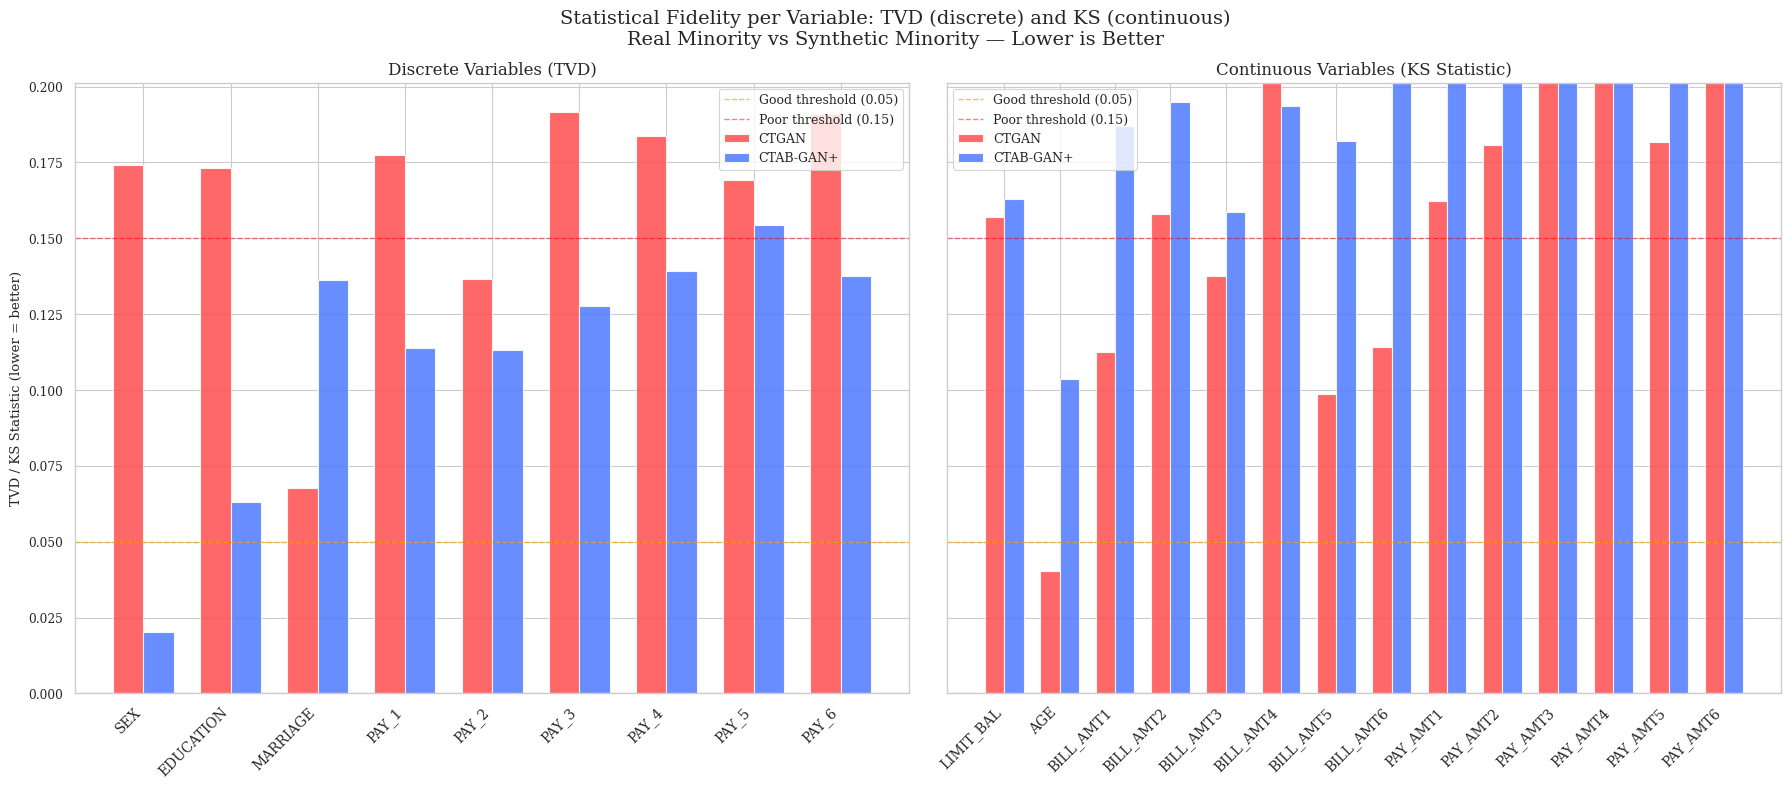

Figure saved: figures/fidelity_tvd_ks_per_variable.png


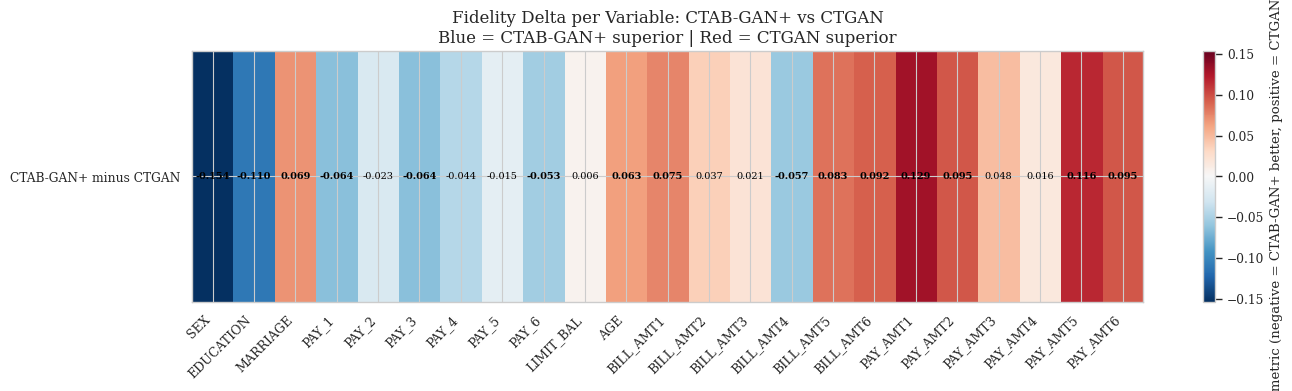

Figure saved: figures/fidelity_delta_heatmap.png


In [67]:
# ==============================================================================
# 6.5 — UNIFIED FIDELITY HEATMAP
# Reproduces the observation from your advisor: MARRIAGE TVD difference
# between CTGAN and CTAB-GAN+, now extended to ALL variables.
# ==============================================================================

# Build summary DataFrame
summary_data = []
for col in ALL_FEATURE_COLS:
    ctgan_val = results_ctgan[col]["value"]
    ctab_val  = results_ctab[col]["value"]
    metric    = results_ctgan[col]["metric"]
    col_type  = results_ctgan[col]["col_type"]
    summary_data.append({
        "Variable":    col,
        "Type":        col_type,
        "Metric":      metric,
        "CTGAN":       ctgan_val,
        "CTAB-GAN+":   ctab_val,
        "Difference":  ctab_val - ctgan_val,  # negative = CTAB-GAN+ is better
    })

fidelity_df = pd.DataFrame(summary_data).set_index("Variable")

print("\n" + "="*70)
print("UNIFIED FIDELITY SUMMARY (TVD for discrete, KS for continuous)")
print("="*70)
print(fidelity_df[["Metric", "CTGAN", "CTAB-GAN+", "Difference"]].round(4))

# --- Plot: Side-by-side bar chart ---
fig, axes = plt.subplots(1, 2, figsize=(18, 8), sharey=True)
fig.suptitle(
    "Statistical Fidelity per Variable: TVD (discrete) and KS (continuous)\n"
    "Real Minority vs Synthetic Minority — Lower is Better",
    fontsize=14
)

# Split by metric type for clarity
discrete_df   = fidelity_df[fidelity_df["Metric"] == "TVD"].copy()
continuous_df = fidelity_df[fidelity_df["Metric"] == "KS"].copy()

# Discrete (TVD)
x_d = np.arange(len(discrete_df))
width = 0.35
axes[0].bar(x_d - width/2, discrete_df["CTGAN"],     width, label="CTGAN",     color="#FF4D4D",  alpha=0.85)
axes[0].bar(x_d + width/2, discrete_df["CTAB-GAN+"], width, label="CTAB-GAN+", color="#4D79FF",  alpha=0.85)
axes[0].axhline(0.05,  color="orange", linestyle="--", linewidth=1, alpha=0.7, label="Good threshold (0.05)")
axes[0].axhline(0.15,  color="red",    linestyle="--", linewidth=1, alpha=0.5, label="Poor threshold (0.15)")
axes[0].set_xticks(x_d)
axes[0].set_xticklabels(discrete_df.index, rotation=45, ha="right", fontsize=10)
axes[0].set_title("Discrete Variables (TVD)", fontsize=12)
axes[0].set_ylabel("TVD / KS Statistic (lower = better)")
axes[0].legend(fontsize=9)
axes[0].set_ylim(0, None)

# Continuous (KS)
x_c = np.arange(len(continuous_df))
axes[1].bar(x_c - width/2, continuous_df["CTGAN"],     width, label="CTGAN",     color="#FF4D4D",  alpha=0.85)
axes[1].bar(x_c + width/2, continuous_df["CTAB-GAN+"], width, label="CTAB-GAN+", color="#4D79FF",  alpha=0.85)
axes[1].axhline(0.05,  color="orange", linestyle="--", linewidth=1, alpha=0.7, label="Good threshold (0.05)")
axes[1].axhline(0.15,  color="red",    linestyle="--", linewidth=1, alpha=0.5, label="Poor threshold (0.15)")
axes[1].set_xticks(x_c)
axes[1].set_xticklabels(continuous_df.index, rotation=45, ha="right", fontsize=10)
axes[1].set_title("Continuous Variables (KS Statistic)", fontsize=12)
axes[1].legend(fontsize=9)
axes[1].set_ylim(0, None)

plt.tight_layout()
plt.savefig("figures/fidelity_tvd_ks_per_variable.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figure saved: figures/fidelity_tvd_ks_per_variable.png")


# --- Plot: Delta heatmap (CTAB-GAN+ minus CTGAN — negative = CTAB-GAN+ better) ---
fig2, ax2 = plt.subplots(figsize=(14, 4))
delta_vals = fidelity_df["Difference"].values.reshape(1, -1)
im = ax2.imshow(delta_vals, cmap="RdBu_r", aspect="auto",
                vmin=-max(abs(fidelity_df["Difference"])),
                vmax=max(abs(fidelity_df["Difference"])))
ax2.set_xticks(np.arange(len(fidelity_df)))
ax2.set_xticklabels(fidelity_df.index, rotation=45, ha="right", fontsize=9)
ax2.set_yticks([0])
ax2.set_yticklabels(["CTAB-GAN+ minus CTGAN"])
plt.colorbar(im, ax=ax2, label="Δ metric (negative = CTAB-GAN+ better, positive = CTGAN better)")
ax2.set_title("Fidelity Delta per Variable: CTAB-GAN+ vs CTGAN\n"
              "Blue = CTAB-GAN+ superior | Red = CTGAN superior", fontsize=12)

# Annotate with values
for i, (col, row) in enumerate(fidelity_df.iterrows()):
    ax2.text(i, 0, f"{row['Difference']:.3f}", ha="center", va="center",
             fontsize=7, color="black",
             fontweight="bold" if abs(row["Difference"]) > 0.05 else "normal")

plt.tight_layout()
plt.savefig("figures/fidelity_delta_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figure saved: figures/fidelity_delta_heatmap.png")


DETAILED CATEGORICAL / ORDINAL DISTRIBUTION COMPARISONS


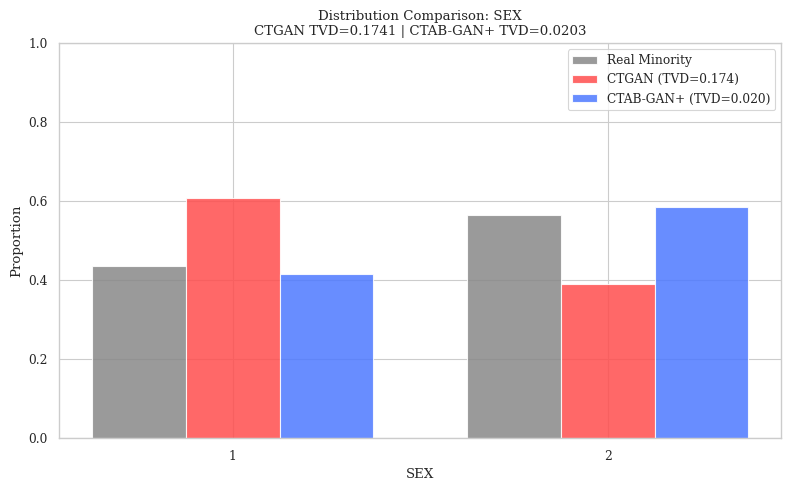

  Saved: distribution_SEX.png


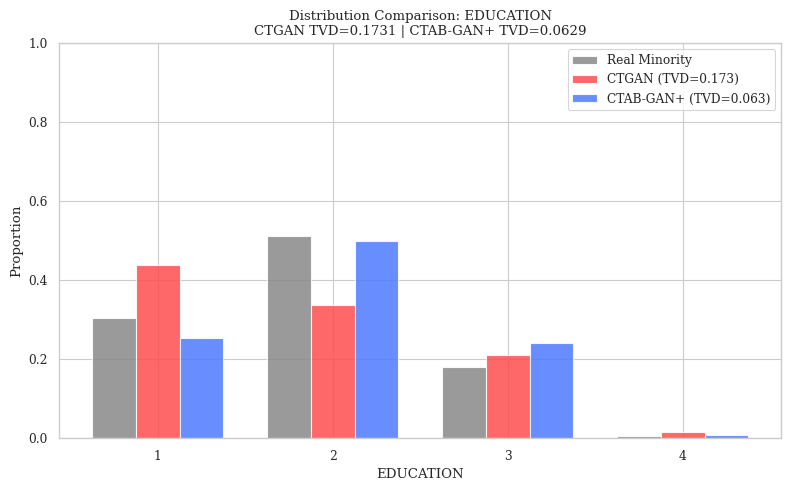

  Saved: distribution_EDUCATION.png


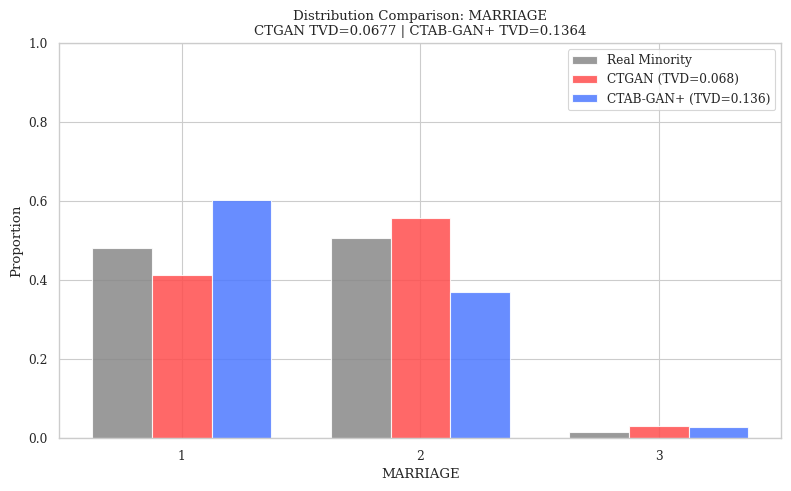

  Saved: distribution_MARRIAGE.png


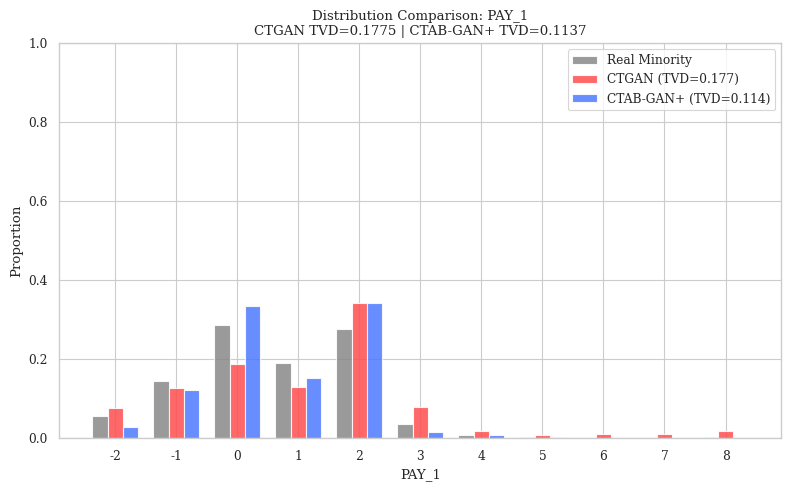

  Saved: distribution_PAY_1.png


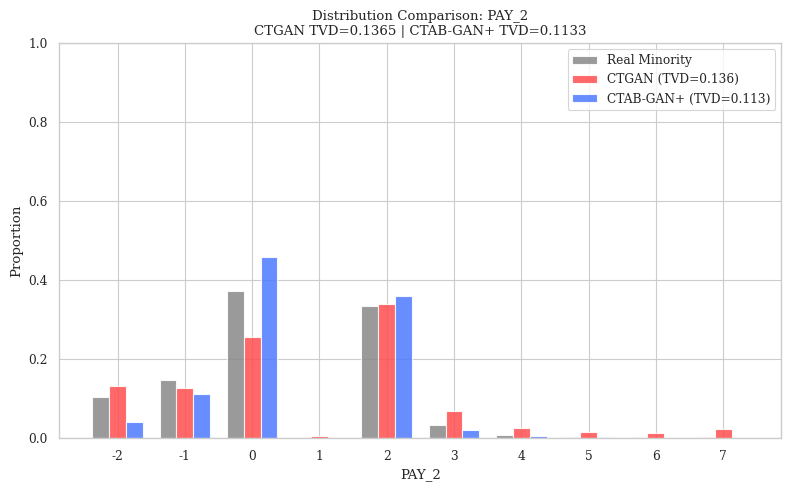

  Saved: distribution_PAY_2.png


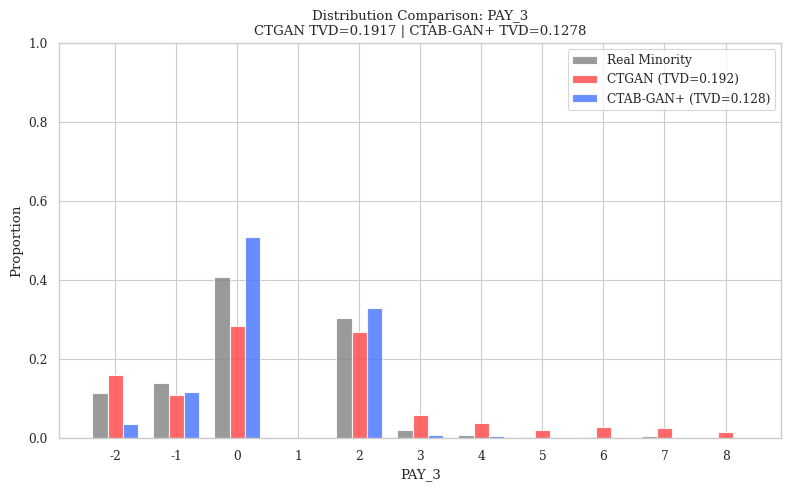

  Saved: distribution_PAY_3.png


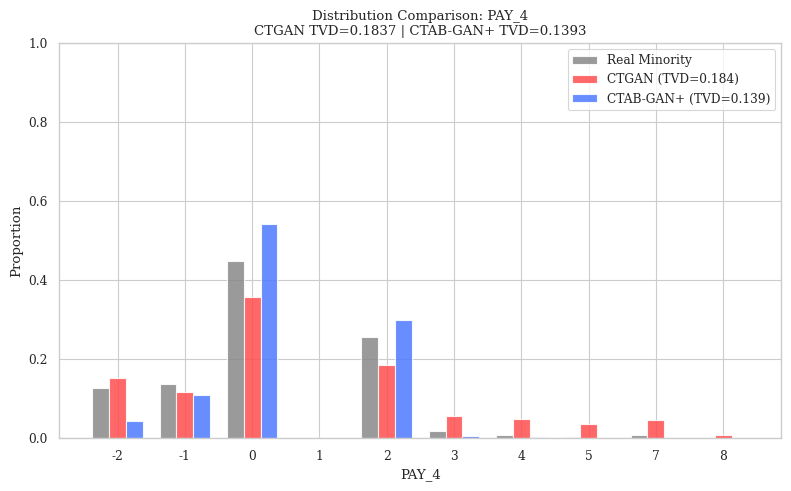

  Saved: distribution_PAY_4.png


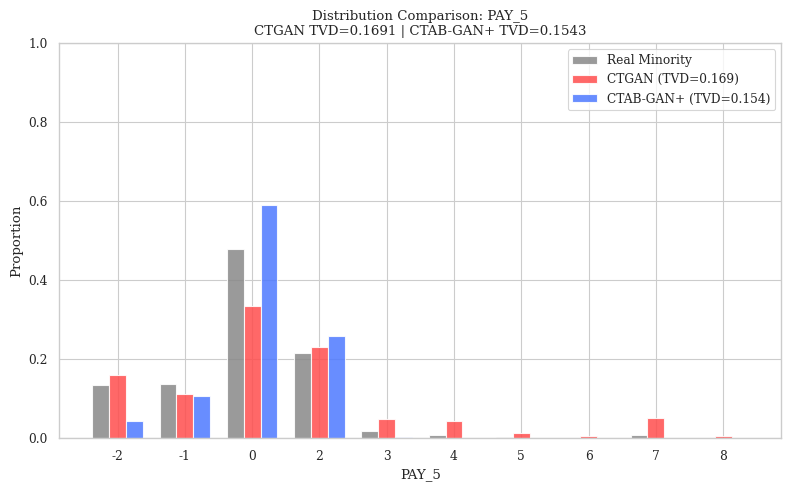

  Saved: distribution_PAY_5.png


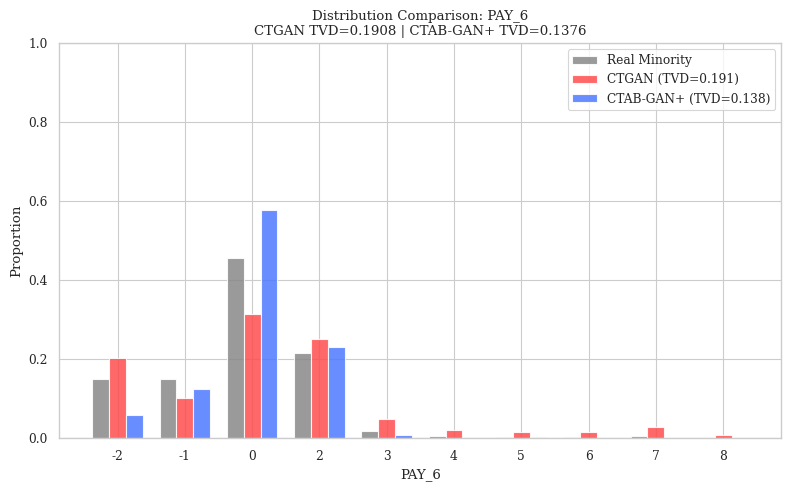

  Saved: distribution_PAY_6.png


In [68]:
# ==============================================================================
# 6.6 — CATEGORICAL DISTRIBUTION COMPARISON (DETAILED)
# This is the specific analysis your advisor requested:
# comparing MARRIAGE distributions explicitly, now extended to ALL categoricals.
# ==============================================================================

def plot_categorical_comparison(col, real_data, ctgan_data, ctab_data):
    """
    Side-by-side bar chart comparing real vs CTGAN vs CTAB-GAN+ for one column.
    Includes TVD values in the title.
    """
    tvd_ctgan, _ = compute_tvd(real_data[col].astype(int),
                                ctgan_data[col].astype(int))
    tvd_ctab, _  = compute_tvd(real_data[col].astype(int),
                                ctab_data[col].astype(int))

    all_cats = sorted(set(real_data[col].unique()) |
                      set(ctgan_data[col].unique()) |
                      set(ctab_data[col].unique()))

    real_props  = real_data[col].value_counts(normalize=True).reindex(all_cats, fill_value=0)
    ctgan_props = ctgan_data[col].value_counts(normalize=True).reindex(all_cats, fill_value=0)
    ctab_props  = ctab_data[col].value_counts(normalize=True).reindex(all_cats, fill_value=0)

    x = np.arange(len(all_cats))
    w = 0.25

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.bar(x - w,   real_props.values,  w, label="Real Minority", color="#888888", alpha=0.85)
    ax.bar(x,       ctgan_props.values, w, label=f"CTGAN (TVD={tvd_ctgan:.3f})",
           color="#FF4D4D", alpha=0.85)
    ax.bar(x + w,   ctab_props.values,  w, label=f"CTAB-GAN+ (TVD={tvd_ctab:.3f})",
           color="#4D79FF", alpha=0.85)

    ax.set_xticks(x)
    ax.set_xticklabels([str(c) for c in all_cats])
    ax.set_xlabel(col)
    ax.set_ylabel("Proportion")
    ax.set_title(f"Distribution Comparison: {col}\n"
                 f"CTGAN TVD={tvd_ctgan:.4f} | CTAB-GAN+ TVD={tvd_ctab:.4f}")
    ax.legend()
    ax.set_ylim(0, 1)
    plt.tight_layout()
    plt.savefig(f"figures/distribution_{col}.png", dpi=150, bbox_inches="tight")
    plt.show()
    print(f"  Saved: distribution_{col}.png")

print("\n" + "="*70)
print("DETAILED CATEGORICAL / ORDINAL DISTRIBUTION COMPARISONS")
print("="*70)

# Generate individual plots for categorical and ordinal columns
for col in CATEGORICAL_COLS + ORDINAL_COLS:
    plot_categorical_comparison(
        col,
        train_minority_raw,
        synthetic_ctgan,
        synthetic_ctab
    )


PRE-AUDIT: HE ET AL. (2025) 7-PROPERTY FRAMEWORK

[Property 1] PROXIMITY — Mean nearest-neighbor distance to real data
  CTGAN   — Mean proximity distance: 2.4641 ± 1.7023
  CTAB-GAN+ — Mean proximity distance: 1.5582 ± 1.3655
  (Lower = synthetic records are closer to real records = better)

[Property 2] SPARSITY — Out-of-distribution detection
  95th percentile of real-to-real NN distance: 2.4351
  CTGAN    — OOD rate (>P95 real-real distance): 45.93%
  CTAB-GAN+ — OOD rate (>P95 real-real distance): 16.36%
  (Lower = synthetic records stay within the real data manifold = better)

[Property 5] IMMUTABILITY — Demographic stability audit

  SEX:
    Real proportions:      {1: 0.43487621097954793, 2: 0.5651237890204521}
    CTGAN proportions:     {1: 0.6089666951323655, 2: 0.3910333048676345} | TVD=0.1741
    CTAB-GAN+ proportions: {1: 0.414602903501281, 2: 0.5853970964987191} | TVD=0.0203

  EDUCATION:
    Real proportions:      {1: 0.3039827771797632, 2: 0.5104413347685683, 3: 0.1799

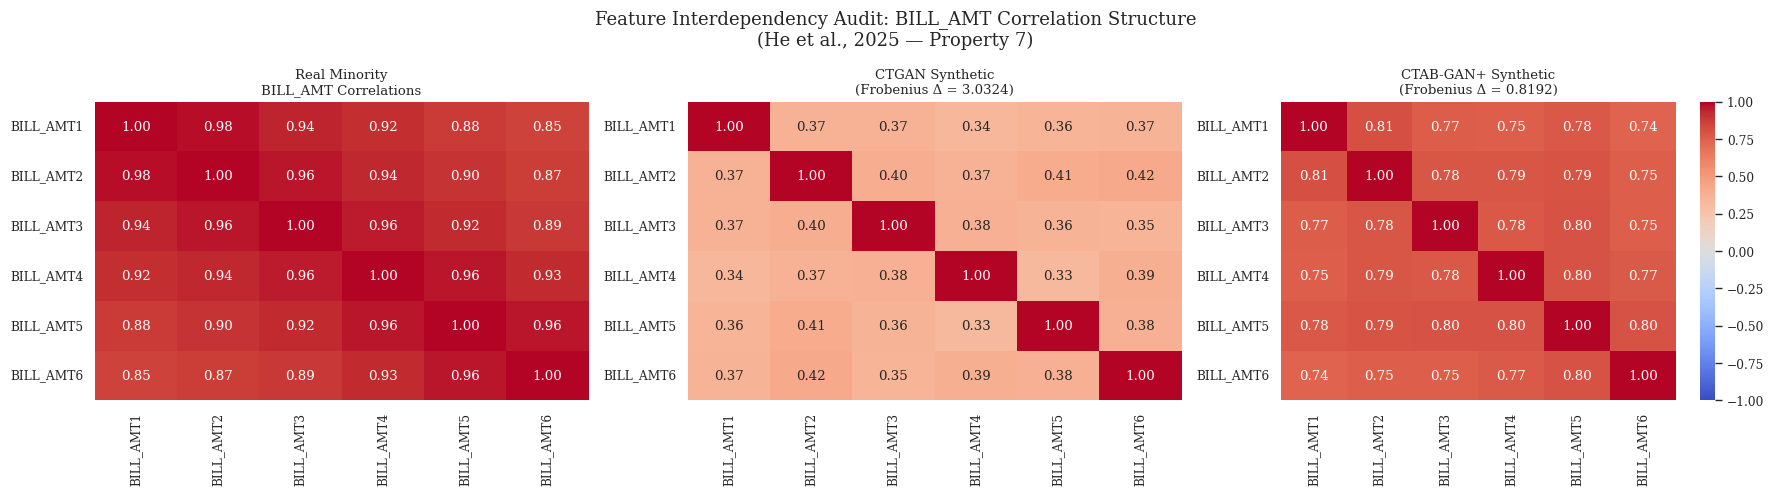

Figure saved: figures/interdependency_correlation_audit.png

[Properties 3 & 4] DEVIATION and SENSITIVITY

  Deviation (mean |z-score| across all continuous features):
    CTGAN:     0.5372
    CTAB-GAN+: 0.6040

  Sensitivity (records with >3 features at |z|>2 simultaneously):
    CTGAN:     0.78%
    CTAB-GAN+: 8.22%
  (These records may look statistically implausible as a whole)


In [69]:
# ==============================================================================
# 6.7 — PRE-AUDIT FOR HE ET AL. (2025) 7 PROPERTIES
# This section prepares the data structures and metrics needed to evaluate
# the 7 imperceptibility properties defined in He et al. (2025).
#
# PROPERTIES:
#   Quantitative: (1) Proximity, (2) Sparsity, (3) Deviation, (4) Sensitivity
#   Qualitative:  (5) Immutability, (6) Feasibility, (7) Feature Interdependency
#
# This block computes the OBSERVABLE evidence for each property from your
# existing synthetic datasets. The qualitative properties require rule-based
# audit — the code below flags candidate violations for manual review.
# ==============================================================================

print("\n" + "="*70)
print("PRE-AUDIT: HE ET AL. (2025) 7-PROPERTY FRAMEWORK")
print("="*70)

# ──────────────────────────────────────────────────────────────────────────────
# PROPERTY 1 — PROXIMITY
# Definition: Synthetic records should be "close" to real records in feature space.
# Metric: Mean nearest-neighbor distance from each synthetic record to its
#         closest real record (in standardised space).
# ──────────────────────────────────────────────────────────────────────────────
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors

print("\n[Property 1] PROXIMITY — Mean nearest-neighbor distance to real data")

# Use only numeric features for distance computation
numeric_cols = CONTINUOUS_COLS + ORDINAL_COLS + ["AGE"]
numeric_cols = [c for c in numeric_cols if c in train_minority_raw.columns]

# Standardise for fair distance computation
scaler_prox = StandardScaler()
real_scaled  = scaler_prox.fit_transform(train_minority_raw[numeric_cols].astype(float))
ctgan_scaled = scaler_prox.transform(synthetic_ctgan[numeric_cols].astype(float))
ctab_scaled  = scaler_prox.transform(synthetic_ctab[numeric_cols].astype(float))

# Fit NN on real data
nbrs = NearestNeighbors(n_neighbors=1, metric="euclidean")
nbrs.fit(real_scaled)

dist_ctgan, _ = nbrs.kneighbors(ctgan_scaled)
dist_ctab,  _ = nbrs.kneighbors(ctab_scaled)

print(f"  CTGAN   — Mean proximity distance: {dist_ctgan.mean():.4f} ± {dist_ctgan.std():.4f}")
print(f"  CTAB-GAN+ — Mean proximity distance: {dist_ctab.mean():.4f} ± {dist_ctab.std():.4f}")
print(f"  (Lower = synthetic records are closer to real records = better)")


# ──────────────────────────────────────────────────────────────────────────────
# PROPERTY 2 — SPARSITY
# Definition: Synthetic records should not cluster in sparse regions of the
#             real data manifold (out-of-distribution samples).
# Metric: Proportion of synthetic records whose NN distance exceeds
#         the 95th percentile of real-to-real distances.
# ──────────────────────────────────────────────────────────────────────────────
print("\n[Property 2] SPARSITY — Out-of-distribution detection")

# Real-to-real distances (leave-one-out)
nbrs_r2r = NearestNeighbors(n_neighbors=2, metric="euclidean")
nbrs_r2r.fit(real_scaled)
dist_r2r, _ = nbrs_r2r.kneighbors(real_scaled)  # col 0 = self (dist=0), col 1 = NN
dist_r2r = dist_r2r[:, 1]  # exclude self

threshold_95 = np.percentile(dist_r2r, 95)
print(f"  95th percentile of real-to-real NN distance: {threshold_95:.4f}")

ood_ctgan = (dist_ctgan[:, 0] > threshold_95).mean()
ood_ctab  = (dist_ctab[:, 0] > threshold_95).mean()
print(f"  CTGAN    — OOD rate (>P95 real-real distance): {ood_ctgan:.2%}")
print(f"  CTAB-GAN+ — OOD rate (>P95 real-real distance): {ood_ctab:.2%}")
print(f"  (Lower = synthetic records stay within the real data manifold = better)")


# ──────────────────────────────────────────────────────────────────────────────
# PROPERTY 5 — IMMUTABILITY
# Definition: Fixed demographic attributes should not show implausible
#             distributions. For this dataset: SEX is binary (1/2 only),
#             EDUCATION has 4 valid categories, MARRIAGE has 3.
# Metric: Post-correction, these should be 0 violations (already verified).
#         We compute the Gini impurity as a proxy for whether the synthetic
#         model produces a reasonable demographic profile.
# ──────────────────────────────────────────────────────────────────────────────
print("\n[Property 5] IMMUTABILITY — Demographic stability audit")

for col in ["SEX", "EDUCATION", "MARRIAGE"]:
    real_d  = train_minority_raw[col].value_counts(normalize=True).sort_index()
    ctgan_d = synthetic_ctgan[col].value_counts(normalize=True).sort_index()
    ctab_d  = synthetic_ctab[col].value_counts(normalize=True).sort_index()

    # Re-use TVD already computed
    tvd_cg, _ = compute_tvd(
        train_minority_raw[col].astype(int),
        synthetic_ctgan[col].astype(int)
    )
    tvd_ct, _ = compute_tvd(
        train_minority_raw[col].astype(int),
        synthetic_ctab[col].astype(int)
    )
    print(f"\n  {col}:")
    print(f"    Real proportions:      {real_d.to_dict()}")
    print(f"    CTGAN proportions:     {ctgan_d.to_dict()} | TVD={tvd_cg:.4f}")
    print(f"    CTAB-GAN+ proportions: {ctab_d.to_dict()} | TVD={tvd_ct:.4f}")


# ──────────────────────────────────────────────────────────────────────────────
# PROPERTY 6 — FEASIBILITY
# Definition: Synthesised feature values must not violate valid practical ranges.
# Already audited in the post-generation validation step.
# Here we produce a QUANTITATIVE summary table for the thesis.
# ──────────────────────────────────────────────────────────────────────────────
print("\n[Property 6] FEASIBILITY — Domain range compliance summary")

feasibility_checks = {
    "AGE in [18, 100]": {
        "CTGAN":    ((synthetic_ctgan["AGE"] >= 18) & (synthetic_ctgan["AGE"] <= 100)).mean(),
        "CTAB-GAN+": ((synthetic_ctab["AGE"] >= 18) & (synthetic_ctab["AGE"] <= 100)).mean(),
    },
    "LIMIT_BAL > 0": {
        "CTGAN":    (synthetic_ctgan["LIMIT_BAL"] > 0).mean(),
        "CTAB-GAN+": (synthetic_ctab["LIMIT_BAL"] > 0).mean(),
    },
    "PAY_AMT1 >= 0": {
        "CTGAN":    (synthetic_ctgan["PAY_AMT1"] >= 0).mean(),
        "CTAB-GAN+": (synthetic_ctab["PAY_AMT1"] >= 0).mean(),
    },
    "PAY_AMT4 >= 0": {
        "CTGAN":    (synthetic_ctgan["PAY_AMT4"] >= 0).mean(),
        "CTAB-GAN+": (synthetic_ctab["PAY_AMT4"] >= 0).mean(),
    },
    "PAY_AMT6 >= 0": {
        "CTGAN":    (synthetic_ctgan["PAY_AMT6"] >= 0).mean(),
        "CTAB-GAN+": (synthetic_ctab["PAY_AMT6"] >= 0).mean(),
    },
    "PAY_1 in [-2, 8]": {
        "CTGAN":    synthetic_ctgan["PAY_1"].between(-2, 8).mean(),
        "CTAB-GAN+": synthetic_ctab["PAY_1"].between(-2, 8).mean(),
    },
}

print("\n  Feasibility Compliance (POST-CORRECTION — should be 1.000):")
feasibility_df = pd.DataFrame(feasibility_checks).T
print(feasibility_df.round(4))

print("\n  NOTE: Post-correction figures are after domain-guided clipping.")
print("  Pre-correction violations were documented in Chapter 5 (Section 5.2.2 and 5.3.4).")


# ──────────────────────────────────────────────────────────────────────────────
# PROPERTY 7 — FEATURE INTERDEPENDENCY
# Definition: Derived or logically related variables must remain consistent.
# For this dataset, the key interdependency is:
#   PAY_AMT_x should generally not exceed BILL_AMT_x (you can't pay more than billed
#   without a credit or advance payment — rare but possible).
#   A more robust check: correlation structure between billing sequence variables
#   should be preserved (BILL_AMT1-6 are highly correlated in real data).
# ──────────────────────────────────────────────────────────────────────────────
print("\n[Property 7] FEATURE INTERDEPENDENCY — Correlation structure preservation")

bill_cols = ["BILL_AMT1", "BILL_AMT2", "BILL_AMT3",
             "BILL_AMT4", "BILL_AMT5", "BILL_AMT6"]

real_corr  = train_minority_raw[bill_cols].corr()
ctgan_corr = synthetic_ctgan[bill_cols].astype(float).corr()
ctab_corr  = synthetic_ctab[bill_cols].astype(float).corr()

# Frobenius norm of difference as a single scalar
frob_ctgan = np.linalg.norm(real_corr.values - ctgan_corr.values, "fro")
frob_ctab  = np.linalg.norm(real_corr.values - ctab_corr.values,  "fro")

print(f"\n  BILL_AMT correlation matrix — Frobenius norm of difference vs real:")
print(f"    CTGAN:     {frob_ctgan:.4f}")
print(f"    CTAB-GAN+: {frob_ctab:.4f}")
print(f"  (Lower = synthetic preserves the correlation structure of billing amounts)")

# --- Plot: Correlation matrix comparison ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
vmin, vmax = -1, 1

sns.heatmap(real_corr,  annot=True, fmt=".2f", cmap="coolwarm",
            vmin=vmin, vmax=vmax, ax=axes[0], cbar=False)
axes[0].set_title("Real Minority\nBILL_AMT Correlations")

sns.heatmap(ctgan_corr, annot=True, fmt=".2f", cmap="coolwarm",
            vmin=vmin, vmax=vmax, ax=axes[1], cbar=False)
axes[1].set_title(f"CTGAN Synthetic\n(Frobenius Δ = {frob_ctgan:.4f})")

sns.heatmap(ctab_corr,  annot=True, fmt=".2f", cmap="coolwarm",
            vmin=vmin, vmax=vmax, ax=axes[2])
axes[2].set_title(f"CTAB-GAN+ Synthetic\n(Frobenius Δ = {frob_ctab:.4f})")

plt.suptitle("Feature Interdependency Audit: BILL_AMT Correlation Structure\n"
             "(He et al., 2025 — Property 7)", fontsize=13)
plt.tight_layout()
plt.savefig("figures/interdependency_correlation_audit.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figure saved: figures/interdependency_correlation_audit.png")


# ──────────────────────────────────────────────────────────────────────────────
# PROPERTY 3 & 4 — DEVIATION and SENSITIVITY
# These properties are more relevant to adversarial example research
# (how much a change in one feature changes the prediction).
# For synthetic data evaluation, we adapt them as:
#   Deviation: mean z-score of synthetic records relative to real distribution
#   Sensitivity: how many features deviate by >2 sigma simultaneously
# ──────────────────────────────────────────────────────────────────────────────
print("\n[Properties 3 & 4] DEVIATION and SENSITIVITY")

mean_real = train_minority_raw[CONTINUOUS_COLS].astype(float).mean()
std_real  = train_minority_raw[CONTINUOUS_COLS].astype(float).std()

# Z-scores of synthetic records relative to real distribution
z_ctgan = ((synthetic_ctgan[CONTINUOUS_COLS].astype(float) - mean_real) / (std_real + 1e-8)).abs()
z_ctab  = ((synthetic_ctab[CONTINUOUS_COLS].astype(float) - mean_real) / (std_real + 1e-8)).abs()

print(f"\n  Deviation (mean |z-score| across all continuous features):")
print(f"    CTGAN:     {z_ctgan.values.mean():.4f}")
print(f"    CTAB-GAN+: {z_ctab.values.mean():.4f}")

# Sensitivity: records with >3 features deviating by >2 sigma
outlier_ctgan = (z_ctgan > 2).sum(axis=1)
outlier_ctab  = (z_ctab > 2).sum(axis=1)

print(f"\n  Sensitivity (records with >3 features at |z|>2 simultaneously):")
print(f"    CTGAN:     {(outlier_ctgan > 3).mean():.2%}")
print(f"    CTAB-GAN+: {(outlier_ctab > 3).mean():.2%}")
print(f"  (These records may look statistically implausible as a whole)")

In [70]:
# ==============================================================================
# 6.8 — FINAL SUMMARY TABLE FOR CHAPTER 6 TEXT
# ==============================================================================

print("\n" + "="*70)
print("FINAL SUMMARY TABLE — STATISTICAL FIDELITY + HE ET AL. PROPERTIES")
print("="*70)

summary_table = {
    "Metric": [
        "Mean TVD (categorical)",
        "Mean TVD (ordinal / PAY_X)",
        "Mean KS (continuous)",
        "Proximity (mean NN dist)",
        "Sparsity (OOD rate)",
        "Correlation Frobenius Δ",
        "Mean |z-score| deviation",
        "High-sensitivity rate",
    ],
    "CTGAN": [
        fidelity_df[fidelity_df["Type"]=="categorical"]["CTGAN"].mean(),
        fidelity_df[fidelity_df["Type"]=="ordinal"]["CTGAN"].mean(),
        fidelity_df[fidelity_df["Type"]=="continuous"]["CTGAN"].mean(),
        dist_ctgan.mean(),
        ood_ctgan,
        frob_ctgan,
        z_ctgan.values.mean(),
        (outlier_ctgan > 3).mean(),
    ],
    "CTAB-GAN+": [
        fidelity_df[fidelity_df["Type"]=="categorical"]["CTAB-GAN+"].mean(),
        fidelity_df[fidelity_df["Type"]=="ordinal"]["CTAB-GAN+"].mean(),
        fidelity_df[fidelity_df["Type"]=="continuous"]["CTAB-GAN+"].mean(),
        dist_ctab.mean(),
        ood_ctab,
        frob_ctab,
        z_ctab.values.mean(),
        (outlier_ctab > 3).mean(),
    ],
}

summary_out = pd.DataFrame(summary_table).set_index("Metric")
print(summary_out.round(4))
print("\nNOTE: For Proximity, Sparsity, KS, and deviation — lower is better.")
print("For Correlation Frobenius Δ — lower is better.")


FINAL SUMMARY TABLE — STATISTICAL FIDELITY + HE ET AL. PROPERTIES
                             CTGAN  CTAB-GAN+
Metric                                       
Mean TVD (categorical)      0.1383     0.0732
Mean TVD (ordinal / PAY_X)  0.1749     0.1310
Mean KS (continuous)        0.1675     0.2261
Proximity (mean NN dist)    2.4641     1.5582
Sparsity (OOD rate)         0.4593     0.1636
Correlation Frobenius Δ     3.0324     0.8192
Mean |z-score| deviation    0.5372     0.6040
High-sensitivity rate       0.0078     0.0822

NOTE: For Proximity, Sparsity, KS, and deviation — lower is better.
For Correlation Frobenius Δ — lower is better.


In [71]:
"""
================================================================================
  CHAPTER 6 — ADDITIONAL ANALYSIS 
================================================================================
  Block A: Sensitivity investigation — which features drive the CTAB-GAN+ outlier records
  Block B: KDE density plots for PAY_AMT and BILL_AMT key variables
================================================================================
"""

'\n================================================================================\n  CHAPTER 6 — ADDITIONAL ANALYSIS \n================================================================================\n  Block A: Sensitivity investigation — which features drive the CTAB-GAN+ outlier records\n  Block B: KDE density plots for PAY_AMT and BILL_AMT key variables\n================================================================================\n'

In [72]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

BLOCK A — SENSITIVITY INVESTIGATION (CTAB-GAN+ outlier records)

CTAB-GAN+ outlier records: 963 (8.2% of 11710 records)

Features most frequently >2σ in CTAB-GAN+ outlier records:
BILL_AMT5    0.795
BILL_AMT6    0.784
BILL_AMT4    0.779
BILL_AMT2    0.777
BILL_AMT1    0.744
BILL_AMT3    0.723
LIMIT_BAL    0.457
PAY_AMT1     0.126
PAY_AMT6     0.125
PAY_AMT2     0.085
PAY_AMT5     0.084
PAY_AMT3     0.077
AGE          0.048
PAY_AMT4     0.048

CTGAN outlier records: 91 (0.8% of 11710 records)

Features most frequently >2σ in CTGAN outlier records:
BILL_AMT2    0.758
BILL_AMT6    0.747
BILL_AMT5    0.670
BILL_AMT3    0.560
BILL_AMT1    0.527
BILL_AMT4    0.352
AGE          0.253
PAY_AMT6     0.077
LIMIT_BAL    0.044
PAY_AMT2     0.044
PAY_AMT4     0.033
PAY_AMT1     0.022
PAY_AMT3     0.022
PAY_AMT5     0.022


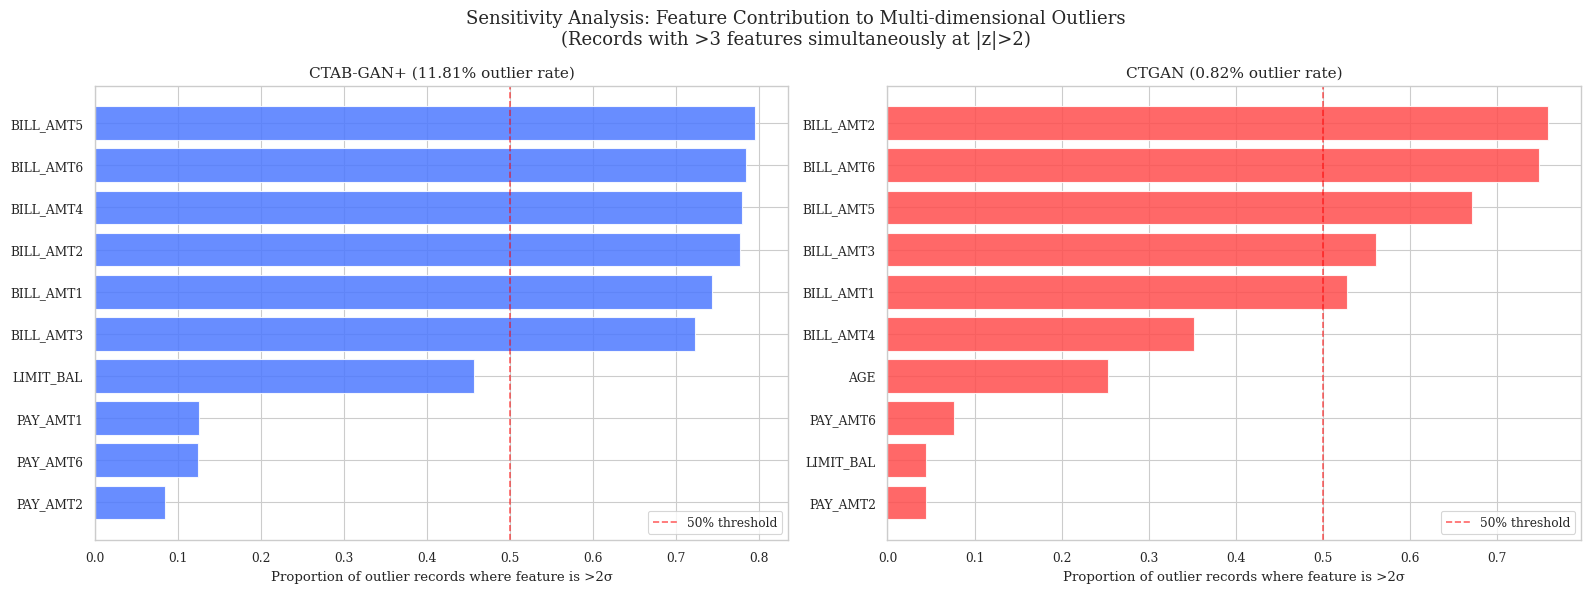

Figure saved: figures/sensitivity_feature_analysis.png

--- INTERPRETATION ---
If PAY_AMT features dominate the CTAB-GAN+ outlier list, this suggests
the generator occasionally synthesises extreme payment amount records.
Given that PAY_AMT KS scores are also comparatively high, this is consistent
with CTAB-GAN+ having more difficulty with the heavy-tailed PAY_AMT distributions.


In [73]:
# ==============================================================================
# BLOCK A — Sensitivity investigation
# Which features contribute most to CTAB-GAN+'s outlier records?
# ==============================================================================

print("=" * 70)
print("BLOCK A — SENSITIVITY INVESTIGATION (CTAB-GAN+ outlier records)")
print("=" * 70)

mean_real = train_minority_raw[CONTINUOUS_COLS].astype(float).mean()
std_real  = train_minority_raw[CONTINUOUS_COLS].astype(float).std()

z_ctgan = ((synthetic_ctgan[CONTINUOUS_COLS].astype(float) - mean_real) / (std_real + 1e-8)).abs()
z_ctab  = ((synthetic_ctab[CONTINUOUS_COLS].astype(float) - mean_real) / (std_real + 1e-8)).abs()

outlier_mask_ctab = (z_ctab > 2).sum(axis=1) > 3

print(f"\nCTAB-GAN+ outlier records: {outlier_mask_ctab.sum()} "
      f"({outlier_mask_ctab.mean():.1%} of {len(synthetic_ctab)} records)")

# Which features are most often extreme in these outlier records?
outlier_features_ctab = (z_ctab[outlier_mask_ctab] > 2).mean().sort_values(ascending=False)
print("\nFeatures most frequently >2σ in CTAB-GAN+ outlier records:")
print(outlier_features_ctab.round(3).to_string())

# Same analysis for CTGAN
outlier_mask_ctgan = (z_ctgan > 2).sum(axis=1) > 3
print(f"\nCTGAN outlier records: {outlier_mask_ctgan.sum()} "
      f"({outlier_mask_ctgan.mean():.1%} of {len(synthetic_ctgan)} records)")
outlier_features_ctgan = (z_ctgan[outlier_mask_ctgan] > 2).mean().sort_values(ascending=False)
print("\nFeatures most frequently >2σ in CTGAN outlier records:")
print(outlier_features_ctgan.round(3).to_string())

# --- Plot: Feature-level outlier frequency comparison ---
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Sensitivity Analysis: Feature Contribution to Multi-dimensional Outliers\n"
             "(Records with >3 features simultaneously at |z|>2)", fontsize=13)

# CTAB-GAN+
top_ctab = outlier_features_ctab.head(10)
axes[0].barh(top_ctab.index[::-1], top_ctab.values[::-1], color="#4D79FF", alpha=0.85)
axes[0].axvline(0.5, color="red", linestyle="--", alpha=0.6, label="50% threshold")
axes[0].set_title(f"CTAB-GAN+ ({outlier_mask_ctab.mean():.2%} outlier rate)", fontsize=11)
axes[0].set_xlabel("Proportion of outlier records where feature is >2σ")
axes[0].legend()

# CTGAN
if outlier_mask_ctgan.sum() > 0:
    top_ctgan = outlier_features_ctgan.head(10)
    axes[1].barh(top_ctgan.index[::-1], top_ctgan.values[::-1], color="#FF4D4D", alpha=0.85)
    axes[1].axvline(0.5, color="red", linestyle="--", alpha=0.6, label="50% threshold")
    axes[1].set_title(f"CTGAN ({outlier_mask_ctgan.mean():.2%} outlier rate)", fontsize=11)
    axes[1].set_xlabel("Proportion of outlier records where feature is >2σ")
    axes[1].legend()
else:
    axes[1].text(0.5, 0.5, "Too few outlier records\nfor reliable feature analysis",
                 ha="center", va="center", fontsize=12, color="gray",
                 transform=axes[1].transAxes)
    axes[1].set_title(f"CTGAN ({outlier_mask_ctgan.mean():.2%} outlier rate, insufficient for analysis)")

plt.tight_layout()
plt.savefig("figures/sensitivity_feature_analysis.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figure saved: figures/sensitivity_feature_analysis.png")

# Interpretation note
print("\n--- INTERPRETATION ---")
print("If PAY_AMT features dominate the CTAB-GAN+ outlier list, this suggests")
print("the generator occasionally synthesises extreme payment amount records.")
print("Given that PAY_AMT KS scores are also comparatively high, this is consistent")
print("with CTAB-GAN+ having more difficulty with the heavy-tailed PAY_AMT distributions.")


BLOCK B — KDE DENSITY PLOTS (key continuous variables)


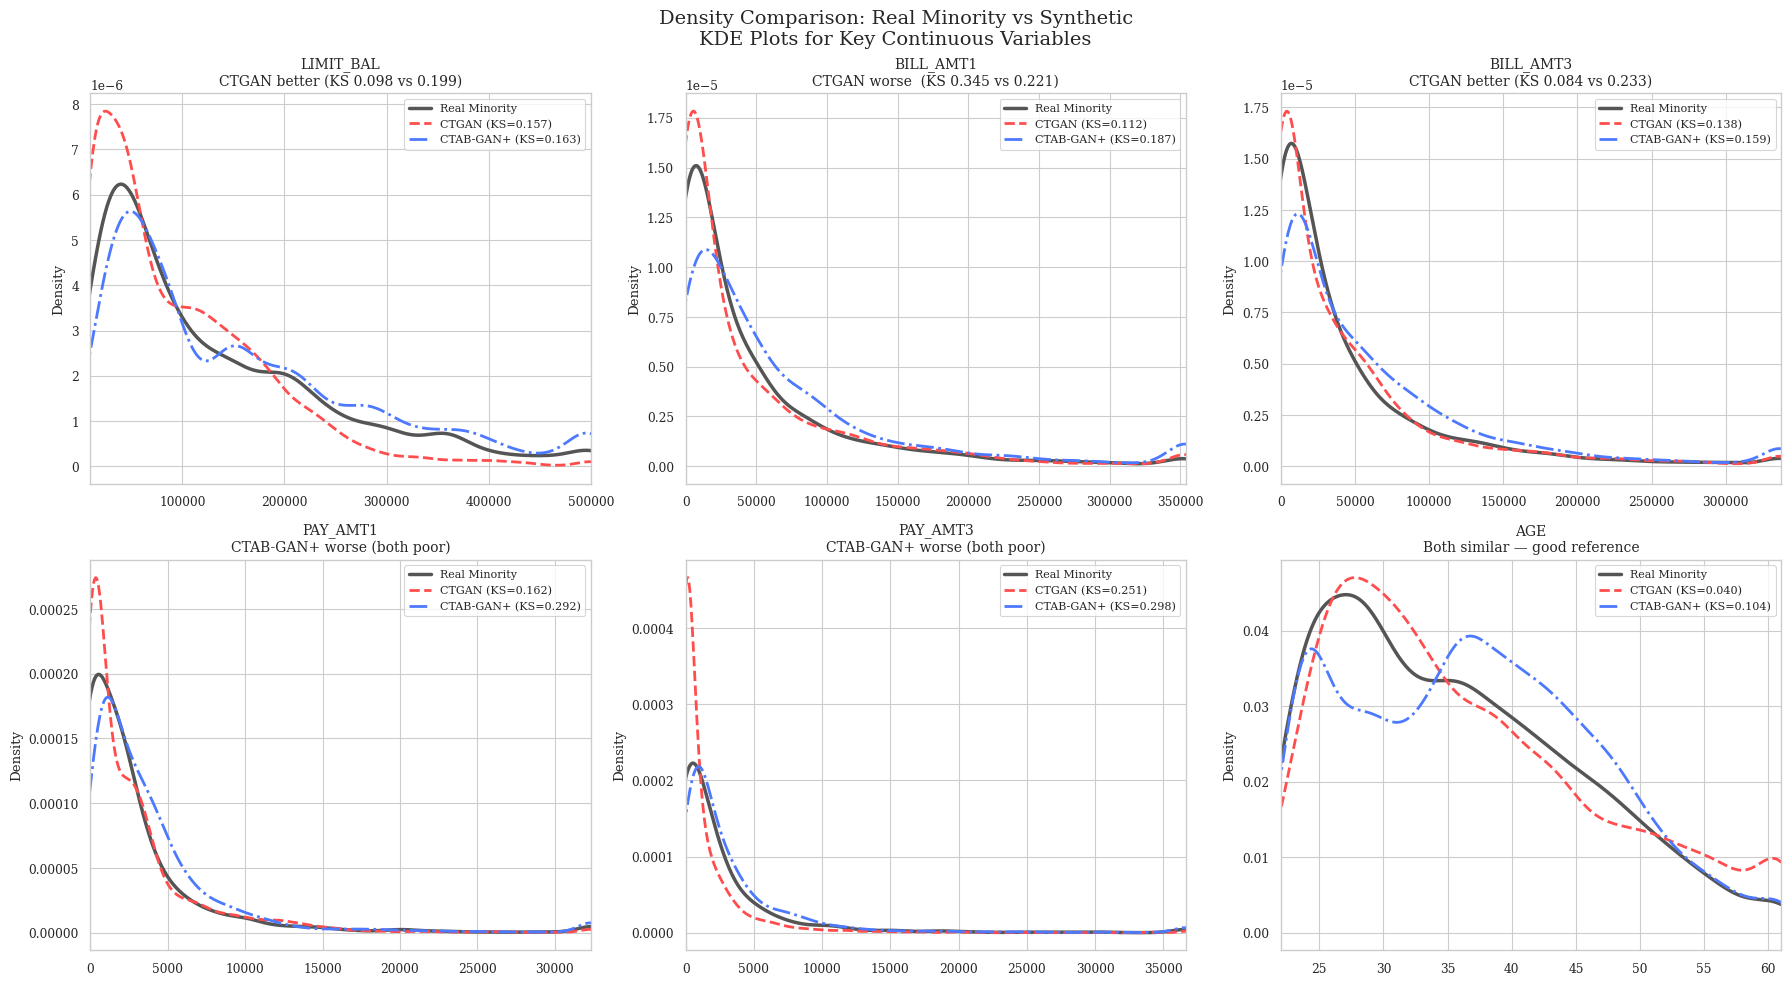

Figure saved: figures/kde_continuous_variables.png


In [74]:
# ==============================================================================
# BLOCK B — KDE Density Plots for key continuous variables
# Focus on the variables with the most divergent KS scores
# ==============================================================================

print("\n" + "=" * 70)
print("BLOCK B — KDE DENSITY PLOTS (key continuous variables)")
print("=" * 70)

# Select the 6 most informative variables based on KS divergence pattern
key_continuous = [
    ("LIMIT_BAL",  "CTGAN better (KS 0.098 vs 0.199)"),
    ("BILL_AMT1",  "CTGAN worse  (KS 0.345 vs 0.221)"),
    ("BILL_AMT3",  "CTGAN better (KS 0.084 vs 0.233)"),
    ("PAY_AMT1",   "CTAB-GAN+ worse (both poor)"),
    ("PAY_AMT3",   "CTAB-GAN+ worse (both poor)"),
    ("AGE",        "Both similar — good reference"),
]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle("Density Comparison: Real Minority vs Synthetic\n"
             "KDE Plots for Key Continuous Variables", fontsize=14)

for idx, (col, note) in enumerate(key_continuous):
    row, c = divmod(idx, 3)
    ax = axes[row, c]

    # Clip extreme values for visualization clarity (keep 99th percentile)
    p99 = train_minority_raw[col].quantile(0.99)
    p01 = train_minority_raw[col].quantile(0.01)

    real_clipped  = train_minority_raw[col].clip(p01, p99).astype(float)
    ctgan_clipped = synthetic_ctgan[col].clip(p01, p99).astype(float)
    ctab_clipped  = synthetic_ctab[col].clip(p01, p99).astype(float)

    # KS values for annotation
    ks_cg = results_ctgan[col]["value"]
    ks_ct = results_ctab[col]["value"]

    real_clipped.plot.kde(ax=ax, color="#555555", linewidth=2.5, label="Real Minority")
    ctgan_clipped.plot.kde(ax=ax, color="#FF4D4D", linewidth=2,
                           linestyle="--", label=f"CTGAN (KS={ks_cg:.3f})")
    ctab_clipped.plot.kde(ax=ax, color="#4D79FF", linewidth=2,
                          linestyle="-.", label=f"CTAB-GAN+ (KS={ks_ct:.3f})")

    ax.set_title(f"{col}\n{note}", fontsize=10)
    ax.set_ylabel("Density")
    ax.legend(fontsize=8)
    ax.set_xlim(p01, p99)

plt.tight_layout()
plt.savefig("figures/kde_continuous_variables.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figure saved: figures/kde_continuous_variables.png")

In [76]:
# Pooling diagnostic
# Requires 'collected_minority' to still be in memory
for i, batch in enumerate(collected_minority):
    z_batch = ((batch[CONTINUOUS_COLS].astype(float) - mean_real) / (std_real + 1e-8)).abs()
    outlier_rate = ((z_batch > 2).sum(axis=1) > 3).mean()
    print(f"Batch {i+1}: {outlier_rate:.1%} outlier rate")

Batch 1: 8.2% outlier rate
Batch 2: 8.7% outlier rate
Batch 3: 7.5% outlier rate
Batch 4: 8.4% outlier rate


In [77]:
# Property 7 — extended to PAY_AMT
pay_amt_cols = ["PAY_AMT1", "PAY_AMT2", "PAY_AMT3", "PAY_AMT4", "PAY_AMT5", "PAY_AMT6"]

real_corr_p  = train_minority_raw[pay_amt_cols].corr()
ctgan_corr_p = synthetic_ctgan[pay_amt_cols].astype(float).corr()
ctab_corr_p  = synthetic_ctab[pay_amt_cols].astype(float).corr()

frob_ctgan_p = np.linalg.norm(real_corr_p.values - ctgan_corr_p.values, "fro")
frob_ctab_p  = np.linalg.norm(real_corr_p.values - ctab_corr_p.values, "fro")

print(f"PAY_AMT Frobenius Δ — CTGAN: {frob_ctgan_p:.4f} | CTAB-GAN+: {frob_ctab_p:.4f}")

PAY_AMT Frobenius Δ — CTGAN: 0.4436 | CTAB-GAN+: 0.3881


In [78]:
# Save datasets for use in external frameworks
train_minority_raw.to_csv("data/real_minority_train.csv", index=False)
synthetic_ctgan.to_csv("data/synthetic_ctgan_final.csv", index=False)
synthetic_ctab.to_csv("data/synthetic_ctab_final.csv", index=False)
train_data_full.to_csv("data/real_train_full.csv", index=False)

# Fully balanced dataset (real majority + synthetic minority) — for TSTR in FEST
import pandas as pd
balanced_ctgan_full = pd.concat([
    train_data_full,
    synthetic_ctgan
], ignore_index=True)
balanced_ctab_full = pd.concat([
    train_data_full,
    synthetic_ctab
], ignore_index=True)

balanced_ctgan_full.to_csv("data/balanced_ctgan_full.csv", index=False)
balanced_ctab_full.to_csv("data/balanced_ctab_full.csv", index=False)

print("Datasets saved:")
print(f"  real_minority_train.csv       : {len(train_minority_raw)} records")
print(f"  synthetic_ctgan_final.csv     : {len(synthetic_ctgan)} records")
print(f"  synthetic_ctab_final.csv      : {len(synthetic_ctab)} records")
print(f"  real_train_full.csv           : {len(train_data_full)} records")
print(f"  balanced_ctgan_full.csv       : {len(balanced_ctgan_full)} records")
print(f"  balanced_ctab_full.csv        : {len(balanced_ctab_full)} records")

Datasets saved:
  real_minority_train.csv       : 4645 records
  synthetic_ctgan_final.csv     : 11710 records
  synthetic_ctab_final.csv      : 11710 records
  real_train_full.csv           : 21000 records
  balanced_ctgan_full.csv       : 32710 records
  balanced_ctab_full.csv        : 32710 records


In [79]:
# Final type consistency check before passing data to external frameworks
print("=== TYPE CONSISTENCY CHECK ===")
for name, df in [("Real minority", train_minority_raw),
                  ("CTGAN synthetic", synthetic_ctgan),
                  ("CTAB-GAN+ synthetic", synthetic_ctab)]:
    print(f"\n{name}:")
    print(df.dtypes.to_string())
    print(f"  NaN count: {df.isna().sum().sum()}")
    print(f"  Shape: {df.shape}")

=== TYPE CONSISTENCY CHECK ===

Real minority:
LIMIT_BAL    float64
SEX            int64
EDUCATION      int64
MARRIAGE       int64
AGE            int64
PAY_1          int64
PAY_2          int64
PAY_3          int64
PAY_4          int64
PAY_5          int64
PAY_6          int64
BILL_AMT1    float64
BILL_AMT2    float64
BILL_AMT3    float64
BILL_AMT4    float64
BILL_AMT5    float64
BILL_AMT6    float64
PAY_AMT1     float64
PAY_AMT2     float64
PAY_AMT3     float64
PAY_AMT4     float64
PAY_AMT5     float64
PAY_AMT6     float64
def_pay        int64
  NaN count: 0
  Shape: (4645, 24)

CTGAN synthetic:
LIMIT_BAL    float64
SEX            int32
EDUCATION      int32
MARRIAGE       int32
AGE            int32
PAY_1          int32
PAY_2          int32
PAY_3          int32
PAY_4          int32
PAY_5          int32
PAY_6          int32
BILL_AMT1    float64
BILL_AMT2    float64
BILL_AMT3    float64
BILL_AMT4    float64
BILL_AMT5    float64
BILL_AMT6    float64
PAY_AMT1     float64
PAY_AMT2     float

## Chapter 7: Privacy Risk Assessment

| Section | Content |
|---------|----------|
| 7.1 | Privacy framework and metric definitions |
| 7.2 | DCR — Distance to Closest Record |
| 7.3 | NNDR — Nearest Neighbour Distance Ratio |
| 7.4 | Privacy risk classification |
| 7.5 | Consolidated privacy profile |

**Source for DCR and NNDR implementation:**  
SynthEval framework (Lautrup et al., 2025) — GitHub: https://github.com/schnjtk/SynthEval  
The metric definitions and thresholds follow the SynthEval documentation and the  
SDV (Synthetic Data Vault) privacy evaluation guide: https://docs.sdv.dev/sdmetrics/metrics/privacy-metrics

In [80]:
# ==============================================================================
# CHAPTER 7: PRIVACY RISK ASSESSMENT
# ==============================================================================
#
# This chapter evaluates the PRIVACY dimension of synthetic data quality —
# the third pillar of the multidimensional evaluation framework alongside
# statistical fidelity (Chapter 6) and ML utility (Chapter 5).
#
# MOTIVATION:
# Synthetic data is generated precisely to bypass privacy constraints.
# However, if the generator memorises individual training records, the
# synthetic data may inadvertently re-expose real clients — a critical
# violation for any GDPR-regulated financial institution.
#
# METRICS:
#   DCR  — Distance to Closest Record:
#           For each synthetic record, the distance to the nearest real
#           training record. A low DCR suggests the generator copied (or
#           nearly copied) a real individual — a privacy risk.
#
#   NNDR — Nearest Neighbour Distance Ratio:
#           For each synthetic record, the ratio of its distance to the
#           1st nearest real record vs. the 2nd nearest real record.
#           NNDR ≈ 1 means the synthetic record sits equidistant between
#           two real records — it interpolates and is less likely to be
#           a copy. NNDR << 1 means it is very close to exactly ONE real
#           record — a memorisation signal.
#
# IMPLEMENTATION SOURCE:
#   The DCR and NNDR definitions follow SynthEval (Lautrup et al., 2025)
#   and the SDV privacy metrics documentation:
#   - SynthEval: https://github.com/schnjtk/SynthEval
#   - SDV metrics: https://docs.sdv.dev/sdmetrics/metrics/privacy-metrics
#   - sklearn NearestNeighbors:
#     https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.NearestNeighbors.html
#
# REQUIRES: All objects from Chapters 3–6 must be loaded in the session:
#   - train_minority_raw   : real minority training records (ground truth)
#   - synthetic_ctgan      : CTGAN synthetic minority (post-correction)
#   - synthetic_ctab       : CTAB-GAN+ synthetic minority (post-correction)
#   - CONTINUOUS_COLS      : list of continuous feature names
#   - ORDINAL_COLS         : list of ordinal feature names
# ==============================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors

print("Libraries imported successfully.")
print("Starting Chapter 7: Privacy Risk Assessment...")

Libraries imported successfully.
Starting Chapter 7: Privacy Risk Assessment...


In [81]:
# ==============================================================================
# 7.1 — SETUP: Feature space and standardisation
# ==============================================================================
#
# DCR and NNDR require distances in a standardised feature space.
# We use the same numeric columns as the Proximity analysis in Chapter 6
# (Section 6.7, Property 1) to ensure consistency across the evaluation.
#
# WHY STANDARDISE:
#   Raw Euclidean distances are dominated by high-magnitude variables
#   (e.g., BILL_AMT in the hundreds of thousands vs. AGE in the tens).
#   StandardScaler brings all features to mean=0, std=1, ensuring that
#   each feature contributes equally to the distance computation.
#   This follows the SynthEval implementation (Lautrup et al., 2025).
# ==============================================================================

print("=" * 70)
print("7.1 — SETUP: Feature space preparation")
print("=" * 70)

# Use all numeric features (continuous + ordinal) — same as Chapter 6
PRIVACY_COLS = CONTINUOUS_COLS + ORDINAL_COLS
PRIVACY_COLS = [c for c in PRIVACY_COLS if c in train_minority_raw.columns]

print(f"\nFeatures used for distance computation: {len(PRIVACY_COLS)}")
print(f"  {PRIVACY_COLS}")

# Fit scaler on real minority data only (no leakage from synthetic)
# NOTE: this is a NEW scaler fitted only for privacy distance computation —
# it is separate from the canonical scaler used in model training (Chapter 3.13)
# to avoid any interference with the downstream classification pipeline.
scaler_priv = StandardScaler()
real_priv_scaled  = scaler_priv.fit_transform(
    train_minority_raw[PRIVACY_COLS].astype(float)
)
ctgan_priv_scaled = scaler_priv.transform(
    synthetic_ctgan[PRIVACY_COLS].astype(float)
)
ctab_priv_scaled  = scaler_priv.transform(
    synthetic_ctab[PRIVACY_COLS].astype(float)
)

print(f"\nReal minority (scaled):    {real_priv_scaled.shape}")
print(f"CTGAN synthetic (scaled):  {ctgan_priv_scaled.shape}")
print(f"CTAB-GAN+ synthetic (scaled): {ctab_priv_scaled.shape}")
print("\nScaler fitted on real minority data only — no leakage from synthetic.")

7.1 — SETUP: Feature space preparation

Features used for distance computation: 20
  ['LIMIT_BAL', 'AGE', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6', 'PAY_1', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6']

Real minority (scaled):    (4645, 20)
CTGAN synthetic (scaled):  (11710, 20)
CTAB-GAN+ synthetic (scaled): (11710, 20)

Scaler fitted on real minority data only — no leakage from synthetic.


In [82]:
# ==============================================================================
# 7.2 — DCR: Distance to Closest Record
# ==============================================================================
#
# DEFINITION:
#   For each synthetic record s_i, DCR(s_i) = min distance to any real record.
#   DCR = 0 means exact copy of a real record (maximum privacy risk).
#   Higher DCR = synthetic record is further from any real individual.
#
# INTERPRETATION THRESHOLDS (following Lautrup et al., 2025):
#   We compare the DCR distribution of synthetic vs. the DCR distribution
#   of the real data (real-to-real nearest neighbour distances).
#   - If median(DCR_synthetic) >= median(DCR_real_to_real):
#     The synthetic data is no closer to real records than real records
#     are to each other — SAFE (no memorisation signal).
#   - If median(DCR_synthetic) << median(DCR_real_to_real):
#     Synthetic records cluster very close to specific real records —
#     RISK (potential memorisation or overfitting).
#
# IMPLEMENTATION SOURCE:
#   sklearn NearestNeighbors with n_neighbors=1:
#   https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.NearestNeighbors.html
#   Metric definition: SynthEval (Lautrup et al., 2025), Section 3.2
# ==============================================================================

print("=" * 70)
print("7.2 — DCR: Distance to Closest Record")
print("=" * 70)

# ── Step 1: Fit NN model on real minority data ────────────────────────────────
# n_neighbors=1 returns the single closest real record for each synthetic record
nbrs_dcr = NearestNeighbors(n_neighbors=1, metric="euclidean", n_jobs=-1)
nbrs_dcr.fit(real_priv_scaled)

# ── Step 2: DCR for each synthetic record ─────────────────────────────────────
# kneighbors returns (distances, indices) — we only need distances
dcr_ctgan, _ = nbrs_dcr.kneighbors(ctgan_priv_scaled)   # shape: (n_ctgan, 1)
dcr_ctab,  _ = nbrs_dcr.kneighbors(ctab_priv_scaled)    # shape: (n_ctab,  1)

# Flatten from (n, 1) to (n,) for easier statistics
dcr_ctgan = dcr_ctgan.flatten()
dcr_ctab  = dcr_ctab.flatten()

# ── Step 3: Real-to-real baseline (leave-one-out) ─────────────────────────────
# To interpret DCR, we need to know the typical distance between real records.
# We use n_neighbors=2 because the closest real record to any real record is
# ITSELF (distance=0) — so we take the 2nd closest (index 1).
nbrs_r2r = NearestNeighbors(n_neighbors=2, metric="euclidean", n_jobs=-1)
nbrs_r2r.fit(real_priv_scaled)
dist_r2r, _ = nbrs_r2r.kneighbors(real_priv_scaled)
dcr_real_baseline = dist_r2r[:, 1]  # exclude self (distance=0 at index 0)

# ── Step 4: Summary statistics ────────────────────────────────────────────────
print("\nDCR Summary Statistics (standardised Euclidean distance):")
print(f"{'Metric':<30} {'Real baseline':>15} {'CTGAN':>12} {'CTAB-GAN+':>12}")
print("-" * 72)
print(f"{'Mean DCR':<30} {dcr_real_baseline.mean():>15.4f} {dcr_ctgan.mean():>12.4f} {dcr_ctab.mean():>12.4f}")
print(f"{'Median DCR':<30} {np.median(dcr_real_baseline):>15.4f} {np.median(dcr_ctgan):>12.4f} {np.median(dcr_ctab):>12.4f}")
print(f"{'Std DCR':<30} {dcr_real_baseline.std():>15.4f} {dcr_ctgan.std():>12.4f} {dcr_ctab.std():>12.4f}")
print(f"{'5th percentile (DCR_p5)':<30} {np.percentile(dcr_real_baseline,5):>15.4f} {np.percentile(dcr_ctgan,5):>12.4f} {np.percentile(dcr_ctab,5):>12.4f}")
print(f"{'Min DCR (closest copy)':<30} {dcr_real_baseline.min():>15.4f} {dcr_ctgan.min():>12.4f} {dcr_ctab.min():>12.4f}")

# ── Step 5: Privacy risk flag ─────────────────────────────────────────────────
# Records with DCR below the 5th percentile of real-to-real distances
# are flagged as high-risk (unusually close to a real record).
# Threshold: P5 of real-to-real DCR (following Lautrup et al., 2025)
dcr_risk_threshold = np.percentile(dcr_real_baseline, 5)

risk_ctgan = (dcr_ctgan < dcr_risk_threshold).mean()
risk_ctab  = (dcr_ctab  < dcr_risk_threshold).mean()

print(f"\nPrivacy Risk Threshold (P5 of real-to-real DCR): {dcr_risk_threshold:.4f}")
print(f"  CTGAN    — records below threshold (HIGH RISK): {risk_ctgan:.2%}")
print(f"  CTAB-GAN+ — records below threshold (HIGH RISK): {risk_ctab:.2%}")
print(f"  (Lower % = fewer memorised records = better privacy)")

# ── Step 6: Privacy safety check ─────────────────────────────────────────────
# The key privacy safety criterion: is the synthetic DCR distribution
# at least as spread as the real-to-real DCR distribution?
ctgan_safe = np.median(dcr_ctgan) >= np.median(dcr_real_baseline)
ctab_safe  = np.median(dcr_ctab)  >= np.median(dcr_real_baseline)

print(f"\nPrivacy Safety Assessment (median DCR_synth >= median DCR_real):")
print(f"  Real-to-real median: {np.median(dcr_real_baseline):.4f}")
print(f"  CTGAN median DCR:    {np.median(dcr_ctgan):.4f}  → {'SAFE' if ctgan_safe else 'RISK'}")
print(f"  CTAB-GAN+ median:    {np.median(dcr_ctab):.4f}  → {'SAFE' if ctab_safe else 'RISK'}")

7.2 — DCR: Distance to Closest Record

DCR Summary Statistics (standardised Euclidean distance):
Metric                           Real baseline        CTGAN    CTAB-GAN+
------------------------------------------------------------------------
Mean DCR                                0.9116       2.4268       1.5173
Median DCR                              0.6721       2.1859       1.1090
Std DCR                                 1.1013       1.6946       1.3516
5th percentile (DCR_p5)                 0.1343       0.2866       0.3331
Min DCR (closest copy)                  0.0000       0.1035       0.0678

Privacy Risk Threshold (P5 of real-to-real DCR): 0.1343
  CTGAN    — records below threshold (HIGH RISK): 0.17%
  CTAB-GAN+ — records below threshold (HIGH RISK): 0.12%
  (Lower % = fewer memorised records = better privacy)

Privacy Safety Assessment (median DCR_synth >= median DCR_real):
  Real-to-real median: 0.6721
  CTGAN median DCR:    2.1859  → SAFE
  CTAB-GAN+ median:    1.1090  → 

In [83]:
# ==============================================================================
# 7.3 — NNDR: Nearest Neighbour Distance Ratio
# ==============================================================================
#
# DEFINITION:
#   For each synthetic record s_i:
#     NNDR(s_i) = dist(s_i, NN1_real) / dist(s_i, NN2_real)
#   where NN1 = closest real record, NN2 = second closest real record.
#
# INTERPRETATION:
#   - NNDR ≈ 1: the synthetic record is equidistant between two real records
#     — it INTERPOLATES between real data points (low privacy risk).
#   - NNDR << 1: the synthetic record is MUCH closer to one specific real
#     record than to any other — memorisation / copying signal (HIGH RISK).
#
# RISK THRESHOLD:
#   Records with NNDR < 0.5 are flagged as high-risk, following the
#   convention in SynthEval (Lautrup et al., 2025) and Hollig et al. (2025).
#   The threshold means: the synthetic record is at least twice as close
#   to NN1 as to NN2 — a clear signal of singular proximity to one real record.
#
# IMPLEMENTATION SOURCE:
#   sklearn NearestNeighbors with n_neighbors=2:
#   https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.NearestNeighbors.html
#   Metric definition: SynthEval (Lautrup et al., 2025), Section 3.2
#   Also documented in: Platzer & Steger (2021) — Privacy Preserving Synthetic Data
# ==============================================================================

print("=" * 70)
print("7.3 — NNDR: Nearest Neighbour Distance Ratio")
print("=" * 70)

# ── Step 1: Fit NN model with n_neighbors=2 ───────────────────────────────────
# We need the 2 closest real records for each synthetic point
nbrs_nndr = NearestNeighbors(n_neighbors=2, metric="euclidean", n_jobs=-1)
nbrs_nndr.fit(real_priv_scaled)

# ── Step 2: Get distances to NN1 and NN2 for each synthetic record ────────────
dist_ctgan_2nn, _ = nbrs_nndr.kneighbors(ctgan_priv_scaled)  # shape: (n, 2)
dist_ctab_2nn,  _ = nbrs_nndr.kneighbors(ctab_priv_scaled)   # shape: (n, 2)

# ── Step 3: Compute NNDR = dist_NN1 / dist_NN2 ───────────────────────────────
# Add small epsilon to denominator to prevent division-by-zero.
# Division by zero would occur if two real records are identical (dist_NN2=0),
# which would mean the synthetic record is equidistant to two identical real records.
eps = 1e-10
nndr_ctgan = dist_ctgan_2nn[:, 0] / (dist_ctgan_2nn[:, 1] + eps)  # NN1 / NN2
nndr_ctab  = dist_ctab_2nn[:, 0]  / (dist_ctab_2nn[:, 1]  + eps)

# ── Step 4: Real-to-real NNDR baseline ───────────────────────────────────────
# For the real data: use n_neighbors=3 because index 0 = self (dist=0),
# index 1 = NN1 (true first neighbour), index 2 = NN2
nbrs_r2r_3 = NearestNeighbors(n_neighbors=3, metric="euclidean", n_jobs=-1)
nbrs_r2r_3.fit(real_priv_scaled)
dist_r2r_3nn, _ = nbrs_r2r_3.kneighbors(real_priv_scaled)
nndr_real_baseline = dist_r2r_3nn[:, 1] / (dist_r2r_3nn[:, 2] + eps)  # NN1 / NN2 (skip self)

# ── Step 5: Summary statistics ────────────────────────────────────────────────
print("\nNNDR Summary Statistics:")
print(f"  Note: NNDR in [0,1] — lower = more memorised, closer to 1 = safer")
print(f"{'Metric':<30} {'Real baseline':>15} {'CTGAN':>12} {'CTAB-GAN+':>12}")
print("-" * 72)
print(f"{'Mean NNDR':<30} {nndr_real_baseline.mean():>15.4f} {nndr_ctgan.mean():>12.4f} {nndr_ctab.mean():>12.4f}")
print(f"{'Median NNDR':<30} {np.median(nndr_real_baseline):>15.4f} {np.median(nndr_ctgan):>12.4f} {np.median(nndr_ctab):>12.4f}")
print(f"{'Std NNDR':<30} {nndr_real_baseline.std():>15.4f} {nndr_ctgan.std():>12.4f} {nndr_ctab.std():>12.4f}")
print(f"{'% records with NNDR < 0.5':<30} {(nndr_real_baseline < 0.5).mean():>15.2%} {(nndr_ctgan < 0.5).mean():>12.2%} {(nndr_ctab < 0.5).mean():>12.2%}")

# ── Step 6: Privacy risk flag ─────────────────────────────────────────────────
NNDR_RISK_THRESHOLD = 0.5  # standard threshold from SynthEval / Lautrup et al. (2025)

nndr_risk_ctgan = (nndr_ctgan < NNDR_RISK_THRESHOLD).mean()
nndr_risk_ctab  = (nndr_ctab  < NNDR_RISK_THRESHOLD).mean()

print(f"\nNNDR Risk Threshold: {NNDR_RISK_THRESHOLD} (Lautrup et al., 2025)")
print(f"  CTGAN    — records with NNDR < 0.5 (HIGH RISK): {nndr_risk_ctgan:.2%}")
print(f"  CTAB-GAN+ — records with NNDR < 0.5 (HIGH RISK): {nndr_risk_ctab:.2%}")
print(f"  Real baseline — records with NNDR < 0.5:         {(nndr_real_baseline < 0.5).mean():.2%}")
print(f"  (Lower % than real baseline = synthetic avoids memorisation = better)")

7.3 — NNDR: Nearest Neighbour Distance Ratio

NNDR Summary Statistics:
  Note: NNDR in [0,1] — lower = more memorised, closer to 1 = safer
Metric                           Real baseline        CTGAN    CTAB-GAN+
------------------------------------------------------------------------
Mean NNDR                               0.8148       0.9376       0.9091
Median NNDR                             0.8781       0.9695       0.9420
Std NNDR                                0.1911       0.0874       0.0971
% records with NNDR < 0.5                7.15%        0.51%        0.54%

NNDR Risk Threshold: 0.5 (Lautrup et al., 2025)
  CTGAN    — records with NNDR < 0.5 (HIGH RISK): 0.51%
  CTAB-GAN+ — records with NNDR < 0.5 (HIGH RISK): 0.54%
  Real baseline — records with NNDR < 0.5:         7.15%
  (Lower % than real baseline = synthetic avoids memorisation = better)


7.4 — PRIVACY RISK VISUALISATION


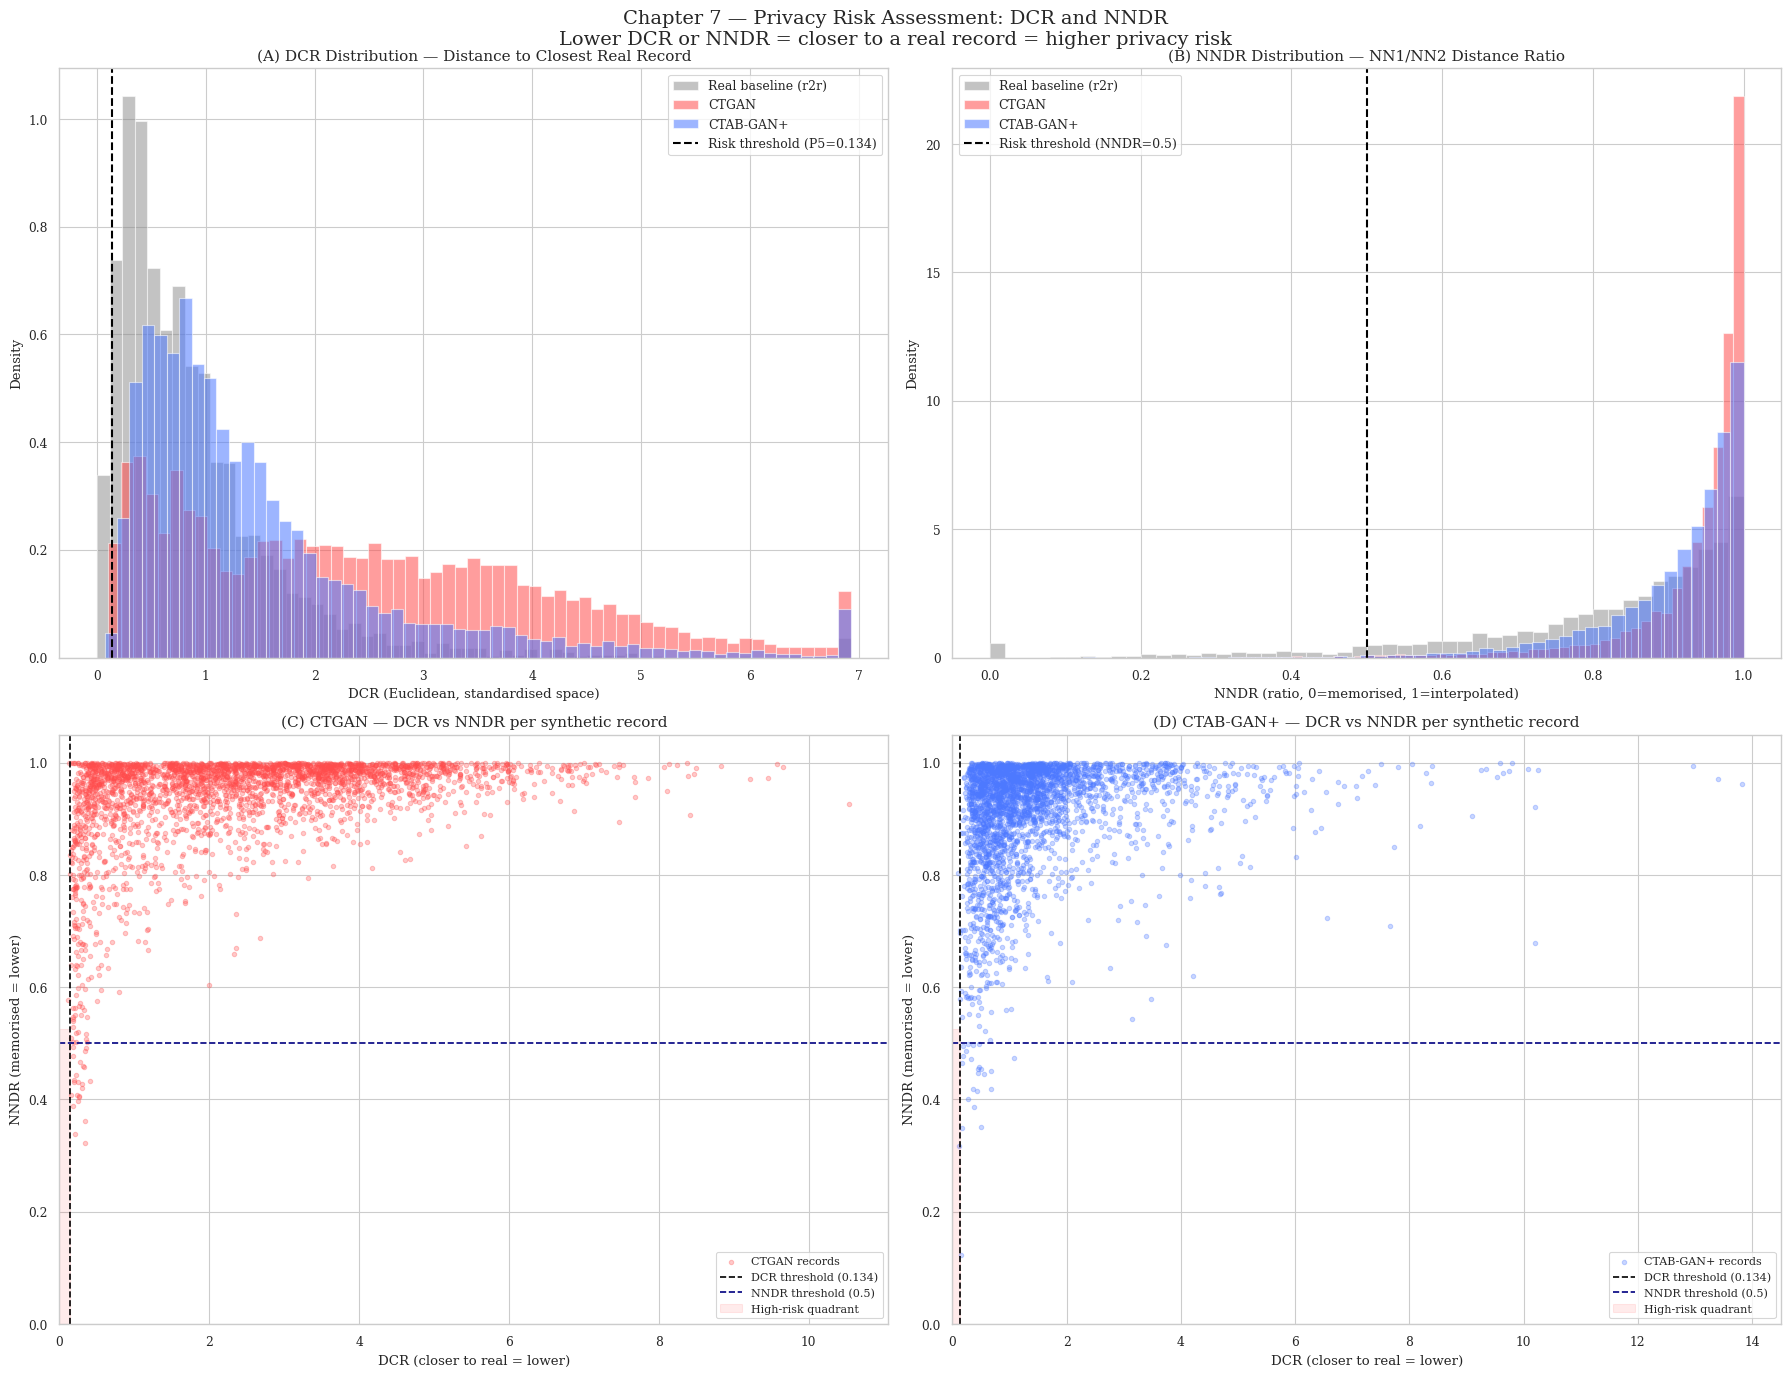

Figure saved: figures/privacy_dcr_nndr_analysis.png


In [84]:
# ==============================================================================
# 7.4 — PRIVACY RISK VISUALISATION
# ==============================================================================
#
# Three plots:
#   (A) DCR distributions — histogram + KDE for real baseline vs CTGAN vs CTAB-GAN+
#   (B) NNDR distributions — same structure
#   (C) DCR vs NNDR scatter — each point is one synthetic record;
#       records in the bottom-left quadrant (low DCR AND low NNDR) are
#       the highest-risk candidates (close to exactly one real record).
# ==============================================================================

print("=" * 70)
print("7.4 — PRIVACY RISK VISUALISATION")
print("=" * 70)

fig = plt.figure(figsize=(18, 14))
fig.suptitle(
    "Chapter 7 — Privacy Risk Assessment: DCR and NNDR\n"
    "Lower DCR or NNDR = closer to a real record = higher privacy risk",
    fontsize=14
)

# ── Plot A: DCR distributions ──────────────────────────────────────────────────
ax1 = fig.add_subplot(2, 2, 1)

# Clip for visual clarity (remove extreme tail)
dcr_p99 = np.percentile(np.concatenate([dcr_ctgan, dcr_ctab, dcr_real_baseline]), 99)

ax1.hist(np.clip(dcr_real_baseline, 0, dcr_p99), bins=60, density=True,
         color="#888888", alpha=0.5, label="Real baseline (r2r)")
ax1.hist(np.clip(dcr_ctgan, 0, dcr_p99), bins=60, density=True,
         color="#FF4D4D", alpha=0.55, label="CTGAN")
ax1.hist(np.clip(dcr_ctab, 0, dcr_p99), bins=60, density=True,
         color="#4D79FF", alpha=0.55, label="CTAB-GAN+")

ax1.axvline(dcr_risk_threshold, color="black", linestyle="--", linewidth=1.5,
            label=f"Risk threshold (P5={dcr_risk_threshold:.3f})")
ax1.set_title("(A) DCR Distribution — Distance to Closest Real Record", fontsize=11)
ax1.set_xlabel("DCR (Euclidean, standardised space)")
ax1.set_ylabel("Density")
ax1.legend(fontsize=9)

# ── Plot B: NNDR distributions ─────────────────────────────────────────────────
ax2 = fig.add_subplot(2, 2, 2)

ax2.hist(np.clip(nndr_real_baseline, 0, 1), bins=50, density=True,
         color="#888888", alpha=0.5, label="Real baseline (r2r)")
ax2.hist(np.clip(nndr_ctgan, 0, 1), bins=50, density=True,
         color="#FF4D4D", alpha=0.55, label="CTGAN")
ax2.hist(np.clip(nndr_ctab, 0, 1), bins=50, density=True,
         color="#4D79FF", alpha=0.55, label="CTAB-GAN+")

ax2.axvline(NNDR_RISK_THRESHOLD, color="black", linestyle="--", linewidth=1.5,
            label=f"Risk threshold (NNDR={NNDR_RISK_THRESHOLD})")
ax2.set_title("(B) NNDR Distribution — NN1/NN2 Distance Ratio", fontsize=11)
ax2.set_xlabel("NNDR (ratio, 0=memorised, 1=interpolated)")
ax2.set_ylabel("Density")
ax2.legend(fontsize=9)

# ── Plot C: DCR vs NNDR scatter — CTGAN ───────────────────────────────────────
ax3 = fig.add_subplot(2, 2, 3)

# Sample for visual clarity if dataset is large
n_sample = min(3000, len(dcr_ctgan))
idx_s = np.random.choice(len(dcr_ctgan), n_sample, replace=False)

ax3.scatter(dcr_ctgan[idx_s], nndr_ctgan[idx_s],
            color="#FF4D4D", alpha=0.3, s=10, label="CTGAN records")
ax3.axvline(dcr_risk_threshold, color="black", linestyle="--", linewidth=1.2,
            label=f"DCR threshold ({dcr_risk_threshold:.3f})")
ax3.axhline(NNDR_RISK_THRESHOLD, color="navy",  linestyle="--", linewidth=1.2,
            label=f"NNDR threshold ({NNDR_RISK_THRESHOLD})")

# Shade the high-risk quadrant (low DCR AND low NNDR)
ax3.axvspan(0, dcr_risk_threshold, ymin=0,
            ymax=NNDR_RISK_THRESHOLD, alpha=0.08, color="red",
            label="High-risk quadrant")

ax3.set_title("(C) CTGAN — DCR vs NNDR per synthetic record", fontsize=11)
ax3.set_xlabel("DCR (closer to real = lower)")
ax3.set_ylabel("NNDR (memorised = lower)")
ax3.set_xlim(left=0)
ax3.set_ylim(0, 1.05)
ax3.legend(fontsize=8)

# ── Plot D: DCR vs NNDR scatter — CTAB-GAN+ ───────────────────────────────────
ax4 = fig.add_subplot(2, 2, 4)

n_sample_ct = min(3000, len(dcr_ctab))
idx_ct = np.random.choice(len(dcr_ctab), n_sample_ct, replace=False)

ax4.scatter(dcr_ctab[idx_ct], nndr_ctab[idx_ct],
            color="#4D79FF", alpha=0.3, s=10, label="CTAB-GAN+ records")
ax4.axvline(dcr_risk_threshold, color="black", linestyle="--", linewidth=1.2,
            label=f"DCR threshold ({dcr_risk_threshold:.3f})")
ax4.axhline(NNDR_RISK_THRESHOLD, color="navy",  linestyle="--", linewidth=1.2,
            label=f"NNDR threshold ({NNDR_RISK_THRESHOLD})")
ax4.axvspan(0, dcr_risk_threshold, ymin=0,
            ymax=NNDR_RISK_THRESHOLD, alpha=0.08, color="red",
            label="High-risk quadrant")

ax4.set_title("(D) CTAB-GAN+ — DCR vs NNDR per synthetic record", fontsize=11)
ax4.set_xlabel("DCR (closer to real = lower)")
ax4.set_ylabel("NNDR (memorised = lower)")
ax4.set_xlim(left=0)
ax4.set_ylim(0, 1.05)
ax4.legend(fontsize=8)

plt.tight_layout()
plt.savefig("figures/privacy_dcr_nndr_analysis.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figure saved: figures/privacy_dcr_nndr_analysis.png")

In [85]:
# ==============================================================================
# 7.5 — CONSOLIDATED PRIVACY PROFILE
# ==============================================================================
#
# This cell produces the consolidated memorisation summary table,
# combining DCR and NNDR metrics into a single privacy risk profile.
#
# It also contextualises the results within the broader privacy-utility
# trade-off documented in Hollig et al. (2025):
#   - High utility (low augmentation noise) tends to correlate with
#     higher memorisation risk (lower DCR).
#   - The privacy-utility trade-off is quantified by comparing the
#     privacy scores here with the utility scores from Chapter 5.
# ==============================================================================

print("=" * 70)
print("7.5 — CONSOLIDATED PRIVACY PROFILE")
print("=" * 70)

# ── Privacy summary table ──────────────────────────────────────────────────────
privacy_summary = pd.DataFrame({
    "Privacy Metric": [
        "DCR — Mean",
        "DCR — Median",
        "DCR — 5th percentile",
        "DCR — Min (closest copy)",
        "DCR — % records below risk threshold",
        "DCR safety (median >= real baseline)",
        "NNDR — Mean",
        "NNDR — Median",
        "NNDR — % records < 0.5 (HIGH RISK)",
        "Real baseline DCR — Median",
        "Real baseline NNDR — Median",
    ],
    "CTGAN": [
        f"{dcr_ctgan.mean():.4f}",
        f"{np.median(dcr_ctgan):.4f}",
        f"{np.percentile(dcr_ctgan, 5):.4f}",
        f"{dcr_ctgan.min():.4f}",
        f"{risk_ctgan:.2%}",
        "SAFE" if ctgan_safe else "RISK",
        f"{nndr_ctgan.mean():.4f}",
        f"{np.median(nndr_ctgan):.4f}",
        f"{nndr_risk_ctgan:.2%}",
        f"{np.median(dcr_real_baseline):.4f}",
        f"{np.median(nndr_real_baseline):.4f}",
    ],
    "CTAB-GAN+": [
        f"{dcr_ctab.mean():.4f}",
        f"{np.median(dcr_ctab):.4f}",
        f"{np.percentile(dcr_ctab, 5):.4f}",
        f"{dcr_ctab.min():.4f}",
        f"{risk_ctab:.2%}",
        "SAFE" if ctab_safe else "RISK",
        f"{nndr_ctab.mean():.4f}",
        f"{np.median(nndr_ctab):.4f}",
        f"{nndr_risk_ctab:.2%}",
        f"{np.median(dcr_real_baseline):.4f}",
        f"{np.median(nndr_real_baseline):.4f}",
    ],
    "Interpretation": [
        "Higher = further from real records = better privacy",
        "Higher = further from real records = better privacy",
        "Higher = worst-case records still reasonably distant",
        "Minimum distance — the single closest synthetic-to-real pair",
        "% of synthetic records unusually close to one real record",
        "Key safety criterion: synthetic not closer than real-to-real",
        "Closer to 1 = more interpolation = better privacy",
        "Closer to 1 = more interpolation = better privacy",
        "Lower % = fewer records that closely shadow one real person",
        "Reference: typical distance between two real records",
        "Reference: typical NNDR between two real records",
    ],
})

print("\n", privacy_summary.to_string(index=False))
privacy_summary.to_csv("data/privacy_dcr_nndr_summary.csv", index=False)
print("\nSaved: privacy_dcr_nndr_summary.csv")

# ── Privacy-utility trade-off context ──────────────────────────────────────────
print("\n" + "=" * 70)
print("PRIVACY-UTILITY TRADE-OFF SUMMARY (addresses RQ3)")
print("=" * 70)

# Utility scores from Chapter 5 (hardcoded from results — update if re-run)
utility_scores = {
    "CTGAN":    {"AUC": 0.7594, "Macro_F1": 0.6910, "Recall": 0.4340},
    "CTAB-GAN+":{"AUC": 0.7249, "Macro_F1": 0.6740, "Recall": 0.4150},
}

privacy_scores = {
    "CTGAN":    {"DCR_median": np.median(dcr_ctgan), "NNDR_median": np.median(nndr_ctgan),
                 "DCR_risk_%": risk_ctgan,  "NNDR_risk_%": nndr_risk_ctgan},
    "CTAB-GAN+":{"DCR_median": np.median(dcr_ctab),  "NNDR_median": np.median(nndr_ctab),
                 "DCR_risk_%": risk_ctab,   "NNDR_risk_%": nndr_risk_ctab},
}

print(f"\n{'Model':<15} {'AUC':>8} {'Macro F1':>10} {'DCR median':>12} {'NNDR median':>13} {'DCR risk':>10} {'NNDR risk':>11}")
print("-" * 82)
for model in ["CTGAN", "CTAB-GAN+"]:
    u = utility_scores[model]
    p = privacy_scores[model]
    print(f"{model:<15} {u['AUC']:>8.4f} {u['Macro_F1']:>10.4f} "
          f"{p['DCR_median']:>12.4f} {p['NNDR_median']:>13.4f} "
          f"{p['DCR_risk_%']:>10.2%} {p['NNDR_risk_%']:>11.2%}")

print("\nNOTE: Update utility scores from results_rf_ctgan and results_rf_ctab "
      "if models were re-run.")
print("\nInterpretation:")
print("  - A model with HIGH utility (AUC) and HIGH DCR risk suggests it")
print("    achieves utility by memorising real records — Hollig et al. (2025).")
print("  - A model with LOWER utility but also LOWER DCR risk is the safer")
print("    generative option for a regulated financial institution.")
print("  - This trade-off directly answers RQ3 of this dissertation.")

7.5 — CONSOLIDATED PRIVACY PROFILE

                       Privacy Metric  CTGAN CTAB-GAN+                                               Interpretation
                          DCR — Mean 2.4268    1.5173          Higher = further from real records = better privacy
                        DCR — Median 2.1859    1.1090          Higher = further from real records = better privacy
                DCR — 5th percentile 0.2866    0.3331         Higher = worst-case records still reasonably distant
            DCR — Min (closest copy) 0.1035    0.0678 Minimum distance — the single closest synthetic-to-real pair
DCR — % records below risk threshold  0.17%     0.12%    % of synthetic records unusually close to one real record
DCR safety (median >= real baseline) SAFE    SAFE Key safety criterion: synthetic not closer than real-to-real
                         NNDR — Mean 0.9376    0.9091            Closer to 1 = more interpolation = better privacy
                       NNDR — Median 0.9695    